In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn as skl

from google.colab import drive
drive.mount('/content/drive')

# Baca file dari Drive
df = pd.read_csv('/content/drive/MyDrive/application_train.csv')

df

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


,SK_ID_CURR,TARGET,NAME_CONTRACT_TYPE,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,AMT_CREDIT,AMT_ANNUITY,...,FLAG_DOCUMENT_18,FLAG_DOCUMENT_19,FLAG_DOCUMENT_20,FLAG_DOCUMENT_21,AMT_REQ_CREDIT_BUREAU_HOUR,AMT_REQ_CREDIT_BUREAU_DAY,AMT_REQ_CREDIT_BUREAU_WEEK,AMT_REQ_CREDIT_BUREAU_MON,AMT_REQ_CREDIT_BUREAU_QRT,AMT_REQ_CREDIT_BUREAU_YEAR
0,100002,1,Cash loans,M,N,Y,0,202500.0,406597.5,24700.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,1.0
1,100003,0,Cash loans,F,N,N,0,270000.0,1293502.5,35698.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
2,100004,0,Revolving loans,M,Y,Y,0,67500.0,135000.0,6750.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
3,100006,0,Cash loans,F,N,Y,0,135000.0,312682.5,29686.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
4,100007,0,Cash loans,M,N,Y,0,121500.0,513000.0,21865.5,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
307506,456251,0,Cash loans,M,N,N,0,157500.0,254700.0,27558.0,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307507,456252,0,Cash loans,F,N,Y,0,72000.0,269550.0,12001.5,...,0,0,0,0,NaN,NaN,NaN,NaN,NaN,NaN
307508,456253,0,Cash loans,F,N,Y,0,153000.0,677664.0,29979.0,...,0,0,0,0,1.0,0.0,0.0,1.0,0.0,1.0
307509,456254,1,Cash loans,F,N,Y,0,171000.0,370107.0,20205.0,...,0,0,0,0,0.0,0.0,0.0,0.0,0.0,0.0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Columns: 122 entries, SK_ID_CURR to AMT_REQ_CREDIT_BUREAU_YEAR
dtypes: float64(65), int64(41), object(16)
memory usage: 286.2+ MB


In [ ]:
def nulls_check(df):
  return (df.isnull().sum()
    .to_frame('null_count')
    .assign(null_ratio=lambda x: x['null_count'] / len(df))
    .query("null_count > 0")
    .sort_values('null_ratio', ascending=False)
  )

nulls_check(df).head(60)

,null_count,null_ratio
COMMONAREA_MEDI,214865,0.698723
COMMONAREA_MODE,214865,0.698723
COMMONAREA_AVG,214865,0.698723
NONLIVINGAPARTMENTS_MODE,213514,0.694330
NONLIVINGAPARTMENTS_MEDI,213514,0.694330
NONLIVINGAPARTMENTS_AVG,213514,0.694330
FONDKAPREMONT_MODE,210295,0.683862
LIVINGAPARTMENTS_AVG,210199,0.683550
LIVINGAPARTMENTS_MEDI,210199,0.683550
LIVINGAPARTMENTS_MODE,210199,0.683550


In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns
cat_cols = df.select_dtypes(include=['object']).columns
bool_cols = df.select_dtypes(include=['bool']).columns

print(f"Jumlah kolom numerik: {len(num_cols)}")
print(f"Jumlah kolom kategorikal: {len(cat_cols)}")
print(f"Jumlah kolom boolean: {len(bool_cols)}")
print()
print(f"daftar kolom numerik: {num_cols}")
print()
print(f"daftar kolom kategorikal: {cat_cols}")
print()
print(f"daftar kolom boolean: {bool_cols}")

Jumlah kolom numerik: 106
Jumlah kolom kategorikal: 16
Jumlah kolom boolean: 0

daftar kolom numerik: Index(['SK_ID_CURR', 'TARGET', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL',
       'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE',
       'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED',
       ...
       'FLAG_DOCUMENT_18', 'FLAG_DOCUMENT_19', 'FLAG_DOCUMENT_20',
       'FLAG_DOCUMENT_21', 'AMT_REQ_CREDIT_BUREAU_HOUR',
       'AMT_REQ_CREDIT_BUREAU_DAY', 'AMT_REQ_CREDIT_BUREAU_WEEK',
       'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_QRT',
       'AMT_REQ_CREDIT_BUREAU_YEAR'],
      dtype='object', length=106)

daftar kolom kategorikal: Index(['NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY',
       'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE',
       'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE',
       'WEEKDAY_APPR_PROCESS_START', 'ORGANIZATION_TYPE', 'FONDKAPREMONT_MODE',
       'HOUSETYPE_MODE', 'WALLSMATERIAL_MODE',

In [ ]:
high_missing = nulls_check(df)
drop_missing = [col for col in high_missing[high_missing['null_ratio'] > 0.5].index]

print(f'Kolom dengan missing >50%: {len(drop_missing)}')
print(f'Total di-drop: {len(drop_missing)} kolom')
print('\nKolom yang di-drop:')
for c in drop_missing:
    print(f'  {c}  ({high_missing.loc[c, "null_ratio"]*100:.1f}%)')

Kolom dengan missing >50%: 41
Total di-drop: 41 kolom

Kolom yang di-drop:
  COMMONAREA_MEDI  (69.9%)
  COMMONAREA_MODE  (69.9%)
  COMMONAREA_AVG  (69.9%)
  NONLIVINGAPARTMENTS_MODE  (69.4%)
  NONLIVINGAPARTMENTS_MEDI  (69.4%)
  NONLIVINGAPARTMENTS_AVG  (69.4%)
  FONDKAPREMONT_MODE  (68.4%)
  LIVINGAPARTMENTS_AVG  (68.4%)
  LIVINGAPARTMENTS_MEDI  (68.4%)
  LIVINGAPARTMENTS_MODE  (68.4%)
  FLOORSMIN_MEDI  (67.8%)
  FLOORSMIN_MODE  (67.8%)
  FLOORSMIN_AVG  (67.8%)
  YEARS_BUILD_MODE  (66.5%)
  YEARS_BUILD_MEDI  (66.5%)
  YEARS_BUILD_AVG  (66.5%)
  OWN_CAR_AGE  (66.0%)
  LANDAREA_AVG  (59.4%)
  LANDAREA_MEDI  (59.4%)
  LANDAREA_MODE  (59.4%)
  BASEMENTAREA_MODE  (58.5%)
  BASEMENTAREA_MEDI  (58.5%)
  BASEMENTAREA_AVG  (58.5%)
  EXT_SOURCE_1  (56.4%)
  NONLIVINGAREA_MEDI  (55.2%)
  NONLIVINGAREA_AVG  (55.2%)
  NONLIVINGAREA_MODE  (55.2%)
  ELEVATORS_MEDI  (53.3%)
  ELEVATORS_MODE  (53.3%)
  ELEVATORS_AVG  (53.3%)
  WALLSMATERIAL_MODE  (50.8%)
  APARTMENTS_AVG  (50.7%)
  APARTMENTS_MEDI  (5

In [ ]:
# Drop kolom dengan missing value > 50%
df.drop(columns=drop_missing, inplace=True)

# Drop triplet redundan _AVG/_MODE/_MEDI
redundant_cols = [col for col in df.columns if '_AVG' in col or '_MODE' in col or '_MEDI' in col]
df.drop(columns=redundant_cols, inplace=True)

# Drop seluruh FLAG_DOCUMENT
drop_flag_doc = ['FLAG_DOCUMENT_2','FLAG_DOCUMENT_3', 'FLAG_DOCUMENT_4', 'FLAG_DOCUMENT_5',
               'FLAG_DOCUMENT_6', 'FLAG_DOCUMENT_7','FLAG_DOCUMENT_8','FLAG_DOCUMENT_9',
               'FLAG_DOCUMENT_10','FLAG_DOCUMENT_11','FLAG_DOCUMENT_12','FLAG_DOCUMENT_13',
               'FLAG_DOCUMENT_14','FLAG_DOCUMENT_15','FLAG_DOCUMENT_16','FLAG_DOCUMENT_17',
               'FLAG_DOCUMENT_18','FLAG_DOCUMENT_19','FLAG_DOCUMENT_20','FLAG_DOCUMENT_21']
df.drop(columns=drop_flag_doc, inplace=True)

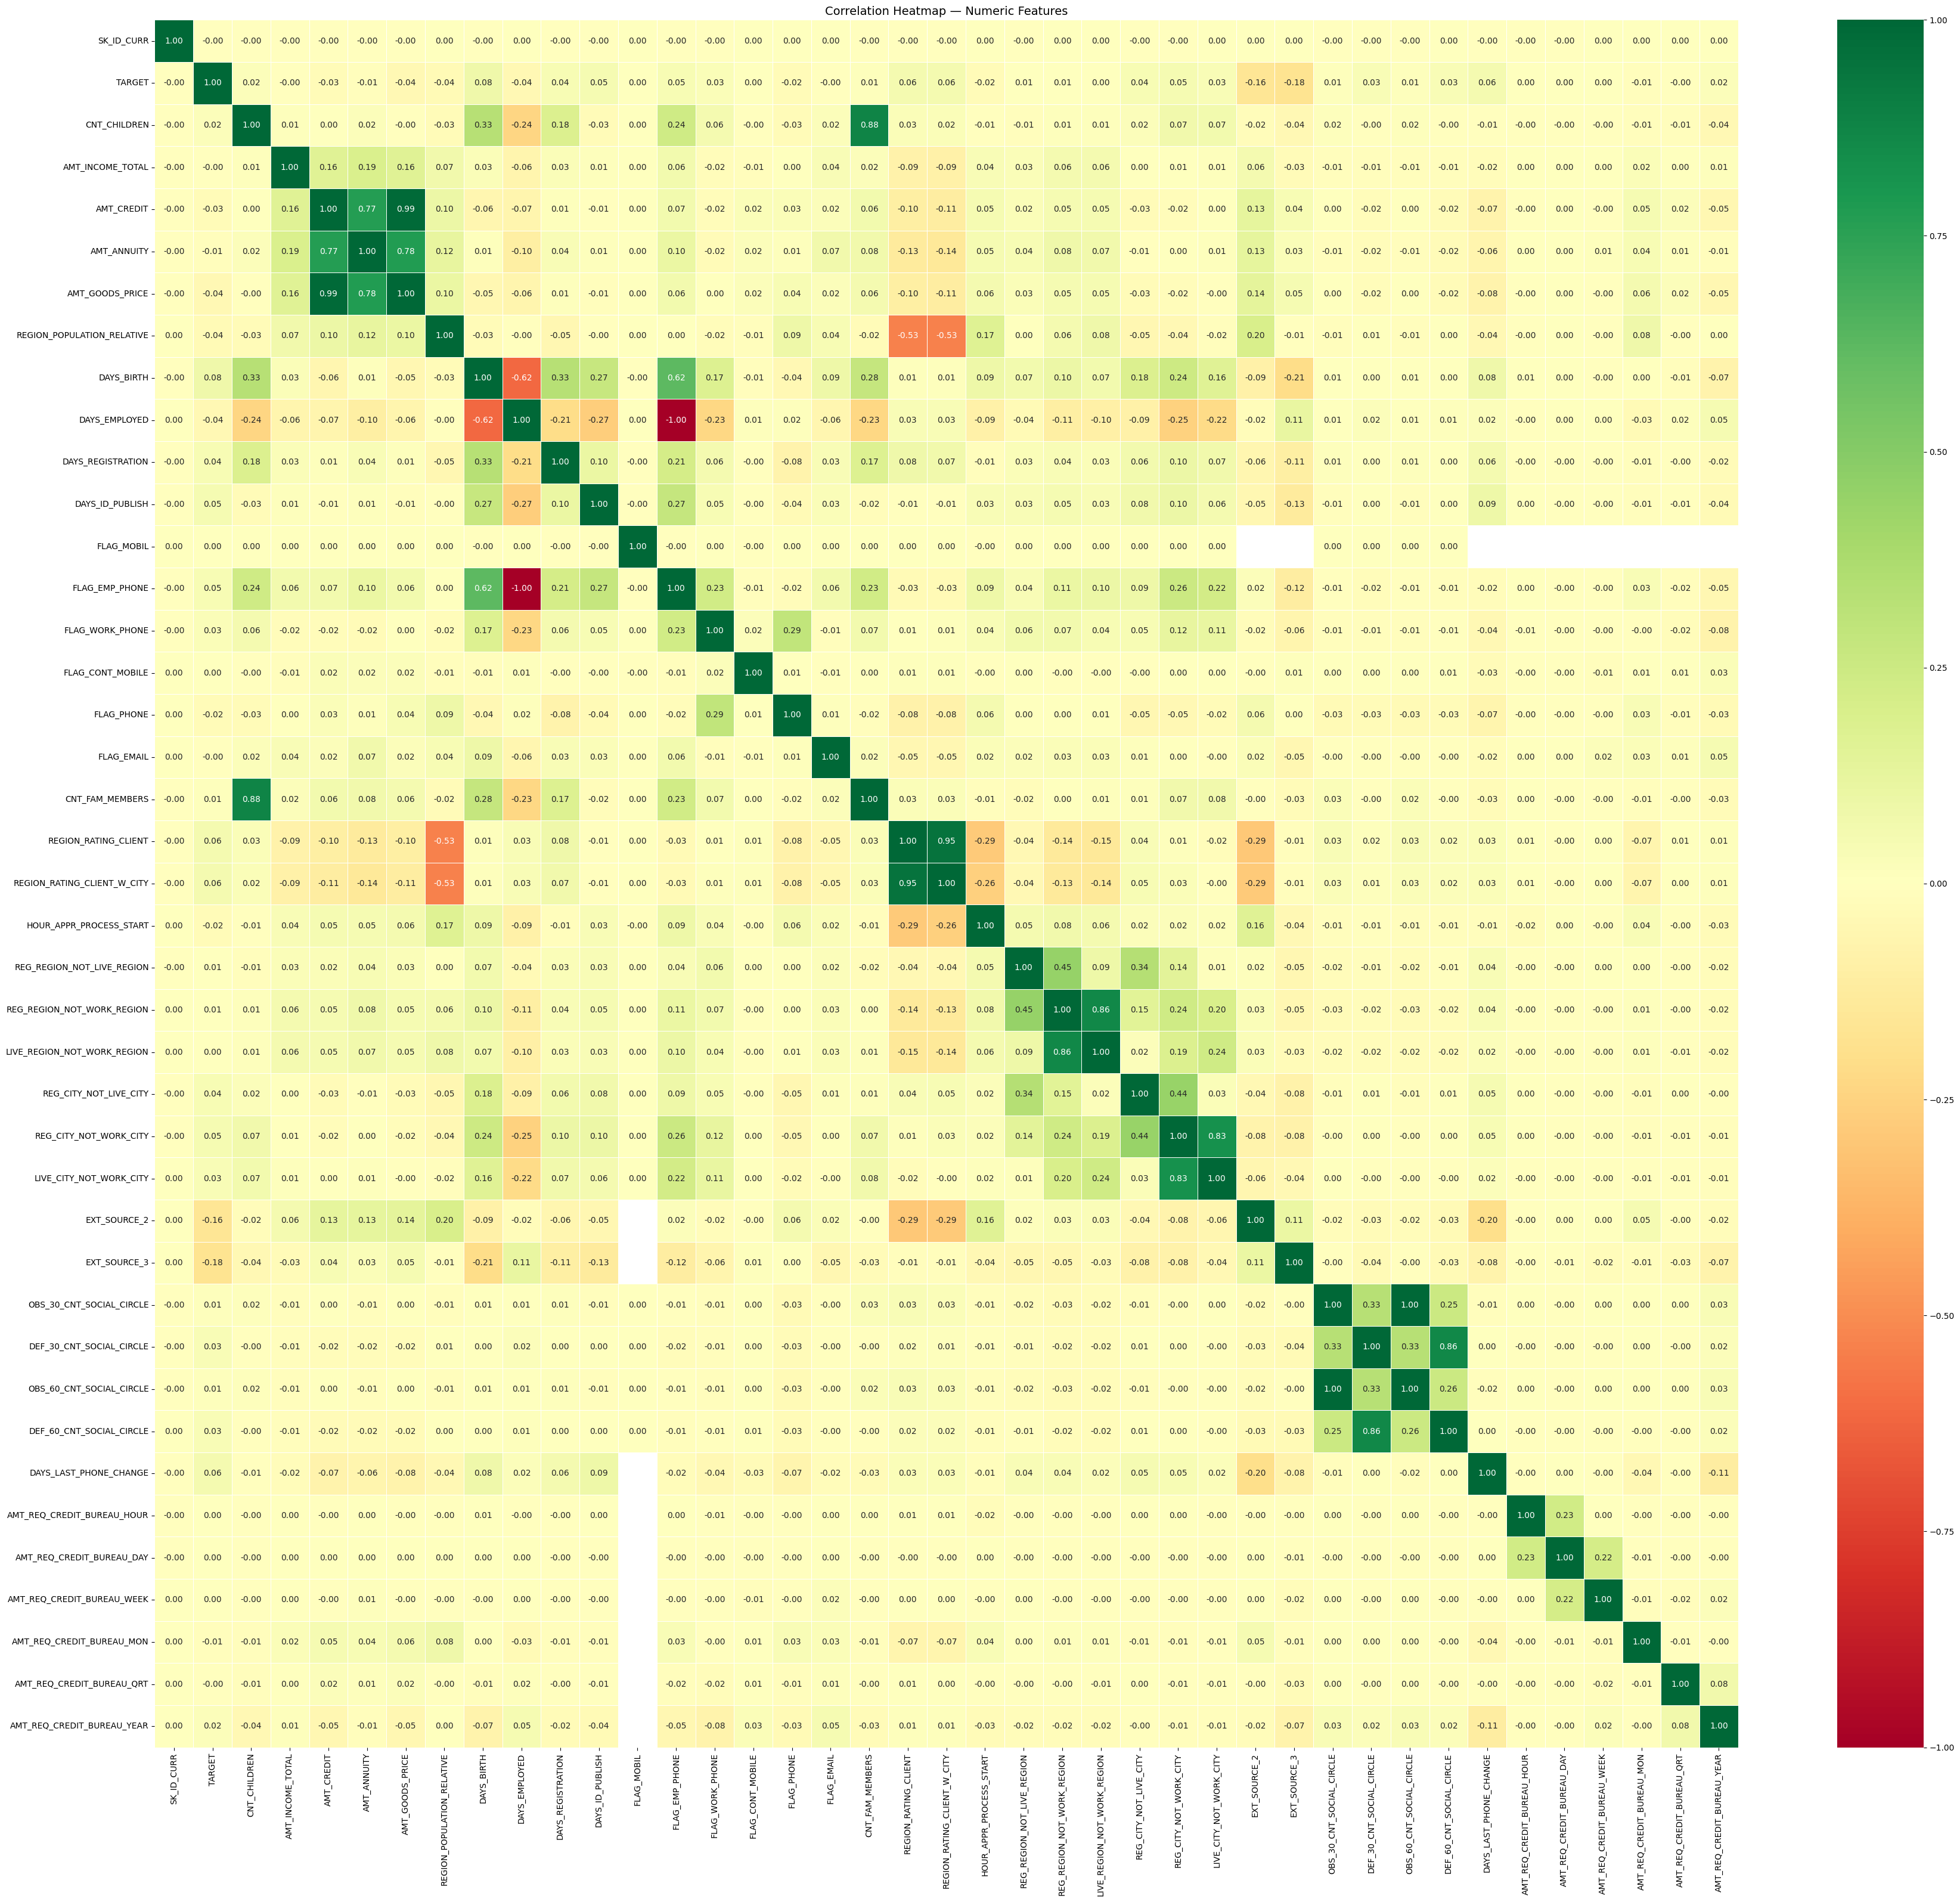

In [ ]:
num_cols = df.select_dtypes(include=['int64', 'float64']).columns

corr = df[num_cols].corr()

plt.figure(figsize=(36, 32))
sns.heatmap(
    corr,
    annot=True, fmt='.2f',
    cmap='RdYlGn',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.5
)
plt.title('Correlation Heatmap — Numeric Features', fontsize=14)
plt.tight_layout()
plt.show()

In [ ]:
# Drop low corr dengan TARGET
drop_lowcorr = ['SK_ID_CURR','FLAG_CONT_MOBILE','FLAG_MOBIL','FLAG_EMAIL',
                'AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_WEEK',
                'AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_QRT',
                'LIVE_REGION_NOT_WORK_REGION','REG_REGION_NOT_LIVE_REGION','REG_REGION_NOT_WORK_REGION']
df.drop(columns=drop_lowcorr, inplace=True)

# Drop multikolinearitas tinggi
drop_highcorr = ['DAYS_EMPLOYED','OBS_60_CNT_SOCIAL_CIRCLE','AMT_CREDIT',
                 'REGION_RATING_CLIENT','CNT_FAM_MEMBERS','DEF_60_CNT_SOCIAL_CIRCLE']
df.drop(columns=drop_highcorr, inplace=True)

print(f'Shape final: {df.shape}')

Shape final: (307511, 36)


In [ ]:
from sklearn.feature_selection import VarianceThreshold

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

num_x = df[num_cols]

# menghapus kolom yang kurang informatif (memiliki nilai yang sama semua dengan threshold 0.0)
vt = VarianceThreshold(threshold=0.0)
num_x_vt = vt.fit_transform(num_x)

kept_num_x = num_x.columns[vt.get_support()]
drop_num_x = num_x.columns[~vt.get_support()]

print(f"Jumlah kolom numerik yang di-drop: {len(drop_num_x)}")
print(f"Jumlah kolom numerik yang tidak di-drop: {len(kept_num_x)}")

if len(drop_num_x) > 0:
    df.drop(columns=drop_num_x.tolist(), inplace=True)
    print(f"✓ {len(drop_num_x)} kolom zero-variance di-drop dari df")

Jumlah kolom numerik yang di-drop: 0
Jumlah kolom numerik yang tidak di-drop: 24


                count  percent
Low Risk (0)   282686    91.93
High Risk (1)   24825     8.07

Rasio Low:High = 11.4:1


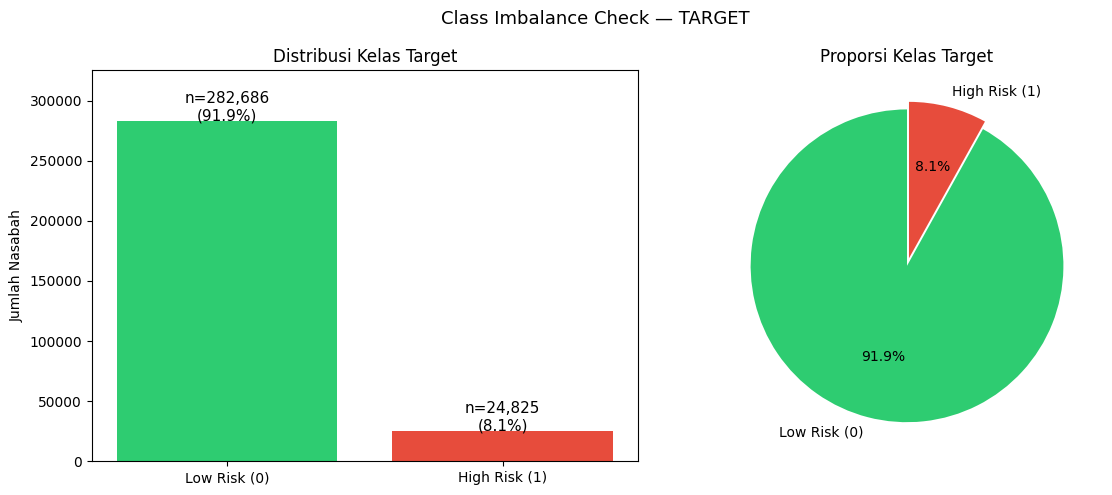

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# ============================================================
# 1. Hitung distribusi kelas
# ============================================================
class_counts = df['TARGET'].value_counts()
class_pct    = df['TARGET'].value_counts(normalize=True) * 100

summary = pd.DataFrame({
    'count'  : class_counts,
    'percent': class_pct.round(2)
})
summary.index = ['Low Risk (0)', 'High Risk (1)']
print(summary)

# Rasio imbalance
ratio = class_counts[0] / class_counts[1]
print(f"\nRasio Low:High = {ratio:.1f}:1")

# ============================================================
# 2. Visualisasi
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(
    ['Low Risk (0)', 'High Risk (1)'],
    class_counts.values,
    color=colors
)
for i, (count, pct) in enumerate(zip(class_counts, class_pct)):
    axes[0].text(
        i, count + 500,
        f'n={count:,}\n({pct:.1f}%)',
        ha='center', fontsize=11
    )
axes[0].set_title('Distribusi Kelas Target')
axes[0].set_ylabel('Jumlah Nasabah')
axes[0].set_ylim(0, class_counts.max() * 1.15)

# Pie chart
axes[1].pie(
    class_counts.values,
    labels=['Low Risk (0)', 'High Risk (1)'],
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.05)
)
axes[1].set_title('Proporsi Kelas Target')

plt.suptitle('Class Imbalance Check — TARGET', fontsize=13)
plt.tight_layout()
plt.show()

In [ ]:
import missingno as msno
import matplotlib.pyplot as plt
import pandas as pd

# Hitung missing value
def missing_summary(df):
    missing = df.isnull().sum()
    missing_pct = (missing / len(df) * 100).round(2)

    summary = pd.DataFrame({
        'missing_count': missing,
        'missing_pct': missing_pct,
        'dtype': df.dtypes
    })

    summary = summary[summary['missing_count'] > 0]
    summary = summary.sort_values('missing_pct', ascending=False)

    return summary

missing_df = missing_summary(df)
print(missing_df)

                            missing_count  missing_pct    dtype
OCCUPATION_TYPE                     96391        31.35   object
EXT_SOURCE_3                        60965        19.83  float64
AMT_REQ_CREDIT_BUREAU_MON           41519        13.50  float64
AMT_REQ_CREDIT_BUREAU_YEAR          41519        13.50  float64
NAME_TYPE_SUITE                      1292         0.42   object
DEF_30_CNT_SOCIAL_CIRCLE             1021         0.33  float64
OBS_30_CNT_SOCIAL_CIRCLE             1021         0.33  float64
EXT_SOURCE_2                          660         0.21  float64
AMT_GOODS_PRICE                       278         0.09  float64
AMT_ANNUITY                            12         0.00  float64
DAYS_LAST_PHONE_CHANGE                  1         0.00  float64


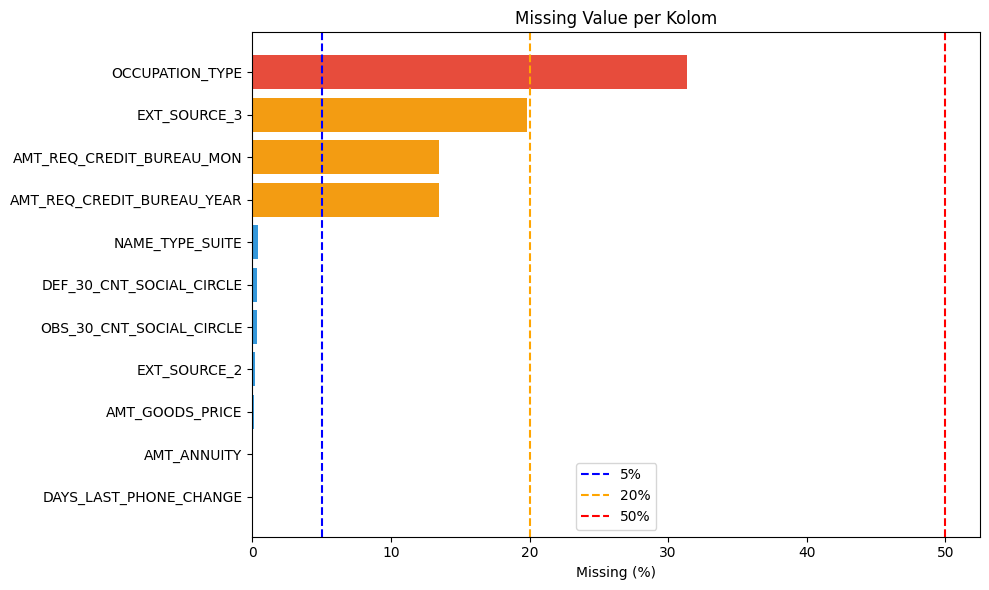

In [ ]:
plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if p > 20 else '#f39c12' if p > 5 else '#3498db'
          for p in missing_df['missing_pct']]

plt.barh(missing_df.index, missing_df['missing_pct'], color=colors)
plt.axvline(x=5,  color='blue',   linestyle='--', label='5%')
plt.axvline(x=20, color='orange', linestyle='--', label='20%')
plt.axvline(x=50, color='red',    linestyle='--', label='50%')
plt.xlabel('Missing (%)')
plt.title('Missing Value per Kolom')
plt.legend()
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<Figure size 1400x600 with 0 Axes>

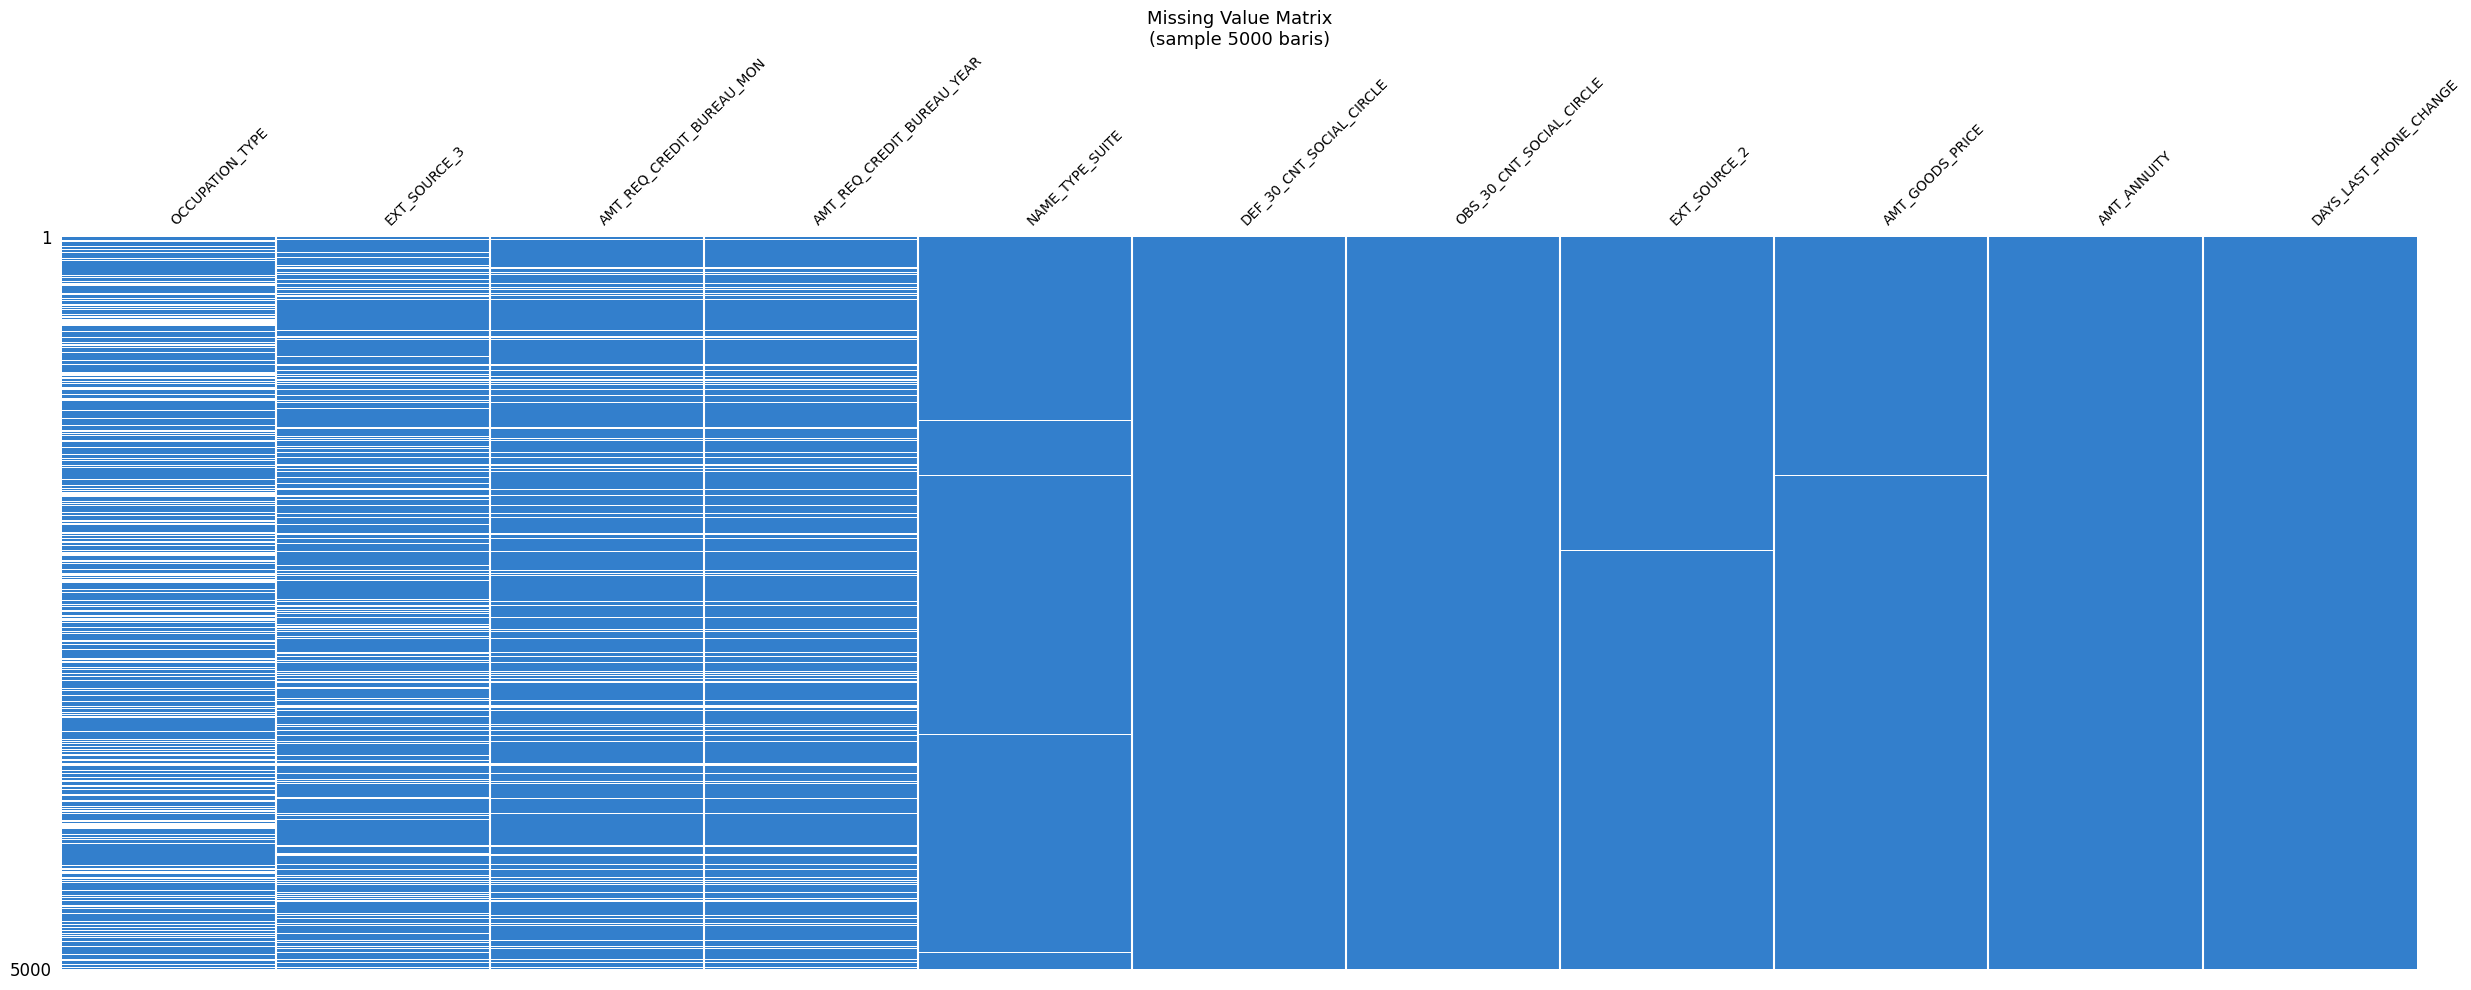

In [ ]:
# Hanya kolom yang punya missing value
cols_with_missing = missing_df.index.tolist()

plt.figure(figsize=(14, 6))
msno.matrix(
    df[cols_with_missing].sample(5000, random_state=42),
    sparkline=False,
    fontsize=10,
    color=(0.2, 0.5, 0.8)
)
plt.title('Missing Value Matrix\n(sample 5000 baris)', fontsize=13)
plt.tight_layout()
plt.show()

<Figure size 1000x800 with 0 Axes>

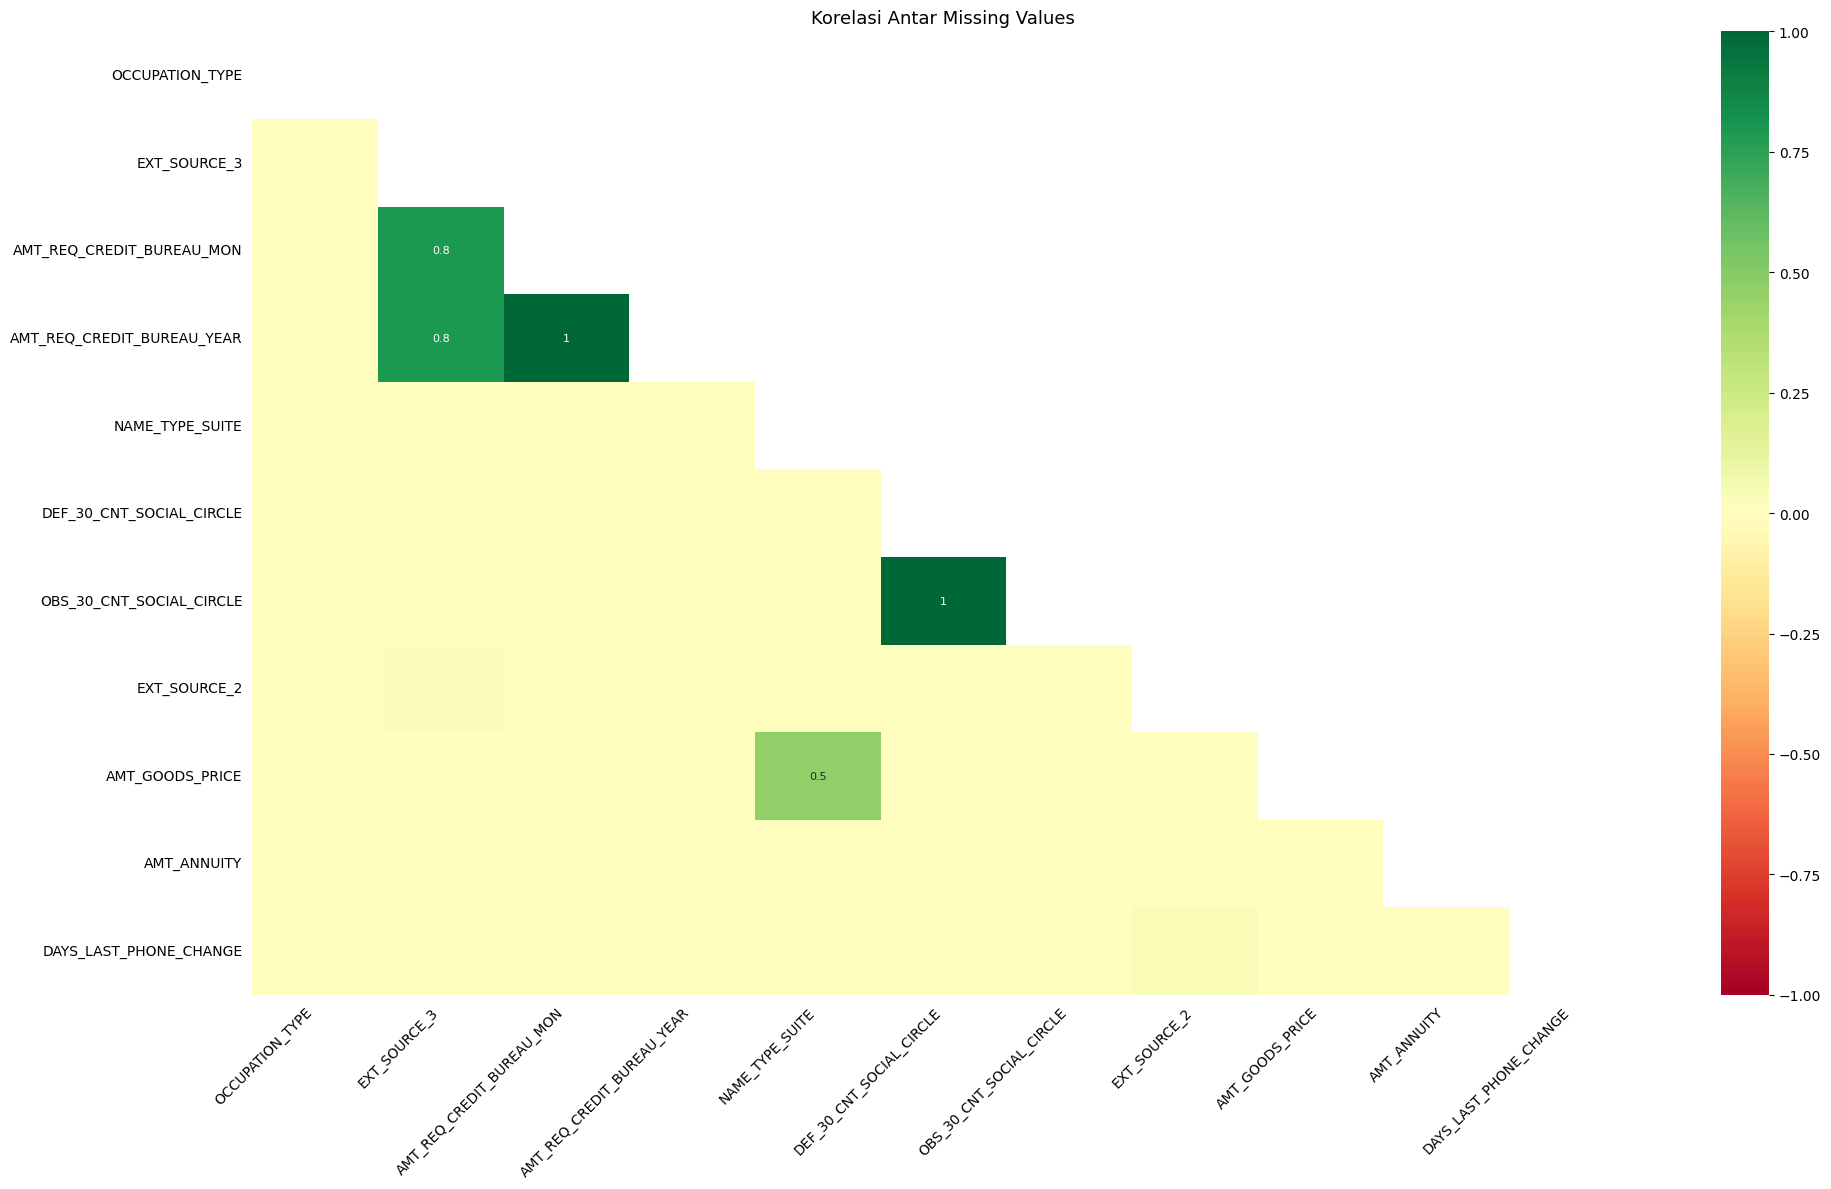

In [ ]:
plt.figure(figsize=(10, 8))
msno.heatmap(
    df[cols_with_missing],
    fontsize=10,
    cmap='RdYlGn'
)
plt.title('Korelasi Antar Missing Values', fontsize=13)
plt.tight_layout()
plt.show()

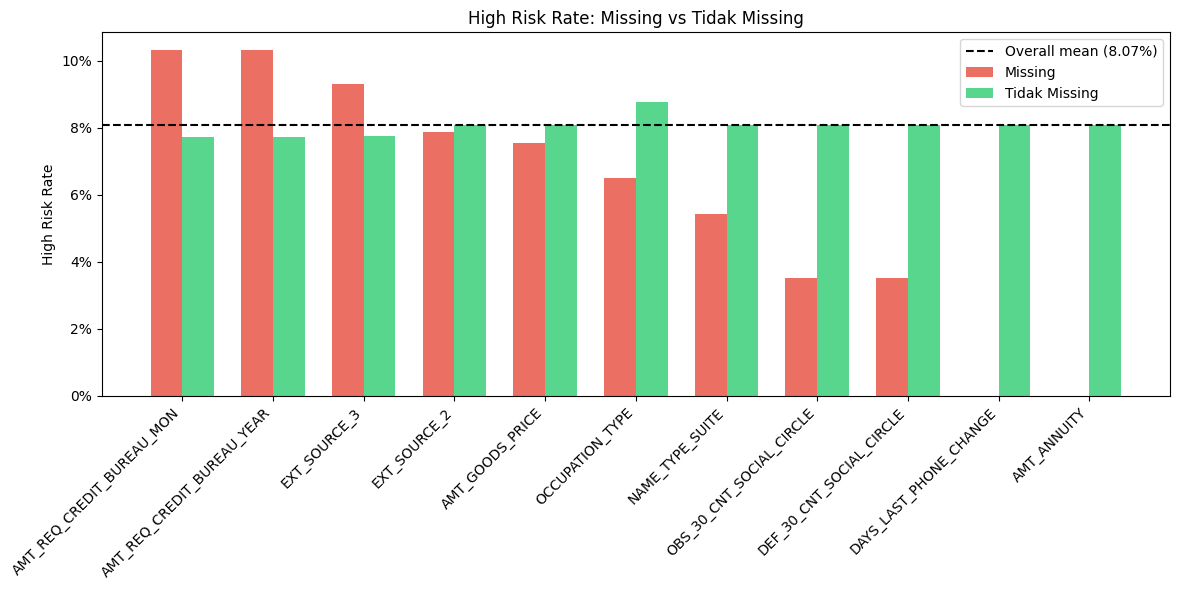

                       feature  risk_if_missing  risk_if_not_missing  \
2    AMT_REQ_CREDIT_BUREAU_MON         0.103374             0.077194   
3   AMT_REQ_CREDIT_BUREAU_YEAR         0.103374             0.077194   
1                 EXT_SOURCE_3         0.093119             0.077665   
7                 EXT_SOURCE_2         0.078788             0.080733   
8              AMT_GOODS_PRICE         0.075540             0.080734   
0              OCCUPATION_TYPE         0.065131             0.087851   
4              NAME_TYPE_SUITE         0.054180             0.080841   
6     OBS_30_CNT_SOCIAL_CIRCLE         0.035260             0.080880   
5     DEF_30_CNT_SOCIAL_CIRCLE         0.035260             0.080880   
10      DAYS_LAST_PHONE_CHANGE         0.000000             0.080729   
9                  AMT_ANNUITY         0.000000             0.080732   

     selisih  count_missing  
2   0.026180          41519  
3   0.026180          41519  
1   0.015454          60965  
7  -0.001945   

In [ ]:
def plot_missing_vs_target(df, cols_with_missing, target):
    results = []

    for col in cols_with_missing:
        is_missing = df[col].isnull()

        risk_missing     = df[is_missing][target].mean()
        risk_not_missing = df[~is_missing][target].mean()
        count_missing    = is_missing.sum()

        results.append({
            'feature'          : col,
            'risk_if_missing'  : risk_missing,
            'risk_if_not_missing': risk_not_missing,
            'selisih'          : risk_missing - risk_not_missing,
            'count_missing'    : count_missing
        })

    result_df = pd.DataFrame(results).sort_values('selisih', ascending=False)

    # Plot
    x      = range(len(result_df))
    width  = 0.35

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.bar([i - width/2 for i in x], result_df['risk_if_missing'],
           width, label='Missing', color='#e74c3c', alpha=0.8)
    ax.bar([i + width/2 for i in x], result_df['risk_if_not_missing'],
           width, label='Tidak Missing', color='#2ecc71', alpha=0.8)

    ax.axhline(y=df[target].mean(), color='black',
               linestyle='--', label=f'Overall mean ({df[target].mean():.2%})')
    ax.set_xticks(list(x))
    ax.set_xticklabels(result_df['feature'], rotation=45, ha='right')
    ax.set_ylabel('High Risk Rate')
    ax.set_title('High Risk Rate: Missing vs Tidak Missing')
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
    ax.legend()
    plt.tight_layout()
    plt.show()

    return result_df

missing_vs_risk = plot_missing_vs_target(df, cols_with_missing, 'TARGET')
print(missing_vs_risk)

In [ ]:
# ── 1. OCCUPATION_TYPE & NAME_TYPE_SUITE → kategori 'Unknown'
df['OCCUPATION_TYPE'] = df['OCCUPATION_TYPE'].fillna('Unknown')
df['NAME_TYPE_SUITE'] = df['NAME_TYPE_SUITE'].fillna('Unknown')

# ── 2. EXT_SOURCE_3 → median + flag missing
df['EXT_SOURCE_3_MISSING'] = df['EXT_SOURCE_3'].isnull().astype(int)
df['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].fillna(df['EXT_SOURCE_3'].median())

# ── 3. AMT_REQ_CREDIT_BUREAU → 0 + flag missing
df['IS_NO_BUREAU_ENQUIRY'] = df['AMT_REQ_CREDIT_BUREAU_MON'].isnull().astype(int)
df['AMT_REQ_CREDIT_BUREAU_MON']  = df['AMT_REQ_CREDIT_BUREAU_MON'].fillna(0)
df['AMT_REQ_CREDIT_BUREAU_YEAR'] = df['AMT_REQ_CREDIT_BUREAU_YEAR'].fillna(0)

# ── 4. DEF_30 & OBS_30 → 0
df['DEF_30_CNT_SOCIAL_CIRCLE'] = df['DEF_30_CNT_SOCIAL_CIRCLE'].fillna(0)
df['OBS_30_CNT_SOCIAL_CIRCLE'] = df['OBS_30_CNT_SOCIAL_CIRCLE'].fillna(0)

# ── 5. MCAR → median
TRAIN_MEDIANS = {}
for col in ['EXT_SOURCE_2', 'AMT_GOODS_PRICE', 'AMT_ANNUITY', 'DAYS_LAST_PHONE_CHANGE']:
    TRAIN_MEDIANS[col] = df[col].median()
    df[col] = df[col].fillna(TRAIN_MEDIANS[col])   # ← tambahkan baris ini

TRAIN_MEDIANS['EXT_SOURCE_3'] = df['EXT_SOURCE_3'].median()
print('Train medians:', TRAIN_MEDIANS)

# ── Verifikasi
print("Sisa missing value:")
missing_remaining = df.isnull().sum()[df.isnull().sum() > 0]
if len(missing_remaining) == 0:
    print("✅ Tidak ada missing value tersisa")
else:
    print(missing_remaining)

Train medians: {'EXT_SOURCE_2': 0.5659614260608526, 'AMT_GOODS_PRICE': 450000.0, 'AMT_ANNUITY': 24903.0, 'DAYS_LAST_PHONE_CHANGE': -757.0, 'EXT_SOURCE_3': 0.5352762504724826}
Sisa missing value:
✅ Tidak ada missing value tersisa


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 38 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   TARGET                       307511 non-null  int64  
 1   NAME_CONTRACT_TYPE           307511 non-null  object 
 2   CODE_GENDER                  307511 non-null  object 
 3   FLAG_OWN_CAR                 307511 non-null  object 
 4   FLAG_OWN_REALTY              307511 non-null  object 
 5   CNT_CHILDREN                 307511 non-null  int64  
 6   AMT_INCOME_TOTAL             307511 non-null  float64
 7   AMT_ANNUITY                  307511 non-null  float64
 8   AMT_GOODS_PRICE              307511 non-null  float64
 9   NAME_TYPE_SUITE              307511 non-null  object 
 10  NAME_INCOME_TYPE             307511 non-null  object 
 11  NAME_EDUCATION_TYPE          307511 non-null  object 
 12  NAME_FAMILY_STATUS           307511 non-null  object 
 13 

In [ ]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
TARGET,307511.0,0.080729,0.272419,0.000000e+00,0.000000,0.000000,0.000000,1.000000e+00
CNT_CHILDREN,307511.0,0.417052,0.722121,0.000000e+00,0.000000,0.000000,1.000000,1.900000e+01
AMT_INCOME_TOTAL,307511.0,168797.919297,237123.146279,2.565000e+04,112500.000000,147150.000000,202500.000000,1.170000e+08
AMT_ANNUITY,307511.0,27108.487841,14493.461065,1.615500e+03,16524.000000,24903.000000,34596.000000,2.580255e+05
AMT_GOODS_PRICE,307511.0,538316.294367,369288.982246,4.050000e+04,238500.000000,450000.000000,679500.000000,4.050000e+06
REGION_POPULATION_RELATIVE,307511.0,0.020868,0.013831,2.900000e-04,0.010006,0.018850,0.028663,7.250800e-02
DAYS_BIRTH,307511.0,-16036.995067,4363.988632,-2.522900e+04,-19682.000000,-15750.000000,-12413.000000,-7.489000e+03
DAYS_REGISTRATION,307511.0,-4986.120328,3522.886321,-2.467200e+04,-7479.500000,-4504.000000,-2010.000000,0.000000e+00
DAYS_ID_PUBLISH,307511.0,-2994.202373,1509.450419,-7.197000e+03,-4299.000000,-3254.000000,-1720.000000,0.000000e+00
FLAG_EMP_PHONE,307511.0,0.819889,0.384280,0.000000e+00,1.000000,1.000000,1.000000,1.000000e+00


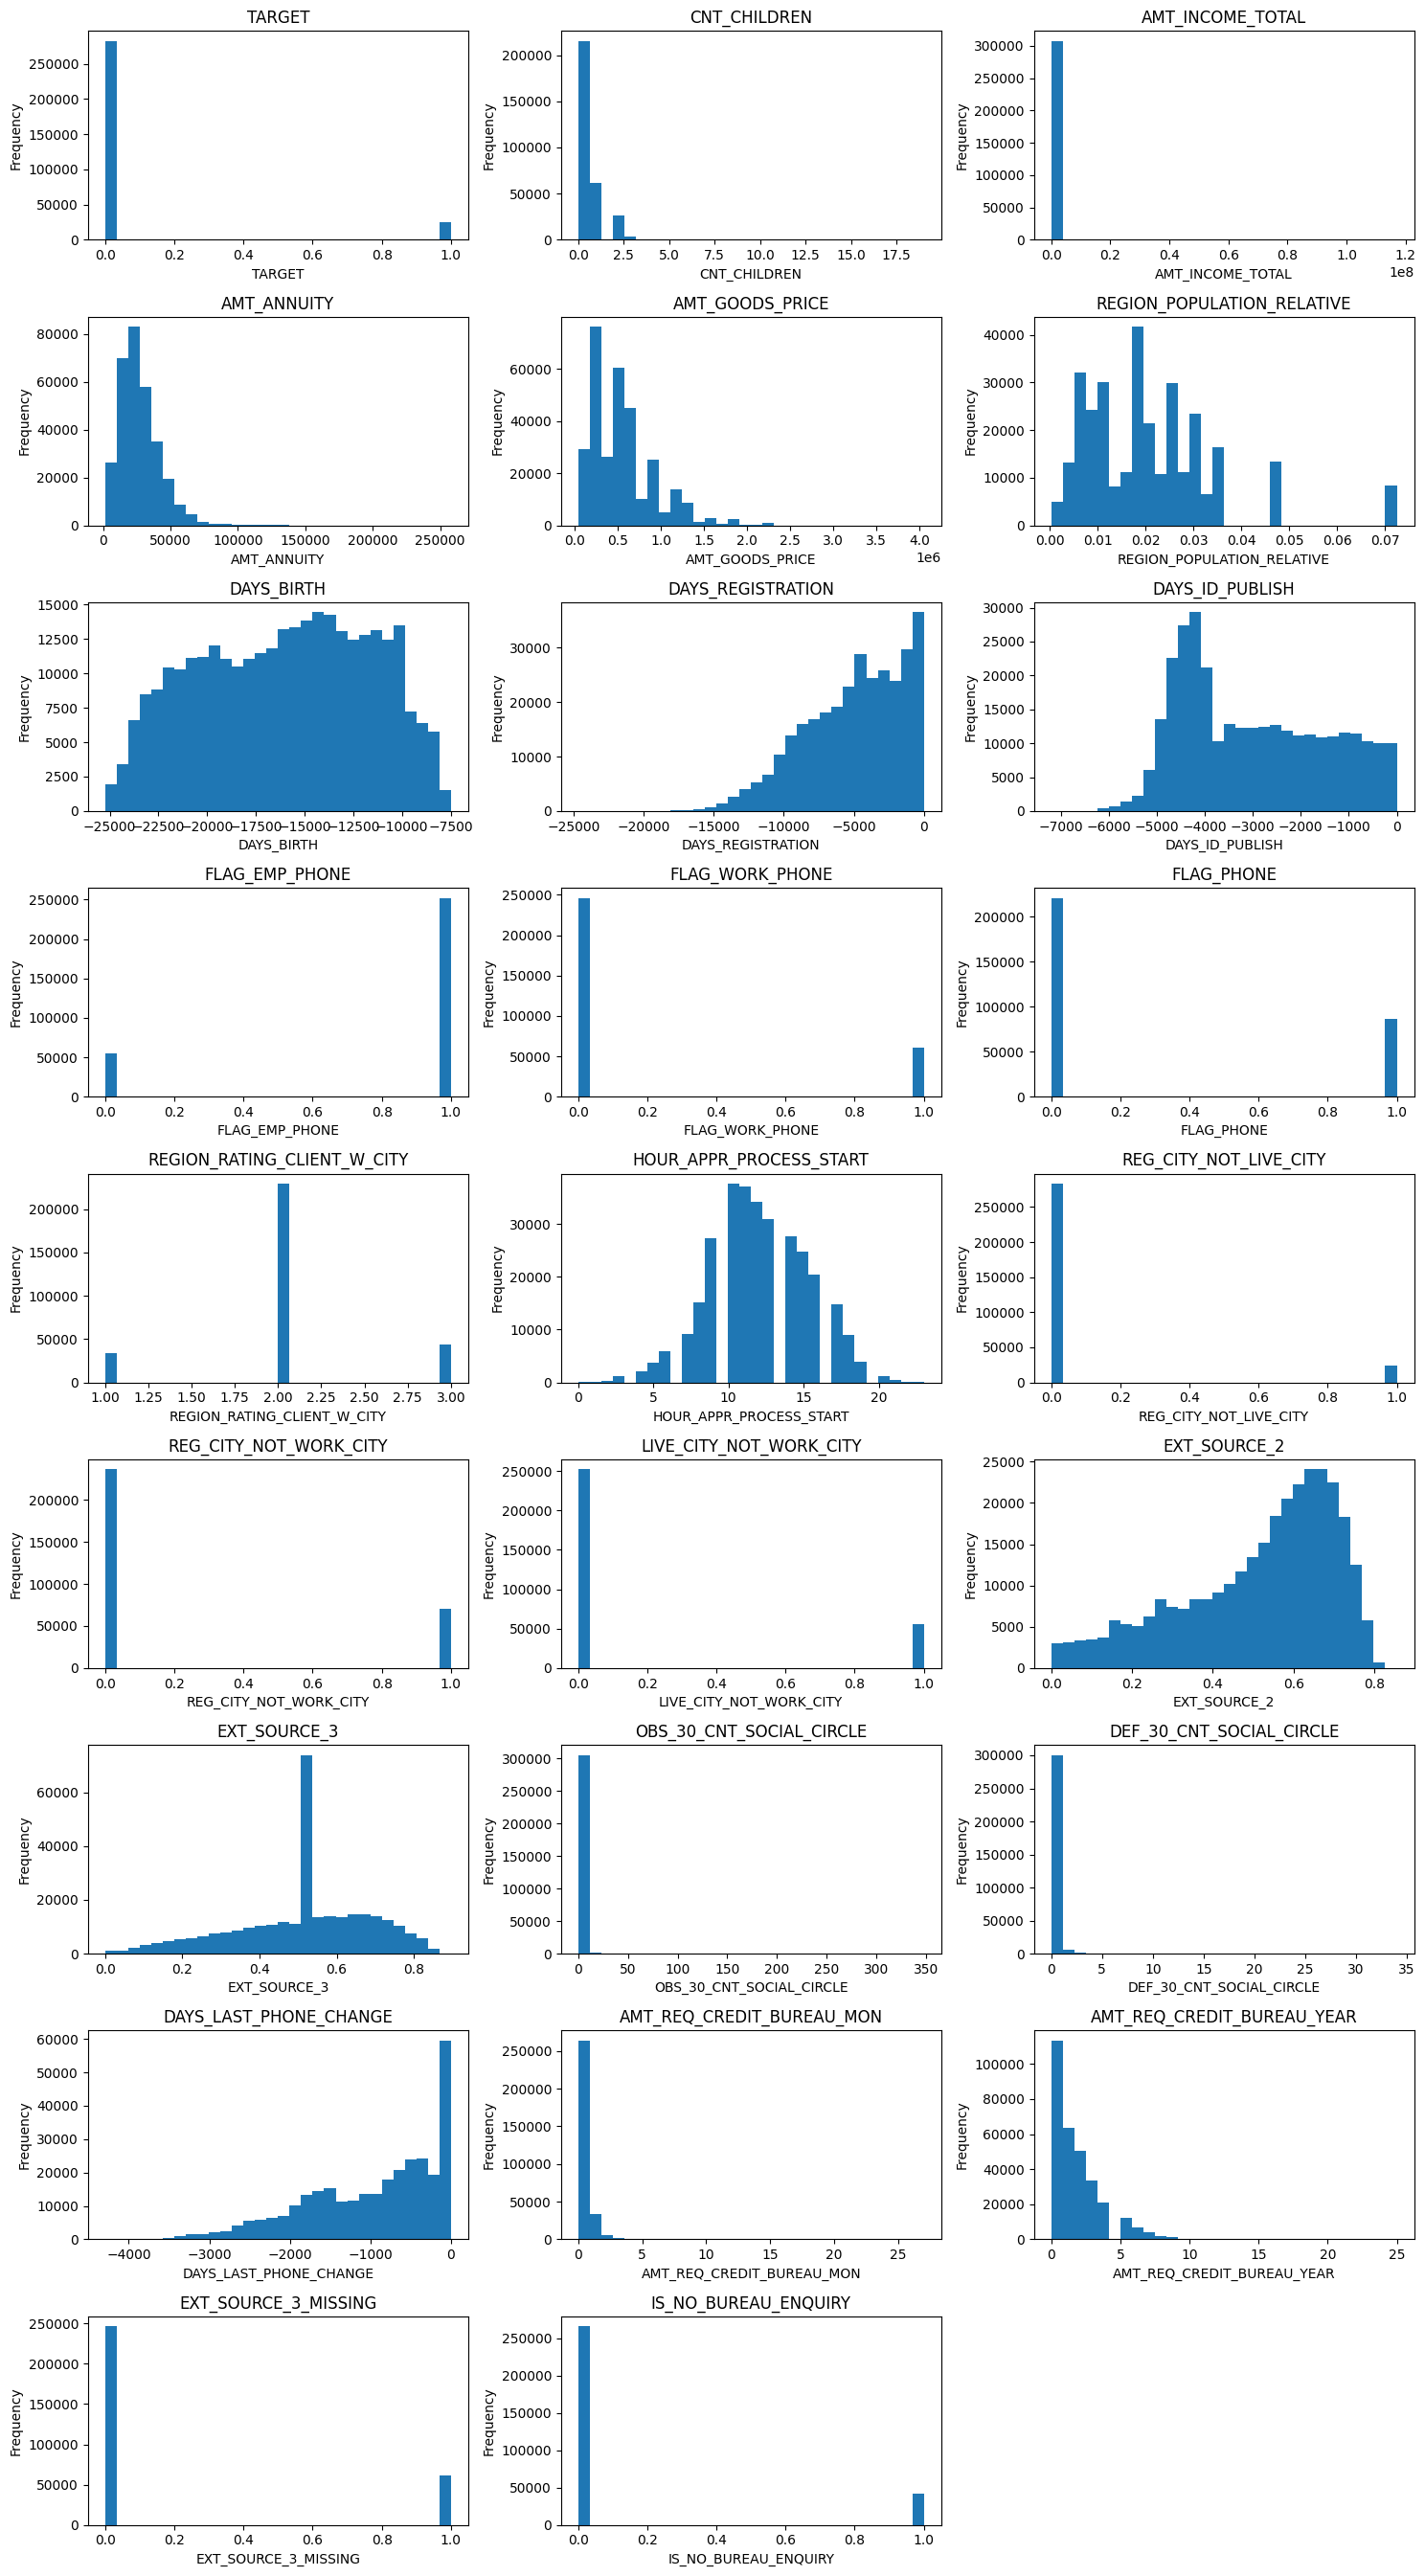

In [ ]:
import matplotlib.pyplot as plt
import math

# Mengamati distribusi kolom numerik

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

n_cols = 3  # jumlah kolom saat menampilkan subplot
n_rows = math.ceil(len(num_cols) / n_cols)


fig, axes = plt.subplots(
    n_rows, n_cols,
    figsize=(n_cols * 5, n_rows * 3)
)

axes = axes.flatten()

for i, col in enumerate(num_cols):
    axes[i].hist(df[col], bins=30)
    axes[i].set_title(col)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel("Frequency")

# hapus subplot kosong (kalau jumlah feature tidak pas grid)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

In [ ]:
import scipy.stats as stats
import numpy as np

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# Mengamati distribusi data menggunakan statistik
def best_fit_distribution(df, bins=50):
    data = df.dropna().values

    # histogram data
    y, x = np.histogram(data, bins=bins, density=True)
    x_mid = (x[:-1] + x[1:]) / 2

    distributions = [
        stats.norm,
        stats.lognorm,
        stats.expon,
        stats.gamma,
        stats.beta,
        stats.uniform
    ]

    best_dist = None
    best_params = None
    best_sse = np.inf

    for dist in distributions:
        try:
            params = dist.fit(data)
            pdf = dist.pdf(x_mid, *params)
            sse = np.sum((y - pdf) ** 2)

            if sse < best_sse:
                best_sse = sse
                best_dist = dist
                best_params = params
        except Exception:
            pass

    return best_dist.name, best_params, best_sse

In [ ]:
# inisiasi
results = []

num_cols = df.select_dtypes(include=['int64', 'float64']).columns

# jalankan fungsi
for col in num_cols:
    dist_name, params, sse = best_fit_distribution(df[col])
    results.append({
        "feature": col,
        "best_distribution": dist_name,
        "sse": sse
    })

dist_df = pd.DataFrame(results)
dist_df

/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6930: RuntimeWarning: overflow encountered in divide
  return np.sum((1 + np.log(shifted/scale)/shape**2)/shifted)
/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:796: RuntimeWarning: invalid value encountered in sqrt
  sk = 2*(b-a)*np.sqrt(a + b + 1) / (a + b + 2) / np.sqrt(a*b)
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:801: RuntimeWarning: The iteration is not making good progress, as measured by the 
 improvement from the last ten iterations.
  a, b = optimize.fsolve(func, (1.0, 1.0))
/usr/local/lib/python3.12/dist-packages/scipy/stats/_continuous_distns.py:6921: RuntimeWarning: invalid value encountered in log
  lndata = np.log(data - loc)
/usr/local/lib/python3.12/dist-packages

,feature,best_distribution,sse
0,TARGET,beta,9.118304e+02
1,CNT_CHILDREN,expon,6.122651e-01
2,AMT_INCOME_TOTAL,uniform,1.790306e-13
3,AMT_ANNUITY,beta,2.680464e-11
4,AMT_GOODS_PRICE,gamma,4.293595e-12
5,REGION_POPULATION_RELATIVE,beta,1.065753e+04
6,DAYS_BIRTH,beta,2.658340e-09
7,DAYS_REGISTRATION,beta,6.575668e-09
8,DAYS_ID_PUBLISH,lognorm,2.513933e-07
9,FLAG_EMP_PHONE,norm,1.709791e+03


Overall default rate: 8.07%


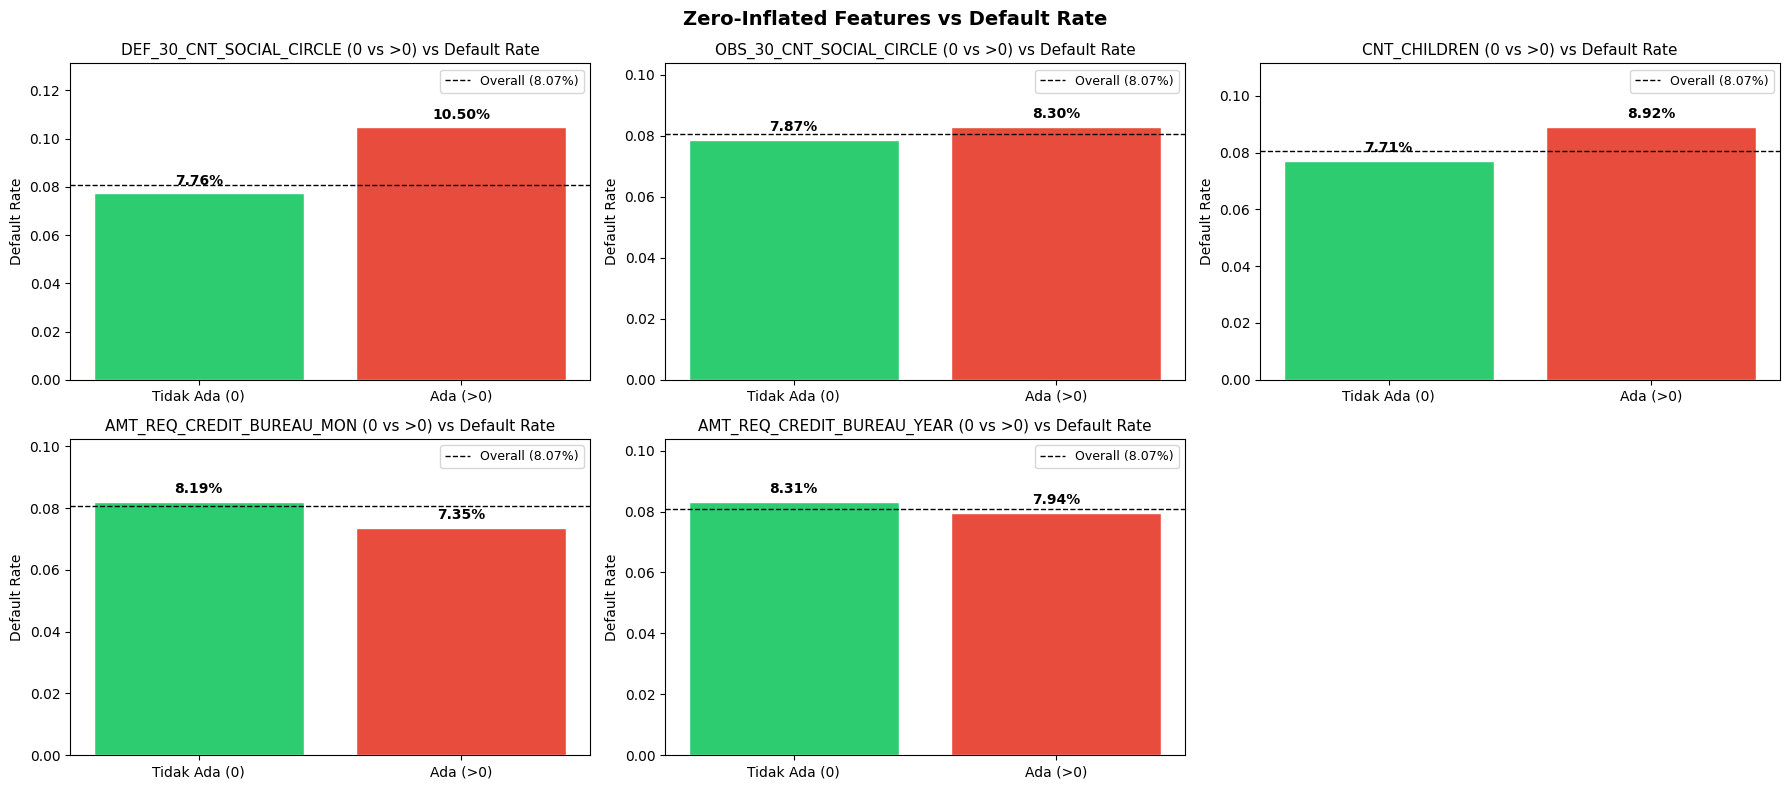

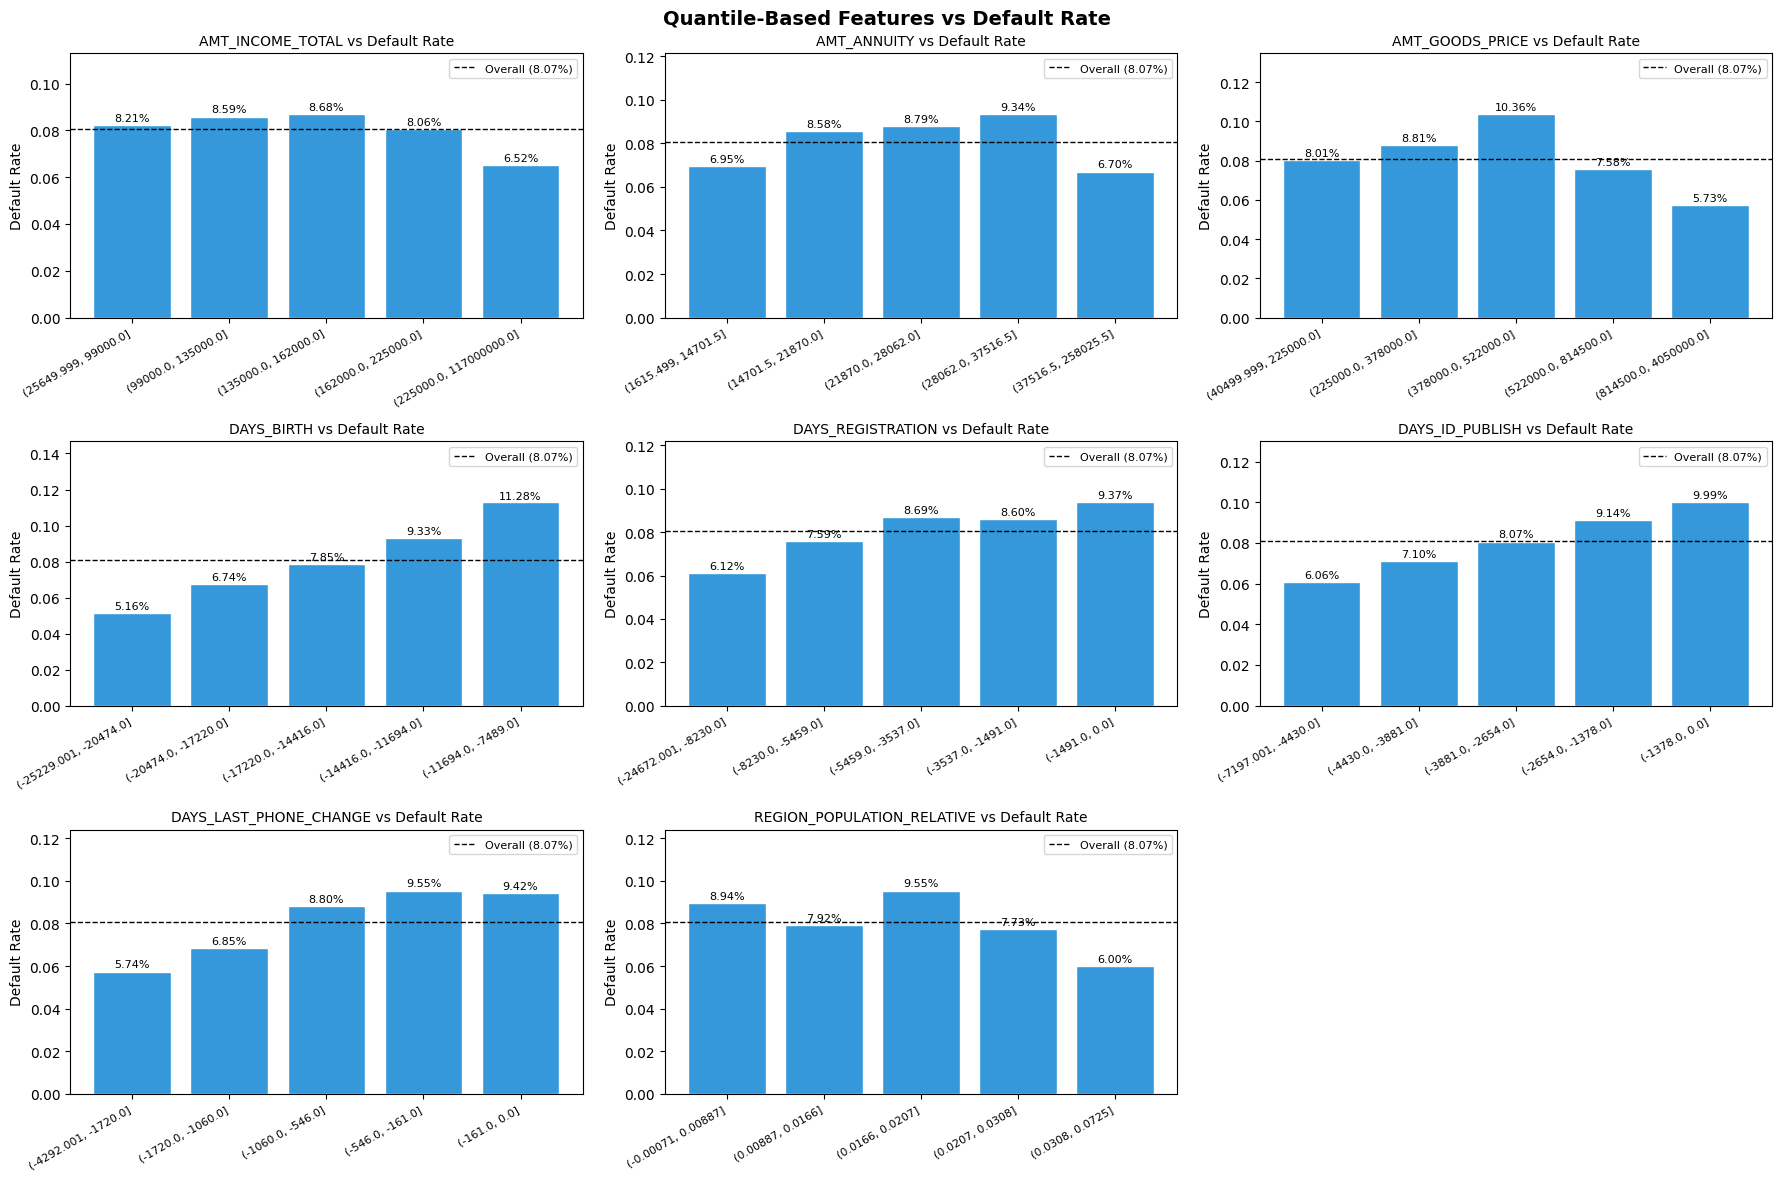

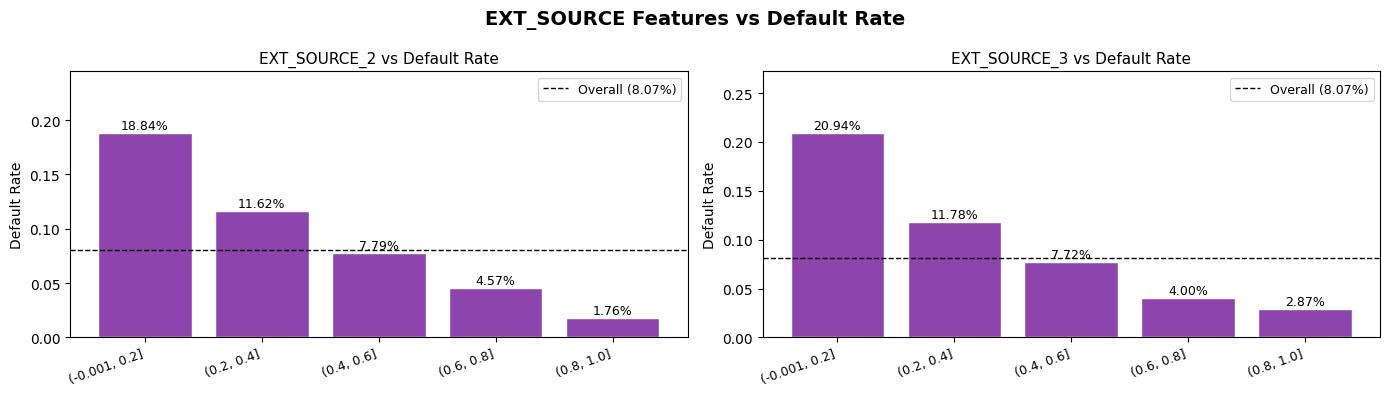

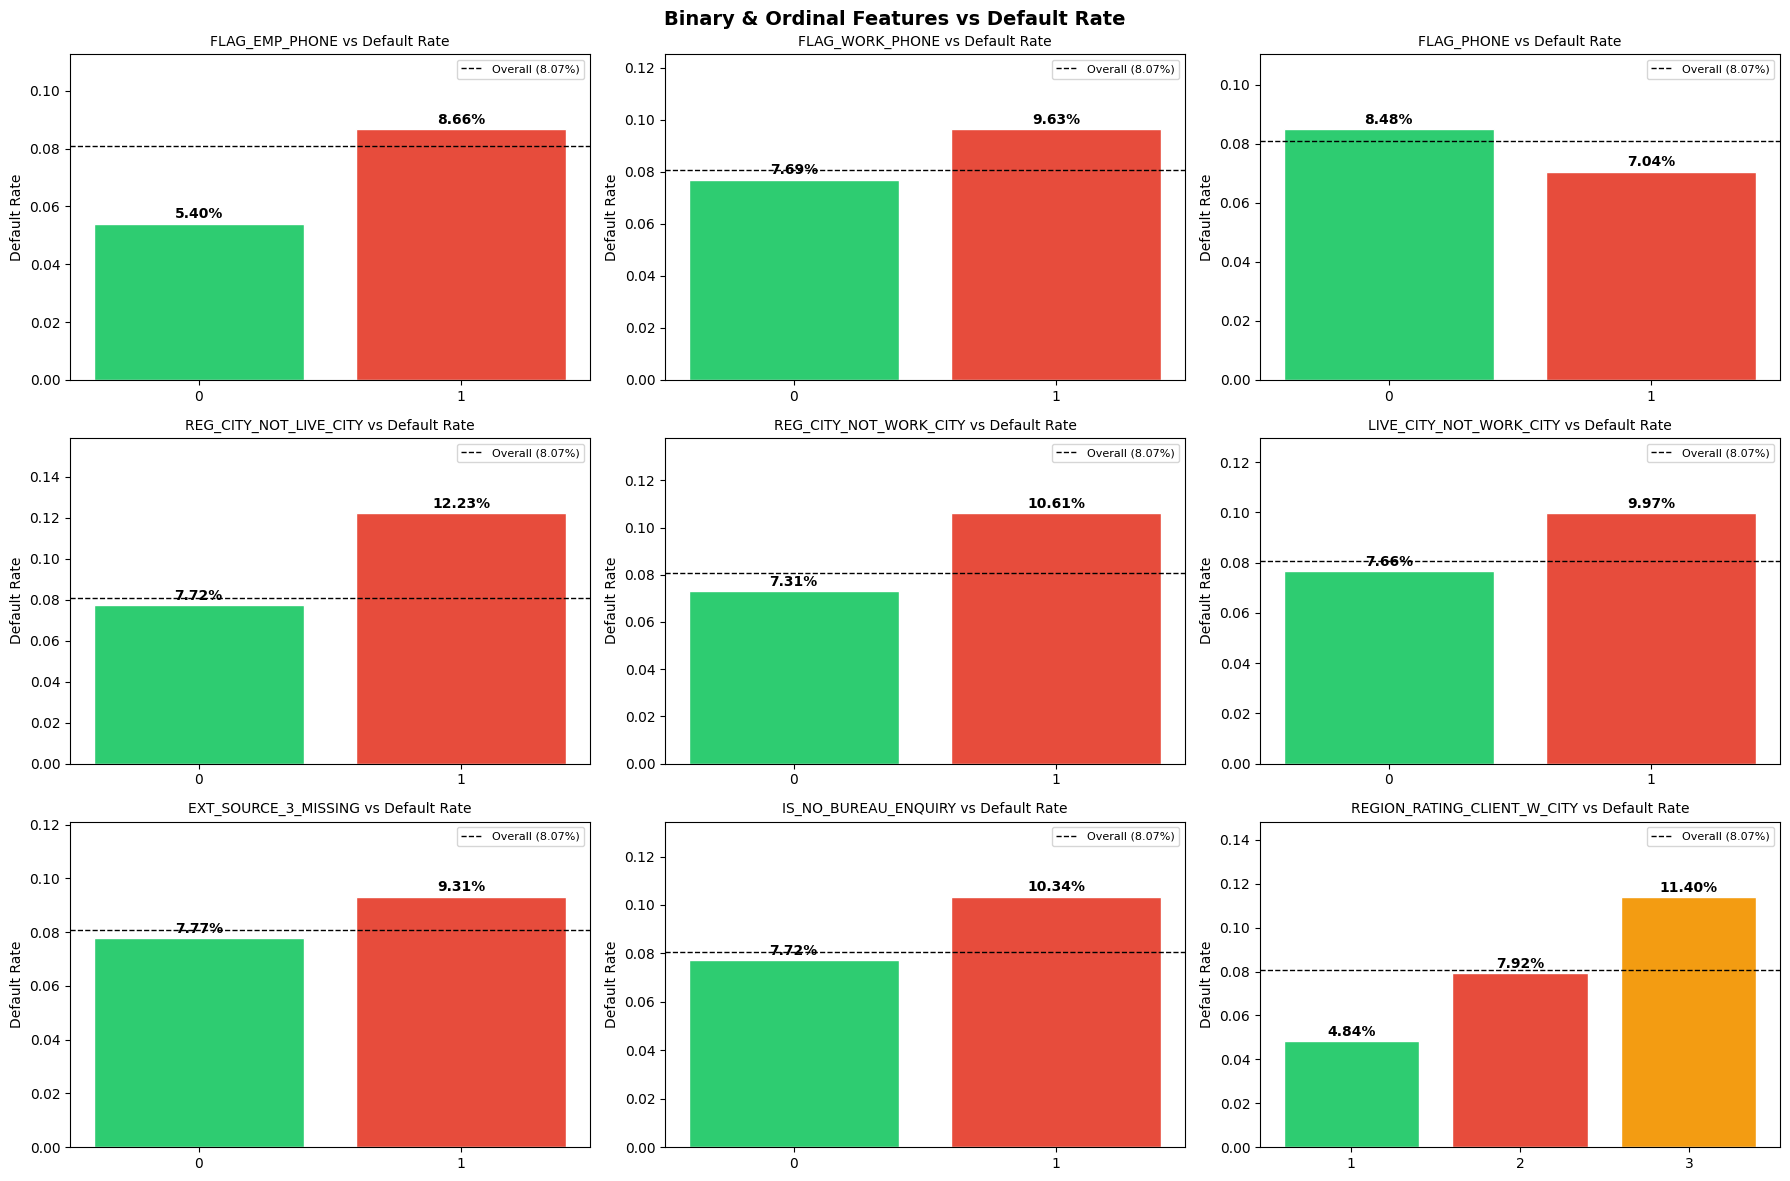


RINGKASAN DEFAULT RATE — ZERO-INFLATED FEATURES
DEF_30_CNT_SOCIAL_CIRCLE:
  Tidak Ada (0): 7.76%  |  Ada (>0): 10.50%  |  Selisih: +2.74%
OBS_30_CNT_SOCIAL_CIRCLE:
  Tidak Ada (0): 7.87%  |  Ada (>0): 8.30%  |  Selisih: +0.43%
CNT_CHILDREN:
  Tidak Ada (0): 7.71%  |  Ada (>0): 8.92%  |  Selisih: +1.21%
AMT_REQ_CREDIT_BUREAU_MON:
  Tidak Ada (0): 8.19%  |  Ada (>0): 7.35%  |  Selisih: -0.84%
AMT_REQ_CREDIT_BUREAU_YEAR:
  Tidak Ada (0): 8.31%  |  Ada (>0): 7.94%  |  Selisih: -0.37%


In [ ]:
TARGET_COL = 'TARGET'
overall_rate = df[TARGET_COL].mean()
print(f'Overall default rate: {overall_rate:.2%}')

# ============================================================
# KATEGORI KOLOM BERDASARKAN KARAKTERISTIK DISTRIBUSI
# ============================================================

# 1. Zero-inflated → banyak nilai 0, sebagian kecil > 0
zero_inflated = [
    'DEF_30_CNT_SOCIAL_CIRCLE',
    'OBS_30_CNT_SOCIAL_CIRCLE',
    'CNT_CHILDREN',
    'AMT_REQ_CREDIT_BUREAU_MON',
    'AMT_REQ_CREDIT_BUREAU_YEAR',
]

# 2. Continuous right-skewed → pakai quantile cut (qcut)
quantile_cols = [
    'AMT_INCOME_TOTAL',
    'AMT_ANNUITY',
    'AMT_GOODS_PRICE',
    'DAYS_BIRTH',
    'DAYS_REGISTRATION',
    'DAYS_ID_PUBLISH',
    'DAYS_LAST_PHONE_CHANGE',
    'REGION_POPULATION_RELATIVE',
]

# 3. Beta/bounded [0–1] → pakai equal-width cut
beta_cols = ['EXT_SOURCE_2', 'EXT_SOURCE_3']
beta_bins = {
    'EXT_SOURCE_2': [0, 0.2, 0.4, 0.6, 0.8, 1.0],
    'EXT_SOURCE_3': [0, 0.2, 0.4, 0.6, 0.8, 1.0],
}

# 4. Binary / ordinal → groupby langsung
binary_cols = [
    'FLAG_EMP_PHONE',
    'FLAG_WORK_PHONE',
    'FLAG_PHONE',
    'REG_CITY_NOT_LIVE_CITY',
    'REG_CITY_NOT_WORK_CITY',
    'LIVE_CITY_NOT_WORK_CITY',
    'EXT_SOURCE_3_MISSING',
    'IS_NO_BUREAU_ENQUIRY',
    'REGION_RATING_CLIENT_W_CITY',
]

n_cols = 3

# ============================================================
# 1. ZERO-INFLATED → binarisasi (0 vs > 0)
# ============================================================
n_rows = -(-len(zero_inflated) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(zero_inflated):
    flag_col = f'{col}_flag'
    df[flag_col] = (df[col] > 0).astype(int)
    rate = df.groupby(flag_col)[TARGET_COL].mean()

    bars = axes[i].bar(['Tidak Ada (0)', 'Ada (>0)'], rate.values,
                       color=['#2ecc71', '#e74c3c'], edgecolor='white')
    axes[i].axhline(overall_rate, color='black', linestyle='--',
                    linewidth=1, label=f'Overall ({overall_rate:.2%})')

    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.002,
                     f'{val:.2%}', ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

    axes[i].set_title(f'{col} (0 vs >0) vs Default Rate', fontsize=11)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_ylim(0, max(rate.values) * 1.25)
    axes[i].legend(fontsize=9)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Zero-Inflated Features vs Default Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 2. QUANTILE-BASED → qcut 5 bucket
# ============================================================
n_rows = -(-len(quantile_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(quantile_cols):
    try:
        temp_bin = pd.qcut(df[col], q=5, duplicates='drop')
        rate = df.groupby(temp_bin, observed=True)[TARGET_COL].mean().sort_index()

        bars = axes[i].bar(range(len(rate)), rate.values, color='#3498db',
                           edgecolor='white')
        axes[i].axhline(overall_rate, color='black', linestyle='--',
                        linewidth=1, label=f'Overall ({overall_rate:.2%})')

        for bar, val in zip(bars, rate.values):
            axes[i].text(bar.get_x() + bar.get_width()/2,
                         bar.get_height() + 0.001,
                         f'{val:.2%}', ha='center', va='bottom', fontsize=8)

        labels = [str(x) for x in rate.index]
        axes[i].set_xticks(range(len(rate)))
        axes[i].set_xticklabels(labels, rotation=30, ha='right', fontsize=8)
        axes[i].set_title(f'{col} vs Default Rate', fontsize=10)
        axes[i].set_ylabel('Default Rate')
        axes[i].set_ylim(0, max(rate.values) * 1.3)
        axes[i].legend(fontsize=8)

    except Exception as e:
        axes[i].set_title(f'{col} — Error: {e}')

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Quantile-Based Features vs Default Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 3. BETA / EQUAL-WIDTH → EXT_SOURCE_2 & EXT_SOURCE_3
# ============================================================
fig, axes = plt.subplots(1, len(beta_cols), figsize=(len(beta_cols) * 7, 4))

for i, col in enumerate(beta_cols):
    temp_bin = pd.cut(df[col], bins=beta_bins[col], include_lowest=True)
    rate = df.groupby(temp_bin, observed=True)[TARGET_COL].mean().sort_index()

    bars = axes[i].bar(range(len(rate)), rate.values, color='#8e44ad',
                       edgecolor='white')
    axes[i].axhline(overall_rate, color='black', linestyle='--',
                    linewidth=1, label=f'Overall ({overall_rate:.2%})')

    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{val:.2%}', ha='center', va='bottom', fontsize=9)

    labels = [str(x) for x in rate.index]
    axes[i].set_xticks(range(len(rate)))
    axes[i].set_xticklabels(labels, rotation=20, ha='right', fontsize=9)
    axes[i].set_title(f'{col} vs Default Rate', fontsize=11)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_ylim(0, max(rate.values) * 1.3)
    axes[i].legend(fontsize=9)

plt.suptitle('EXT_SOURCE Features vs Default Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 4. BINARY & ORDINAL → groupby langsung
# ============================================================
n_rows = -(-len(binary_cols) // n_cols)
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(binary_cols):
    rate = df.groupby(col)[TARGET_COL].mean().sort_index()
    colors = ['#2ecc71', '#e74c3c', '#f39c12', '#3498db'][:len(rate)]

    bars = axes[i].bar([str(x) for x in rate.index], rate.values,
                       color=colors, edgecolor='white')
    axes[i].axhline(overall_rate, color='black', linestyle='--',
                    linewidth=1, label=f'Overall ({overall_rate:.2%})')

    for bar, val in zip(bars, rate.values):
        axes[i].text(bar.get_x() + bar.get_width()/2,
                     bar.get_height() + 0.001,
                     f'{val:.2%}', ha='center', va='bottom',
                     fontsize=10, fontweight='bold')

    axes[i].set_title(f'{col} vs Default Rate', fontsize=10)
    axes[i].set_ylabel('Default Rate')
    axes[i].set_ylim(0, max(rate.values) * 1.3)
    axes[i].legend(fontsize=8)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Binary & Ordinal Features vs Default Rate', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# ============================================================
# 5. RINGKASAN — tabel default rate per fitur (untuk referensi)
# ============================================================
print('\n' + '='*60)
print('RINGKASAN DEFAULT RATE — ZERO-INFLATED FEATURES')
print('='*60)
for col in zero_inflated:
    flag_col = f'{col}_flag'
    rate = df.groupby(flag_col)[TARGET_COL].mean()
    selisih = rate.get(1, 0) - rate.get(0, 0)
    print(f'{col}:')
    print(f'  Tidak Ada (0): {rate.get(0, 0):.2%}  |  Ada (>0): {rate.get(1, 0):.2%}  |  Selisih: {selisih:+.2%}')

INFORMATION VALUE PER KOLOM KATEGORIK
Fitur                                     IV  Kekuatan
-------------------------------------------------------
  OCCUPATION_TYPE                     0.0829  Lemah ⚠️
  ORGANIZATION_TYPE                   0.0734  Lemah ⚠️
  NAME_INCOME_TYPE                    0.0596  Lemah ⚠️
  NAME_EDUCATION_TYPE                 0.0508  Lemah ⚠️
  CODE_GENDER                         0.0388  Lemah ⚠️
  NAME_FAMILY_STATUS                  0.0218  Lemah ⚠️
  NAME_HOUSING_TYPE                   0.0157  Useless ❌
  NAME_CONTRACT_TYPE                  0.0150  Useless ❌
  FLAG_OWN_CAR                        0.0066  Useless ❌
  NAME_TYPE_SUITE                     0.0021  Useless ❌
  WEEKDAY_APPR_PROCESS_START          0.0007  Useless ❌
  FLAG_OWN_REALTY                     0.0005  Useless ❌


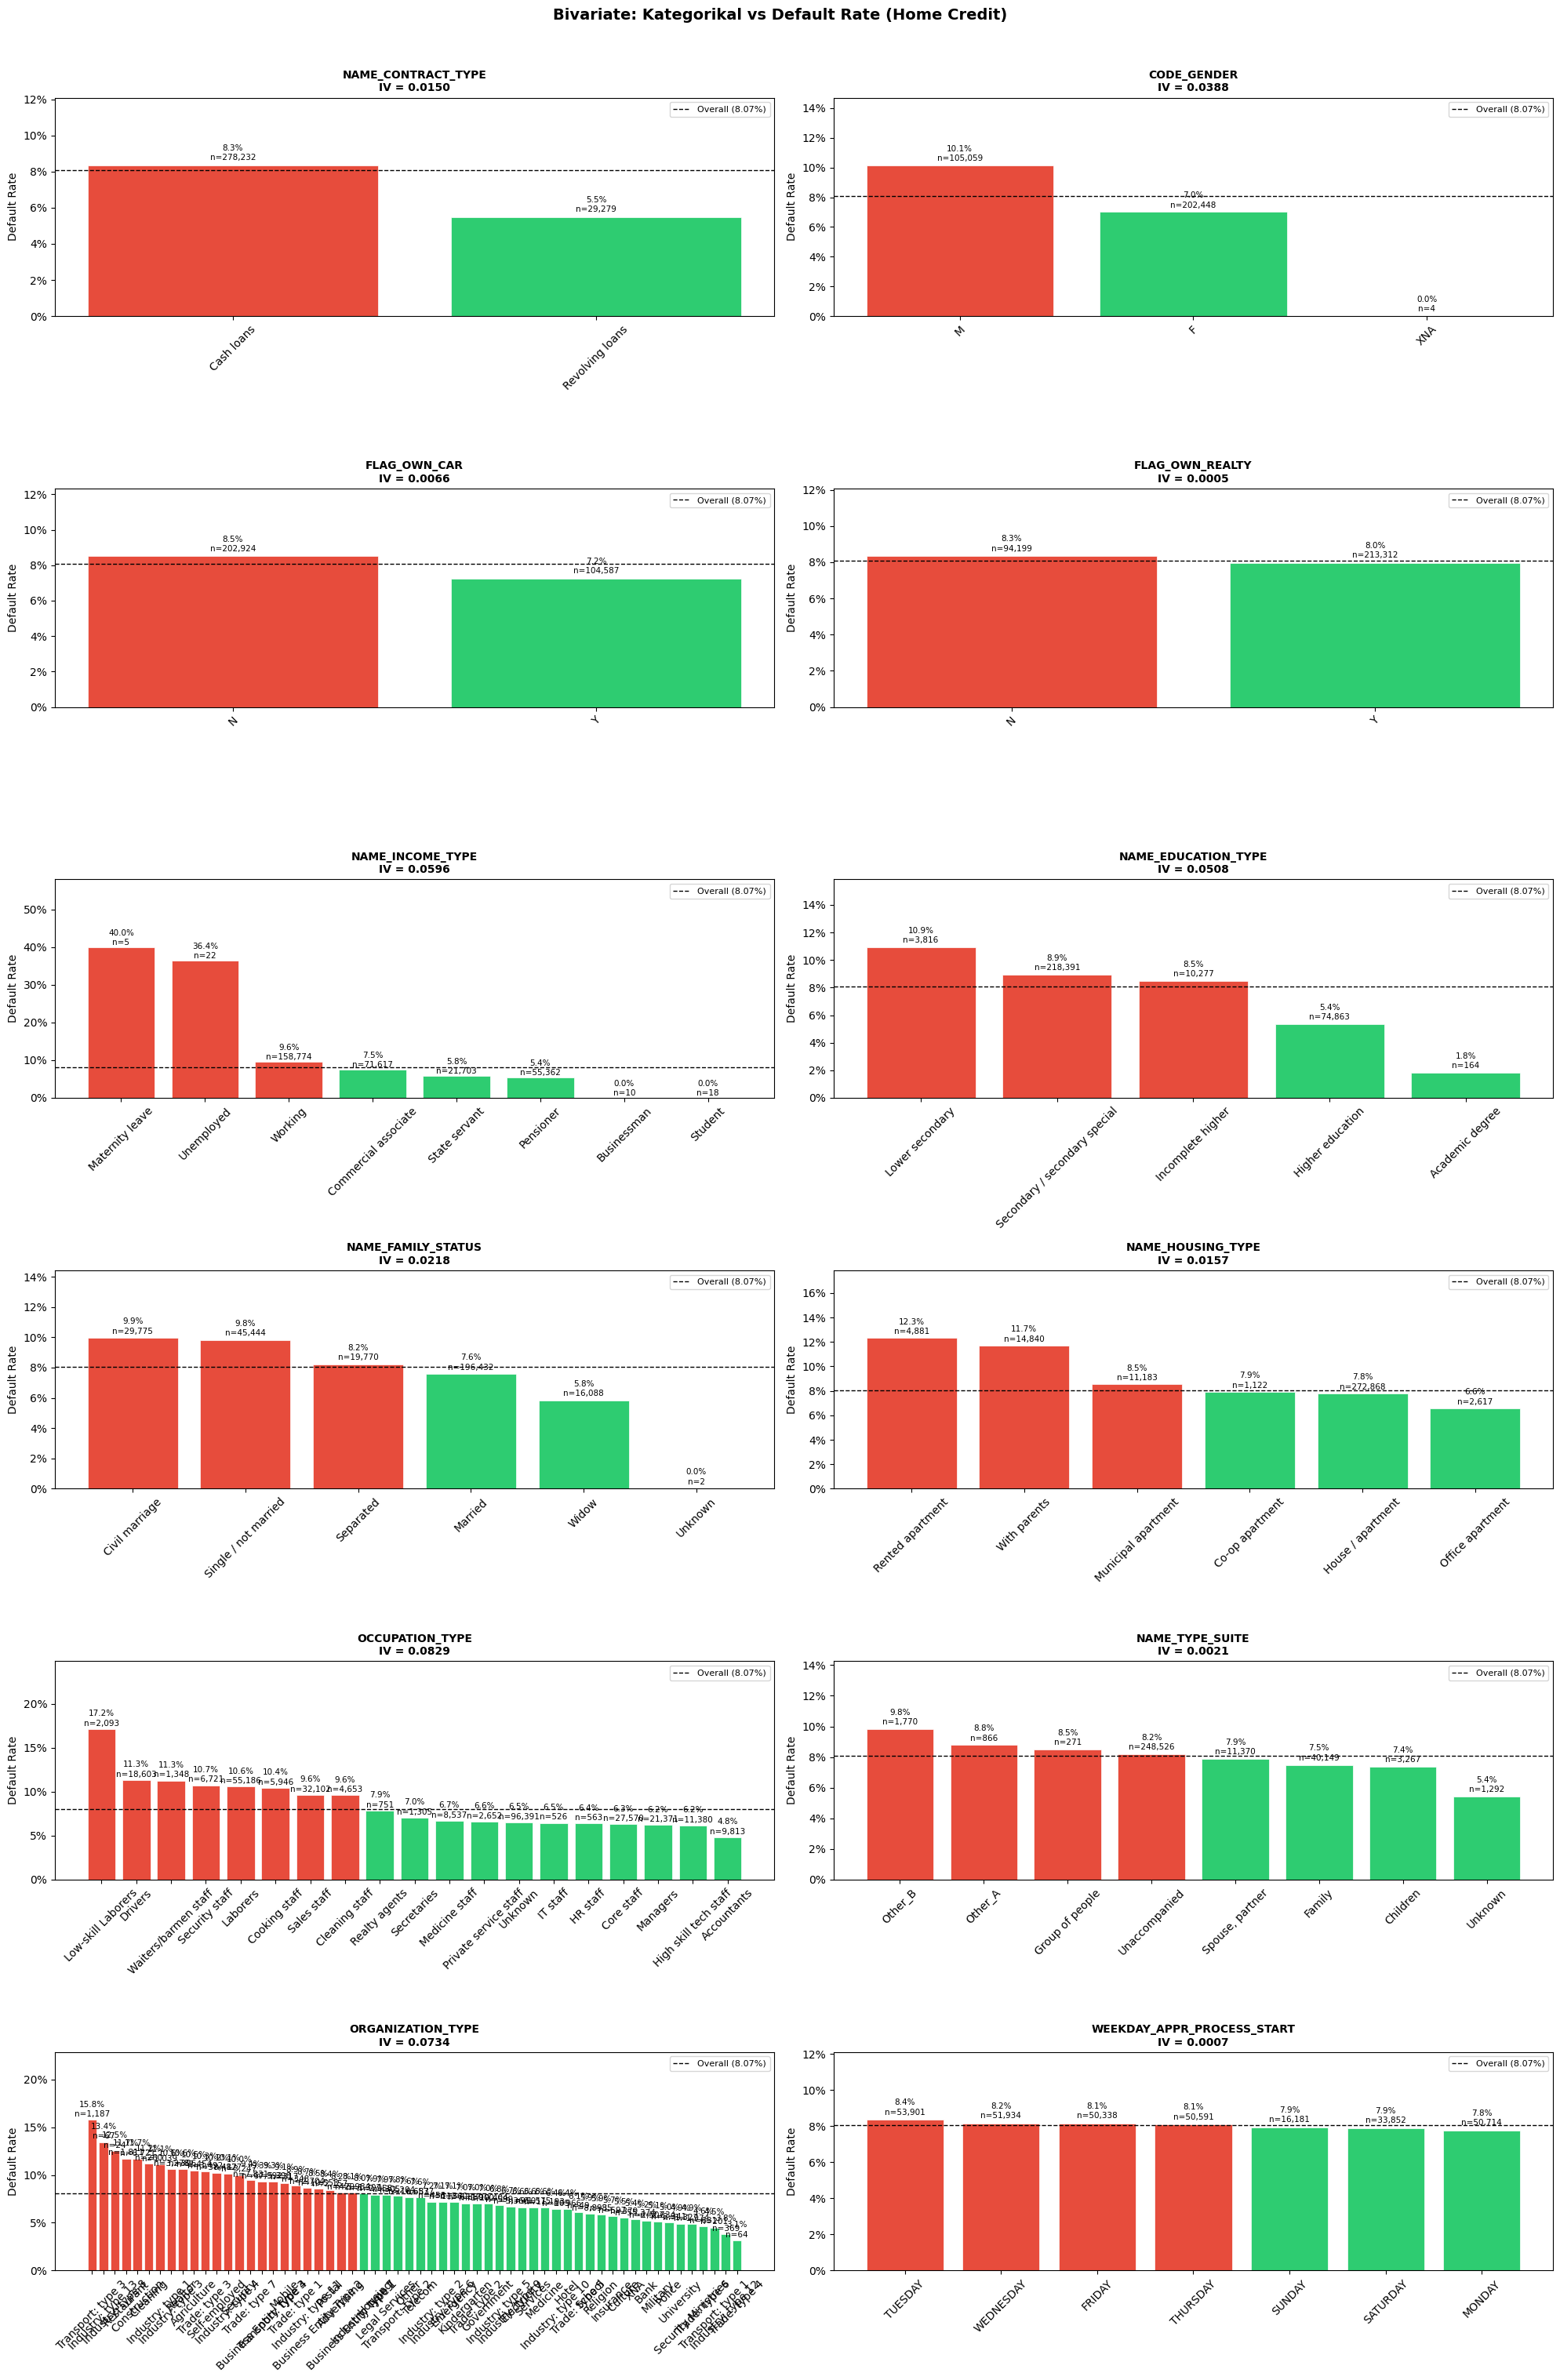

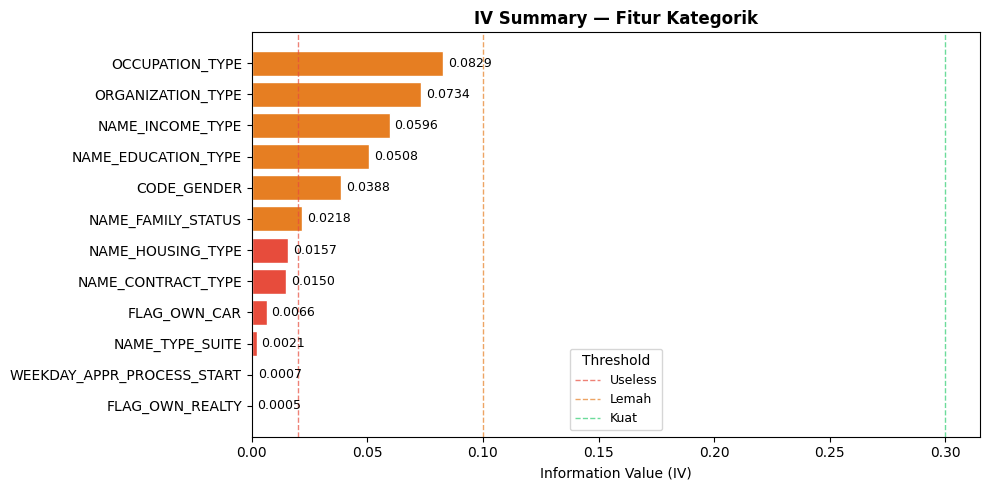

In [ ]:
# Kolom kategorik yang akan dianalisis
cat_cols = [
    'NAME_CONTRACT_TYPE',
    'CODE_GENDER',
    'FLAG_OWN_CAR',
    'FLAG_OWN_REALTY',
    'NAME_INCOME_TYPE',
    'NAME_EDUCATION_TYPE',
    'NAME_FAMILY_STATUS',
    'NAME_HOUSING_TYPE',
    'OCCUPATION_TYPE',
    'NAME_TYPE_SUITE',
    'ORGANIZATION_TYPE',
    'WEEKDAY_APPR_PROCESS_START',
]

# ============================================================
# STEP 1 — Hitung Information Value (IV) per kolom kategorik
# ============================================================
# IV mengukur seberapa kuat fitur membedakan default vs non-default
# Interpretasi IV:
#   < 0.02  → tidak ada prediksi (useless)
#   0.02–0.1 → prediksi lemah
#   0.1–0.3  → prediksi sedang
#   0.3–0.5  → prediksi kuat
#   > 0.5    → prediksi sangat kuat (perlu dicurigai leakage)

def calculate_iv(df, col, target):
    total_good = (df[target] == 0).sum()
    total_bad  = (df[target] == 1).sum()

    grouped = df.groupby(col)[target].agg(
        bad='sum',
        total='count'
    ).reset_index()
    grouped['good'] = grouped['total'] - grouped['bad']

    grouped['dist_bad']  = grouped['bad']  / total_bad
    grouped['dist_good'] = grouped['good'] / total_good

    # Hindari log(0)
    grouped['dist_bad']  = grouped['dist_bad'].replace(0, 1e-10)
    grouped['dist_good'] = grouped['dist_good'].replace(0, 1e-10)

    grouped['woe'] = np.log(grouped['dist_good'] / grouped['dist_bad'])
    grouped['iv']  = (grouped['dist_good'] - grouped['dist_bad']) * grouped['woe']

    return grouped['iv'].sum()

iv_results = []
for col in cat_cols:
    iv_val = calculate_iv(df, col, TARGET_COL)
    iv_results.append({'feature': col, 'iv': iv_val})

iv_df = pd.DataFrame(iv_results).sort_values('iv', ascending=False)

print('=' * 55)
print('INFORMATION VALUE PER KOLOM KATEGORIK')
print('=' * 55)
print(f"{'Fitur':<35} {'IV':>8}  {'Kekuatan'}")
print('-' * 55)
for _, row in iv_df.iterrows():
    if row['iv'] < 0.02:
        strength = 'Useless ❌'
    elif row['iv'] < 0.1:
        strength = 'Lemah ⚠️'
    elif row['iv'] < 0.3:
        strength = 'Sedang ✅'
    elif row['iv'] < 0.5:
        strength = 'Kuat 💪'
    else:
        strength = 'Sangat kuat ⭐'
    print(f"  {row['feature']:<33} {row['iv']:>8.4f}  {strength}")

# ============================================================
# STEP 2 — Plot default rate per kategori + IV di judul
# ============================================================
def plot_cat_vs_target(df, cat_cols, target, iv_df, n_cols=2):
    n_rows = -(-len(cat_cols) // n_cols)
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
    axes = axes.flatten()

    overall_mean = df[target].mean()

    for i, col in enumerate(cat_cols):
        summary = (
            df.groupby(col)[target]
            .agg(['mean', 'count'])
            .reset_index()
        )
        summary.columns = [col, 'default_rate', 'count']
        summary = summary.sort_values('default_rate', ascending=False)

        colors = [
            '#e74c3c' if r > overall_mean else '#2ecc71'
            for r in summary['default_rate']
        ]

        bars = axes[i].bar(
            summary[col].astype(str),
            summary['default_rate'],
            color=colors,
            edgecolor='white',
            linewidth=0.5
        )

        axes[i].axhline(
            y=overall_mean,
            color='black',
            linestyle='--',
            linewidth=1,
            label=f'Overall ({overall_mean:.2%})'
        )

        # Label persentase di atas bar
        for bar, rate, cnt in zip(bars, summary['default_rate'], summary['count']):
            axes[i].text(
                bar.get_x() + bar.get_width() / 2,
                bar.get_height() + 0.002,
                f'{rate:.1%}\nn={cnt:,}',
                ha='center', va='bottom',
                fontsize=7.5, linespacing=1.3
            )

        # Ambil IV dari iv_df
        iv_row = iv_df[iv_df['feature'] == col]
        iv_val = iv_row['iv'].values[0] if len(iv_row) > 0 else 0.0

        axes[i].set_title(
            f'{col}\nIV = {iv_val:.4f}',
            fontsize=10, fontweight='bold'
        )
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Default Rate')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(fontsize=8)
        axes[i].yaxis.set_major_formatter(
            plt.FuncFormatter(lambda x, _: f'{x:.0%}')
        )
        # Beri ruang di atas bar untuk label
        max_rate = summary['default_rate'].max()
        axes[i].set_ylim(0, max_rate * 1.45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.suptitle(
        'Bivariate: Kategorikal vs Default Rate (Home Credit)',
        fontsize=14, fontweight='bold', y=1.01
    )
    plt.tight_layout()
    plt.show()

plot_cat_vs_target(df, cat_cols, TARGET_COL, iv_df)

# ============================================================
# STEP 3 — Bar chart ringkasan IV semua fitur kategorik
# ============================================================
fig, ax = plt.subplots(figsize=(10, 5))

colors_iv = []
for iv in iv_df['iv']:
    if iv < 0.02:
        colors_iv.append('#e74c3c')
    elif iv < 0.1:
        colors_iv.append('#e67e22')
    elif iv < 0.3:
        colors_iv.append('#3498db')
    else:
        colors_iv.append('#2ecc71')

bars = ax.barh(iv_df['feature'], iv_df['iv'], color=colors_iv, edgecolor='white')

for bar, val in zip(bars, iv_df['iv']):
    ax.text(
        bar.get_width() + 0.002, bar.get_y() + bar.get_height()/2,
        f'{val:.4f}', va='center', fontsize=9
    )

# Garis threshold IV
for thresh, label, color in [
    (0.02, 'Useless', '#e74c3c'),
    (0.1,  'Lemah',   '#e67e22'),
    (0.3,  'Kuat',    '#2ecc71'),
]:
    ax.axvline(thresh, color=color, linestyle='--', linewidth=1, alpha=0.7, label=label)

ax.set_xlabel('Information Value (IV)')
ax.set_title('IV Summary — Fitur Kategorik', fontweight='bold')
ax.legend(title='Threshold', fontsize=9)
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [ ]:
import statsmodels.api as sm

# target
target_col = "TARGET"

y = df[target_col]

X = df.drop(columns=[target_col])

# data numerik saja
X = X.select_dtypes(include=['int64', 'float64'])

# Handle missing values by filling with 0
X = X.fillna(0)

# add intercept
X = sm.add_constant(X)

# logistic regression
logit_model = sm.Logit(y, X)
result = logit_model.fit(maxiter=200)

print(result.summary())

Optimization terminated successfully.
         Current function value: 0.255529
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                 TARGET   No. Observations:               307511
Model:                          Logit   Df Residuals:                   307480
Method:                           MLE   Df Model:                           30
Date:                Mon, 01 Jun 2026   Pseudo R-squ.:                 0.08917
Time:                        00:57:58   Log-Likelihood:                -78578.
converged:                       True   LL-Null:                       -86271.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -0.3230      0.076     -4.222  

In [ ]:
print(f'Shape sebelum: {df.shape}')

# ============================================================
# STEP 1 — DROP FITUR TIDAK SIGNIFIKAN
# ============================================================
# Dasar keputusan:
#   Kategorik : IV < 0.01 (useless)
#   Numerik   : selisih default rate kecil + p-value > 0.05 dari logit diagnostic

# -- Kategorik (IV terlalu kecil) --
drop_cat = [
    'FLAG_OWN_CAR',               # IV = 0.007, selisih hanya 1.3%
    'FLAG_OWN_REALTY',            # IV = 0.007, selisih hanya 0.3%
    'NAME_TYPE_SUITE',            # IV = 0.002, hampir noise
    'WEEKDAY_APPR_PROCESS_START', # IV = 0.0007, hari pengajuan tidak prediktif
]

# -- Numerik (selisih kecil + tidak signifikan di logit) --
drop_num = [
    'CNT_CHILDREN',               # p=0.979, selisih +1.2% saja
    'CNT_CHILDREN_flag',          # p=0.772, turunannya juga tidak signifikan
    'REGION_POPULATION_RELATIVE', # p=0.307, pola zig-zag di EDA
    'REG_CITY_NOT_WORK_CITY',     # p=0.504, tidak signifikan
    'LIVE_CITY_NOT_WORK_CITY',    # p=0.068, borderline + interpretasi lemah
    'OBS_30_CNT_SOCIAL_CIRCLE',   # p=0.124, selisih hanya +0.43%
    'OBS_30_CNT_SOCIAL_CIRCLE_flag', # turunannya juga lemah
    'AMT_REQ_CREDIT_BUREAU_MON',  # p=0.102, arah terbalik + tidak signifikan
    'AMT_REQ_CREDIT_BUREAU_MON_flag', # p=0.602
]

all_drop = [c for c in drop_cat + drop_num if c in df.columns]
df.drop(columns=all_drop, inplace=True)

print(f'Shape setelah drop: {df.shape}')
print(f'Kolom di-drop: {len(all_drop)}')

# ============================================================
# STEP 2 — FEATURE ENGINEERING
# ============================================================
# Tujuan: buat fitur baru yang lebih informatif dari kolom yang ada
# Dibagi 3 kelompok: waktu, rasio keuangan, agregasi skor

print('\n--- Membuat fitur baru ---')

# ── 2A. Transformasi Waktu (hari → tahun, nilai absolut) ────
# DAYS_* bernilai negatif → jadikan positif dan ubah ke tahun

df['AGE_YEARS'] = (-df['DAYS_BIRTH'] / 365).round(1)
df['REGISTRATION_YEARS'] = (-df['DAYS_REGISTRATION'] / 365).round(1)
df['ID_PUBLISH_YEARS'] = (-df['DAYS_ID_PUBLISH'] / 365).round(1)
df['PHONE_CHANGE_YEARS'] = (-df['DAYS_LAST_PHONE_CHANGE'] / 365).round(1)

# Drop kolom DAYS asli — sudah tergantikan oleh versi tahun
df.drop(columns=['DAYS_BIRTH', 'DAYS_REGISTRATION',
                 'DAYS_ID_PUBLISH', 'DAYS_LAST_PHONE_CHANGE'], inplace=True)

print('✓ Fitur waktu: AGE_YEARS, REGISTRATION_YEARS, ID_PUBLISH_YEARS, PHONE_CHANGE_YEARS')

# ── 2B. Rasio Keuangan ───────────────────────────────────────
# Rasio lebih informatif dari nilai absolut karena sudah normalize per klien

# Hindari pembagian dengan 0
eps = 1e-9

# Beban cicilan relatif terhadap pendapatan
df['ANNUITY_INCOME_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_INCOME_TOTAL'] + eps)

# Harga barang relatif terhadap pendapatan
df['GOODS_INCOME_RATIO'] = df['AMT_GOODS_PRICE'] / (df['AMT_INCOME_TOTAL'] + eps)

# Cicilan relatif terhadap harga barang (proxy LTV / down payment)
df['ANNUITY_GOODS_RATIO'] = df['AMT_ANNUITY'] / (df['AMT_GOODS_PRICE'] + eps)

print('✓ Rasio keuangan: ANNUITY_INCOME_RATIO, GOODS_INCOME_RATIO, ANNUITY_GOODS_RATIO')

# ── 2C. Agregasi EXT_SOURCE ──────────────────────────────────
# EXT_SOURCE_2 dan EXT_SOURCE_3 adalah fitur terkuat
# Kombinasikan untuk menangkap sinyal gabungan

df['EXT_SOURCE_MEAN'] = df[['EXT_SOURCE_2', 'EXT_SOURCE_3']].mean(axis=1)
df['EXT_SOURCE_MIN']  = df[['EXT_SOURCE_2', 'EXT_SOURCE_3']].min(axis=1)
df['EXT_SOURCE_PROD'] = df['EXT_SOURCE_2'] * df['EXT_SOURCE_3']

print('✓ Agregasi EXT_SOURCE: EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_PROD')

# ── 2D. Indikator Ketidakstabilan ────────────────────────────
# Gabungkan sinyal ketidakcocokan alamat menjadi skor tunggal

df['ADDRESS_MISMATCH_SCORE'] = df['REG_CITY_NOT_LIVE_CITY'].astype(int)

# Skor stabilitas dokumen — makin lama tidak ganti = lebih stabil
# Encode: baru ganti (< 1 tahun) = 1 (tidak stabil), sudah lama = 0
df['RECENTLY_CHANGED_ID']    = (df['ID_PUBLISH_YEARS'] < 1).astype(int)
df['RECENTLY_CHANGED_PHONE'] = (df['PHONE_CHANGE_YEARS'] < 1).astype(int)

print('✓ Indikator stabilitas: ADDRESS_MISMATCH_SCORE, RECENTLY_CHANGED_ID, RECENTLY_CHANGED_PHONE')

# ── 2E. Log Transform untuk Distribusi Skewed ────────────────
# Khusus untuk Logistic Regression agar distribusi lebih normal
# Tidak mempengaruhi LightGBM (tree-based tidak butuh ini)
# Gunakan log1p untuk menangani nilai 0 dengan aman

df['LOG_AMT_INCOME_TOTAL'] = np.log1p(df['AMT_INCOME_TOTAL'])
df['LOG_AMT_ANNUITY']      = np.log1p(df['AMT_ANNUITY'])
df['LOG_AMT_GOODS_PRICE']  = np.log1p(df['AMT_GOODS_PRICE'])

# Drop versi original — sudah ada versi log
# Catatan: versi original masih digunakan di rasio (2B), jadi drop setelah ini
df.drop(columns=['AMT_INCOME_TOTAL', 'AMT_ANNUITY', 'AMT_GOODS_PRICE'], inplace=True)

print('✓ Log transform: LOG_AMT_INCOME_TOTAL, LOG_AMT_ANNUITY, LOG_AMT_GOODS_PRICE')

# ── 2F. Outlier Capping (sebelum scaling) ────────────────────
# Cap di persentil 99 untuk fitur dengan outlier ekstrem

cap_cols = {
    'DEF_30_CNT_SOCIAL_CIRCLE': 99,   # max=34
    'AMT_REQ_CREDIT_BUREAU_YEAR': 99, # max=25
    'ANNUITY_INCOME_RATIO': 99,       # bisa sangat besar jika income kecil
    'GOODS_INCOME_RATIO': 99,
    'ANNUITY_GOODS_RATIO': 99,
}

for col, pct in cap_cols.items():
    if col in df.columns:
        cap_val = df[col].quantile(pct / 100)
        df[col] = df[col].clip(upper=cap_val)
        print(f'  Cap {col} at p{pct}: {cap_val:.4f}')

print('✓ Outlier capping selesai')

# ============================================================
# STEP 3 — RINGKASAN FITUR AKHIR
# ============================================================
num_cols = df.select_dtypes('number').columns.drop('TARGET').tolist()
cat_cols = df.select_dtypes('object').columns.tolist()

print(f'\n{"="*55}')
print(f'RINGKASAN FITUR SETELAH DROP + FEATURE ENGINEERING')
print(f'{"="*55}')
print(f'Shape akhir      : {df.shape}')
print(f'Fitur numerik    : {len(num_cols)}')
print(f'Fitur kategorik  : {len(cat_cols)}')
print(f'\nFitur numerik:')
for c in sorted(num_cols):
    print(f'  {c}')
print(f'\nFitur kategorik:')
for c in sorted(cat_cols):
    print(f'  {c}')

# Cek tidak ada missing yang tersisa di numerik
missing_check = df[num_cols].isnull().sum()
if missing_check.sum() == 0:
    print('\n✓ Tidak ada missing value di fitur numerik')
else:
    print('\n⚠️ Masih ada missing:')
    print(missing_check[missing_check > 0])

Shape sebelum: (307511, 43)
Shape setelah drop: (307511, 30)
Kolom di-drop: 13

--- Membuat fitur baru ---
✓ Fitur waktu: AGE_YEARS, REGISTRATION_YEARS, ID_PUBLISH_YEARS, PHONE_CHANGE_YEARS
✓ Rasio keuangan: ANNUITY_INCOME_RATIO, GOODS_INCOME_RATIO, ANNUITY_GOODS_RATIO
✓ Agregasi EXT_SOURCE: EXT_SOURCE_MEAN, EXT_SOURCE_MIN, EXT_SOURCE_PROD
✓ Indikator stabilitas: ADDRESS_MISMATCH_SCORE, RECENTLY_CHANGED_ID, RECENTLY_CHANGED_PHONE
✓ Log transform: LOG_AMT_INCOME_TOTAL, LOG_AMT_ANNUITY, LOG_AMT_GOODS_PRICE
  Cap DEF_30_CNT_SOCIAL_CIRCLE at p99: 2.0000
  Cap AMT_REQ_CREDIT_BUREAU_YEAR at p99: 8.0000
  Cap ANNUITY_INCOME_RATIO at p99: 0.4834
  Cap GOODS_INCOME_RATIO at p99: 11.9582
  Cap ANNUITY_GOODS_RATIO at p99: 0.1253
✓ Outlier capping selesai

RINGKASAN FITUR SETELAH DROP + FEATURE ENGINEERING
Shape akhir      : (307511, 39)
Fitur numerik    : 30
Fitur kategorik  : 8

Fitur numerik:
  ADDRESS_MISMATCH_SCORE
  AGE_YEARS
  AMT_REQ_CREDIT_BUREAU_YEAR
  AMT_REQ_CREDIT_BUREAU_YEAR_flag
  A

In [ ]:
for col in cat_cols:
  print(df[col].value_counts())


NAME_CONTRACT_TYPE
Cash loans         278232
Revolving loans     29279
Name: count, dtype: int64
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64
NAME_INCOME_TYPE
Working                 158774
Commercial associate     71617
Pensioner                55362
State servant            21703
Unemployed                  22
Student                     18
Businessman                 10
Maternity leave              5
Name: count, dtype: int64
NAME_EDUCATION_TYPE
Secondary / secondary special    218391
Higher education                  74863
Incomplete higher                 10277
Lower secondary                    3816
Academic degree                     164
Name: count, dtype: int64
NAME_FAMILY_STATUS
Married                 196432
Single / not married     45444
Civil marriage           29775
Separated                19770
Widow                    16088
Unknown                      2
Name: count, dtype: int64
NAME_HOUSING_TYPE
House / apartment      272868
With pa

In [ ]:
# replace XNA value in CODE_GENDER with Mode
mode_gender = df['CODE_GENDER'].replace('XNA', pd.NA).mode()[0]
df['CODE_GENDER'] = df['CODE_GENDER'].replace('XNA', mode_gender)

In [ ]:
# Cek apakah XNA overlap dengan DAYS_EMPLOYED anomali
mask_days = df['DAYS_EMPLOYED'] == 365243  \
    if 'DAYS_EMPLOYED' in df.columns else None

print("Distribusi XNA vs non-XNA:")
print(df['ORGANIZATION_TYPE'].value_counts().head(5))
print(f"\nJumlah XNA: {(df['ORGANIZATION_TYPE'] == 'XNA').sum():,}")
print(f"Jumlah DAYS_EMPLOYED anomali: {df['DAYS_EMPLOYED'].eq(365243).sum():,}" \
    if 'DAYS_EMPLOYED' in df.columns else "DAYS_EMPLOYED sudah di-drop")


Distribusi XNA vs non-XNA:
ORGANIZATION_TYPE
Business Entity Type 3    67992
XNA                       55374
Self-employed             38412
Other                     16683
Medicine                  11193
Name: count, dtype: int64

Jumlah XNA: 55,374
DAYS_EMPLOYED sudah di-drop


In [ ]:
# ✅ BENAR — pertahankan XNA sebagai kategori tersendiri
# tapi rename agar lebih deskriptif dan tidak ambigu
df['ORGANIZATION_TYPE'] = df['ORGANIZATION_TYPE'].replace('XNA', 'No_Organization')

# Verifikasi default rate per kategori untuk konfirmasi
if 'TARGET' in df.columns:
    xna_rate  = df[df['ORGANIZATION_TYPE']=='No_Organization']['TARGET'].mean()
    other_rate = df[df['ORGANIZATION_TYPE']=='Other']['TARGET'].mean()
    overall   = df['TARGET'].mean()
    print(f"\nDefault rate perbandingan:")
    print(f"  No_Organization : {xna_rate:.2%}")
    print(f"  Other           : {other_rate:.2%}")
    print(f"  Overall         : {overall:.2%}")
    print(f"\n→ Selisih No_Organization vs Other: {xna_rate - other_rate:+.2%}")


Default rate perbandingan:
  No_Organization : 5.40%
  Other           : 7.64%
  Overall         : 8.07%

→ Selisih No_Organization vs Other: -2.24%


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 307511 entries, 0 to 307510
Data columns (total 39 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   TARGET                           307511 non-null  int64  
 1   NAME_CONTRACT_TYPE               307511 non-null  object 
 2   CODE_GENDER                      307511 non-null  object 
 3   NAME_INCOME_TYPE                 307511 non-null  object 
 4   NAME_EDUCATION_TYPE              307511 non-null  object 
 5   NAME_FAMILY_STATUS               307511 non-null  object 
 6   NAME_HOUSING_TYPE                307511 non-null  object 
 7   FLAG_EMP_PHONE                   307511 non-null  int64  
 8   FLAG_WORK_PHONE                  307511 non-null  int64  
 9   FLAG_PHONE                       307511 non-null  int64  
 10  OCCUPATION_TYPE                  307511 non-null  object 
 11  REGION_RATING_CLIENT_W_CITY      307511 non-null  int64  
 12  HO

Kolom kategorik   : 8
  Binary (LE)     : ['NAME_CONTRACT_TYPE', 'CODE_GENDER']
  Non-binary (OHE): ['NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'OCCUPATION_TYPE', 'ORGANIZATION_TYPE']
Jumlah fitur : 128
Default rate : 0.0807 (8.07%)

Train : 246,008 baris | default rate: 0.0807
Val   : 61,503 baris | default rate: 0.0807
✓ StandardScaler selesai (fit di train, transform di val)

LOGISTIC REGRESSION
AUC Train : 0.7421
AUC Val   : 0.7428
Gap       : -0.0007


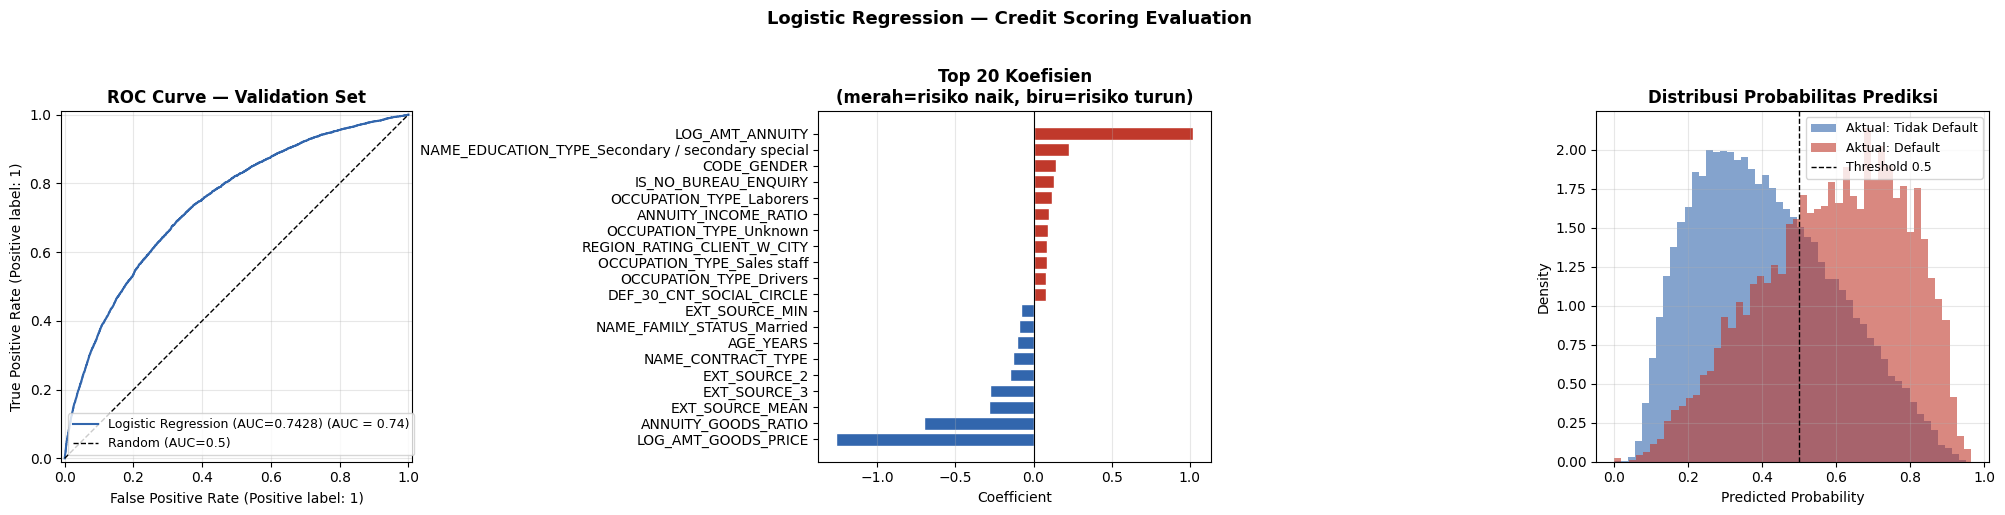

TUJUAN BISNIS: Jangan tolak klien yang mampu bayar
Total klien mampu bayar di val set : 56,538
Total klien default di val set     : 4,965
Overall default rate               : 8.07%

 Thresh |  Specificity |      FPR |  Salah Tolak (FP) |   Recall | Lolos Default (FN) |  Precision
------------------------------------------------------------------------------------------
   0.10 |       0.0131 |   98.69% |            55,796 |   0.9970 |                 15 |     0.0815
   0.15 |       0.0609 |   93.91% |            53,096 |   0.9889 |                 55 |     0.0846
   0.20 |       0.1351 |   86.49% |            48,897 |   0.9720 |                139 |     0.0898
   0.25 |       0.2263 |   77.37% |            43,742 |   0.9476 |                260 |     0.0971
   0.30 |       0.3253 |   67.47% |            38,144 |   0.9108 |                443 |     0.1060
   0.35 |       0.4236 |   57.64% |            32,587 |   0.8647 |                672 |     0.1164
   0.40 |       0.5167 |   48.33% 

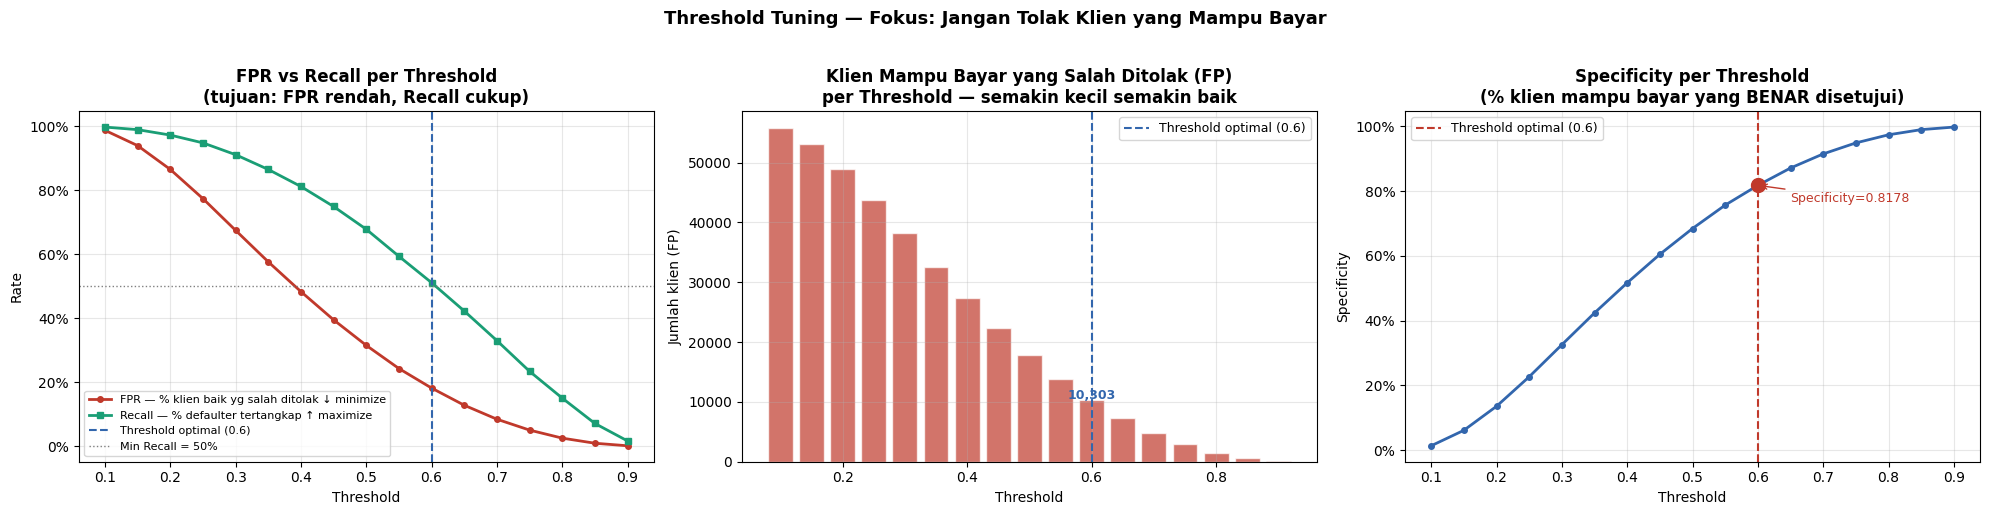


RINGKASAN KEPUTUSAN BISNIS
Model          : Logistic Regression
AUC-ROC        : 0.7428
Threshold      : 0.6

Dari 56,538 klien yang MAMPU BAYAR:
  → 46,235 (81.78%) BENAR disetujui ✅
  → 10,303 (18.22%) SALAH ditolak ❌

Dari 4,965 klien yang akan DEFAULT:
  → 2,538 (51.12%) BENAR ditolak ✅
  → 2,427 (48.88%) LOLOS disetujui ⚠️


In [ ]:
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (roc_auc_score, confusion_matrix,
                             precision_score, recall_score,
                             f1_score, accuracy_score,
                             RocCurveDisplay, classification_report)
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

TARGET_COL = 'TARGET'

# ============================================================
# STEP 1 — ENCODING KATEGORIK
# ============================================================
cat_cols       = df.select_dtypes('object').columns.tolist()
binary_cats    = [c for c in cat_cols if df[c].nunique() == 2]
nonbinary_cats = [c for c in cat_cols if df[c].nunique() > 2]

print(f'Kolom kategorik   : {len(cat_cols)}')
print(f'  Binary (LE)     : {binary_cats}')
print(f'  Non-binary (OHE): {nonbinary_cats}')

# Label Encoding untuk binary
le = LabelEncoder()
for col in binary_cats:
    df[col] = le.fit_transform(df[col].astype(str))

# One-Hot Encoding untuk non-binary
df = pd.get_dummies(df, columns=nonbinary_cats, drop_first=True)

# Konversi bool → float
bool_cols = df.select_dtypes('bool').columns
df[bool_cols] = df[bool_cols].astype(float)


# ============================================================
# STEP 2 — PISAH FITUR DAN TARGET
# ============================================================
X = df.drop(columns=[TARGET_COL])
y = df[TARGET_COL]

feature_cols = X.columns.tolist()
print(f'Jumlah fitur : {len(feature_cols)}')
print(f'Default rate : {y.mean():.4f} ({y.mean()*100:.2f}%)')

# ============================================================
# STEP 3 — TRAIN / VALIDATION SPLIT
# ============================================================
X_train, X_val, y_train, y_val = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'\nTrain : {X_train.shape[0]:,} baris | default rate: {y_train.mean():.4f}')
print(f'Val   : {X_val.shape[0]:,} baris | default rate: {y_val.mean():.4f}')

# ============================================================
# STEP 4 — SCALING
# ============================================================
scaler = StandardScaler()
X_train_scaled = pd.DataFrame(
    scaler.fit_transform(X_train),
    columns=feature_cols
)
X_val_scaled = pd.DataFrame(
    scaler.transform(X_val),
    columns=feature_cols
)

print('✓ StandardScaler selesai (fit di train, transform di val)')

# ============================================================
# STEP 5 — LOGISTIC REGRESSION
# ============================================================
print('\n' + '='*55)
print('LOGISTIC REGRESSION')
print('='*55)

lr = LogisticRegression(
    C=0.1,
    penalty='l2',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=42
)

lr.fit(X_train_scaled, y_train)

lr_prob_train = lr.predict_proba(X_train_scaled)[:, 1]
lr_prob_val   = lr.predict_proba(X_val_scaled)[:, 1]
lr_auc_train  = roc_auc_score(y_train, lr_prob_train)
lr_auc_val    = roc_auc_score(y_val,   lr_prob_val)

print(f'AUC Train : {lr_auc_train:.4f}')
print(f'AUC Val   : {lr_auc_val:.4f}')
print(f'Gap       : {lr_auc_train - lr_auc_val:.4f}')

# ============================================================
# STEP 6 — VISUALISASI
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── 6A. ROC Curve ───────────────────────────────────────────
RocCurveDisplay.from_predictions(
    y_val, lr_prob_val,
    name=f'Logistic Regression (AUC={lr_auc_val:.4f})',
    ax=axes[0], color='#3266ad'
)
axes[0].plot([0,1],[0,1], 'k--', linewidth=1, label='Random (AUC=0.5)')
axes[0].set_title('ROC Curve — Validation Set', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── 6B. Top 20 Koefisien ────────────────────────────────────
coef_df = pd.DataFrame({
    'feature': feature_cols,
    'coef'   : lr.coef_[0]
}).sort_values('coef', key=abs, ascending=False).head(20).sort_values('coef')

colors_coef = ['#C0392B' if c > 0 else '#3266ad' for c in coef_df['coef']]
axes[1].barh(coef_df['feature'], coef_df['coef'],
             color=colors_coef, edgecolor='white')
axes[1].axvline(0, color='black', linewidth=0.8)
axes[1].set_title('Top 20 Koefisien\n(merah=risiko naik, biru=risiko turun)',
                  fontweight='bold')
axes[1].set_xlabel('Coefficient')
axes[1].grid(axis='x', alpha=0.3)

# ── 6C. Distribusi Probabilitas Prediksi ────────────────────
axes[2].hist(lr_prob_val[y_val == 0], bins=50, alpha=0.6,
             color='#3266ad', label='Aktual: Tidak Default', density=True)
axes[2].hist(lr_prob_val[y_val == 1], bins=50, alpha=0.6,
             color='#C0392B', label='Aktual: Default', density=True)
axes[2].axvline(0.5, color='black', linestyle='--', linewidth=1, label='Threshold 0.5')
axes[2].set_title('Distribusi Probabilitas Prediksi', fontweight='bold')
axes[2].set_xlabel('Predicted Probability')
axes[2].set_ylabel('Density')
axes[2].legend(fontsize=9)
axes[2].grid(alpha=0.3)

plt.suptitle('Logistic Regression — Credit Scoring Evaluation',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 7 — THRESHOLD TUNING
# ============================================================
y_val_arr   = y_val.values
total_good  = (y_val_arr == 0).sum()   # klien mampu bayar
total_bad   = (y_val_arr == 1).sum()   # klien default

print('='*65)
print('TUJUAN BISNIS: Jangan tolak klien yang mampu bayar')
print('='*65)
print(f'Total klien mampu bayar di val set : {total_good:,}')
print(f'Total klien default di val set     : {total_bad:,}')
print(f'Overall default rate               : {y_val_arr.mean():.2%}')

print('\n' + '='*90)
print(f'{"Thresh":>7} | {"Specificity":>12} | {"FPR":>8} | {"Salah Tolak (FP)":>17} | {"Recall":>8} | {"Lolos Default (FN)":>18} | {"Precision":>10}')
print('-'*90)

results = []
for thresh in np.arange(0.10, 0.95, 0.05):
    y_pred = (lr_prob_val >= thresh).astype(int)
    cm     = confusion_matrix(y_val_arr, y_pred)

    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0  # % klien baik yg benar disetujui
    fpr         = fp / (tn + fp) if (tn + fp) > 0 else 0  # % klien baik yg salah ditolak
    recall      = tp / (tp + fn) if (tp + fn) > 0 else 0  # % defaulter yg tertangkap
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0  # akurasi keputusan tolak

    results.append({
        'threshold'  : round(thresh, 2),
        'specificity': specificity,
        'fpr'        : fpr,
        'fp'         : fp,   # klien baik yang salah ditolak
        'fn'         : fn,   # defaulter yang lolos
        'recall'     : recall,
        'precision'  : precision,
        'tn'         : tn,
        'tp'         : tp
    })

    print(f'{thresh:>7.2f} | {specificity:>12.4f} | {fpr:>8.2%} | '
          f'{fp:>17,} | {recall:>8.4f} | {fn:>18,} | {precision:>10.4f}')

results_df = pd.DataFrame(results)

# ============================================================
# PILIH THRESHOLD OPTIMAL
# ============================================================
# Strategi: cari threshold dengan FPR paling rendah (klien baik paling sedikit ditolak)
#           DENGAN syarat Recall masih >= 0.50 (bank tetap terlindungi minimal 50%)

MIN_RECALL = 0.50
filtered   = results_df[results_df['recall'] >= MIN_RECALL]

if len(filtered) > 0:
    best_row  = filtered.loc[filtered['fpr'].idxmin()]
else:
    best_row  = results_df.loc[results_df['fpr'].idxmin()]

BEST_THRESH = best_row['threshold']

print(f'\n{"="*65}')
print(f'THRESHOLD OPTIMAL: {BEST_THRESH}')
print(f'  Syarat minimum Recall  : {MIN_RECALL:.0%}')
print(f'  Specificity            : {best_row["specificity"]:.4f}')
print(f'  FPR (salah tolak)      : {best_row["fpr"]:.2%}')
print(f'  Recall (tangkap default): {best_row["recall"]:.4f}')
print(f'  Precision              : {best_row["precision"]:.4f}')
print(f'{"="*65}')

# ============================================================
# CONFUSION MATRIX FINAL
# ============================================================
y_pred_final = (lr_prob_val >= BEST_THRESH).astype(int)
cm_final     = confusion_matrix(y_val_arr, y_pred_final)
tn, fp, fn, tp = cm_final[0,0], cm_final[0,1], cm_final[1,0], cm_final[1,1]

print(f'\nConfusion Matrix (threshold={BEST_THRESH}):')
print(f'\n  {"" :25} | {"Pred: Disetujui":>15} | {"Pred: Ditolak":>15}')
print(f'  {"-"*60}')
print(f'  {"Aktual: Mampu Bayar":25} | {tn:>15,} | {fp:>15,}')
print(f'  {"Aktual: Default":25} | {fn:>15,} | {tp:>15,}')
print(f'\n  ✅ Klien mampu bayar BENAR disetujui    : {tn:,} ({tn/total_good:.2%})')
print(f'  ❌ Klien mampu bayar SALAH ditolak (FP) : {fp:,} ({fp/total_good:.2%})')
print(f'  ✅ Klien default BENAR ditolak           : {tp:,} ({tp/total_bad:.2%})')
print(f'  ⚠️  Klien default LOLOS disetujui (FN)   : {fn:,} ({fn/total_bad:.2%})')

print('\nClassification Report:')
print(classification_report(y_val, y_pred_final,
                            target_names=['Tidak Default', 'Default']))

# ============================================================
# VISUALISASI
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── 1. FPR & Recall vs Threshold ────────────────────────────
ax = axes[0]
ax.plot(results_df['threshold'], results_df['fpr'],
        color='#C0392B', linewidth=2, marker='o', markersize=4,
        label='FPR — % klien baik yg salah ditolak ↓ minimize')
ax.plot(results_df['threshold'], results_df['recall'],
        color='#1a9e75', linewidth=2, marker='s', markersize=4,
        label='Recall — % defaulter tertangkap ↑ maximize')
ax.axvline(BEST_THRESH, color='#3266ad', linestyle='--',
           linewidth=1.5, label=f'Threshold optimal ({BEST_THRESH})')
ax.axhline(MIN_RECALL, color='gray', linestyle=':', linewidth=1,
           label=f'Min Recall = {MIN_RECALL:.0%}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Rate')
ax.set_title('FPR vs Recall per Threshold\n(tujuan: FPR rendah, Recall cukup)',
             fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# ── 2. Jumlah Klien Baik Salah Ditolak (FP) ─────────────────
ax = axes[1]
ax.bar(results_df['threshold'], results_df['fp'],
       color='#C0392B', alpha=0.7, edgecolor='white', width=0.04)
ax.axvline(BEST_THRESH, color='#3266ad', linestyle='--',
           linewidth=1.5, label=f'Threshold optimal ({BEST_THRESH})')
ax.set_xlabel('Threshold')
ax.set_ylabel('Jumlah klien (FP)')
ax.set_title('Klien Mampu Bayar yang Salah Ditolak (FP)\nper Threshold — semakin kecil semakin baik',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
for bar, val in zip(ax.patches, results_df['fp']):
    if abs(bar.get_x() + bar.get_width()/2 - BEST_THRESH) < 0.03:
        ax.text(bar.get_x() + bar.get_width()/2,
                bar.get_height() + 200,
                f'{int(val):,}', ha='center', fontsize=9,
                fontweight='bold', color='#3266ad')

# ── 3. Specificity vs Threshold ──────────────────────────────
ax = axes[2]
ax.plot(results_df['threshold'], results_df['specificity'],
        color='#3266ad', linewidth=2, marker='o', markersize=4)
ax.axvline(BEST_THRESH, color='#C0392B', linestyle='--',
           linewidth=1.5, label=f'Threshold optimal ({BEST_THRESH})')
best_spec = best_row['specificity']
ax.scatter([BEST_THRESH], [best_spec], color='#C0392B', s=100, zorder=5)
ax.annotate(f'Specificity={best_spec:.4f}',
            xy=(BEST_THRESH, best_spec),
            xytext=(BEST_THRESH + 0.05, best_spec - 0.05),
            fontsize=9, color='#C0392B',
            arrowprops=dict(arrowstyle='->', color='#C0392B'))
ax.set_xlabel('Threshold')
ax.set_ylabel('Specificity')
ax.set_title('Specificity per Threshold\n(% klien mampu bayar yang BENAR disetujui)',
             fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Threshold Tuning — Fokus: Jangan Tolak Klien yang Mampu Bayar',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# RINGKASAN KEPUTUSAN BISNIS
# ============================================================
print('\n' + '='*65)
print('RINGKASAN KEPUTUSAN BISNIS')
print('='*65)
print(f'Model          : Logistic Regression')
print(f'AUC-ROC        : {roc_auc_score(y_val_arr, lr_prob_val):.4f}')
print(f'Threshold      : {BEST_THRESH}')
print(f'')
print(f'Dari {total_good:,} klien yang MAMPU BAYAR:')
print(f'  → {tn:,} ({tn/total_good:.2%}) BENAR disetujui ✅')
print(f'  → {fp:,} ({fp/total_good:.2%}) SALAH ditolak ❌')
print(f'')
print(f'Dari {total_bad:,} klien yang akan DEFAULT:')
print(f'  → {tp:,} ({tp/total_bad:.2%}) BENAR ditolak ✅')
print(f'  → {fn:,} ({fn/total_bad:.2%}) LOLOS disetujui ⚠️')


STEP 1 — CROSS VALIDATION BASELINE (5-Fold Stratified)
Menggunakan: X_train_scaled & y_train
Val set tetap terpisah untuk evaluasi final

AUC per fold:
  Fold 1: 0.7391  █████████████████████████████
  Fold 2: 0.7390  █████████████████████████████
  Fold 3: 0.7450  █████████████████████████████
  Fold 4: 0.7374  █████████████████████████████
  Fold 5: 0.7396  █████████████████████████████

Rata-rata AUC  : 0.7400
Std deviasi    : 0.0026
Min            : 0.7374
Max            : 0.7450
Range (max-min): 0.0076

✅ Model SANGAT STABIL — std < 0.005, aman untuk di-tuning

Baseline val AUC sebelumnya : 0.7428
Baseline CV AUC sekarang    : 0.7400
Selisih                     : 0.0028

STEP 2 — HYPERPARAMETER TUNING (GridSearchCV + 5-Fold CV)
Parameter grid:
  C: [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0]
  penalty: ['l2']
  solver: ['lbfgs']

Total kombinasi: 8 kombinasi × 5 fold
Harap tunggu...

Hasil semua kombinasi (sorted by Val AUC):
       C |  Penalty |  Train AUC |    Val AUC |     S

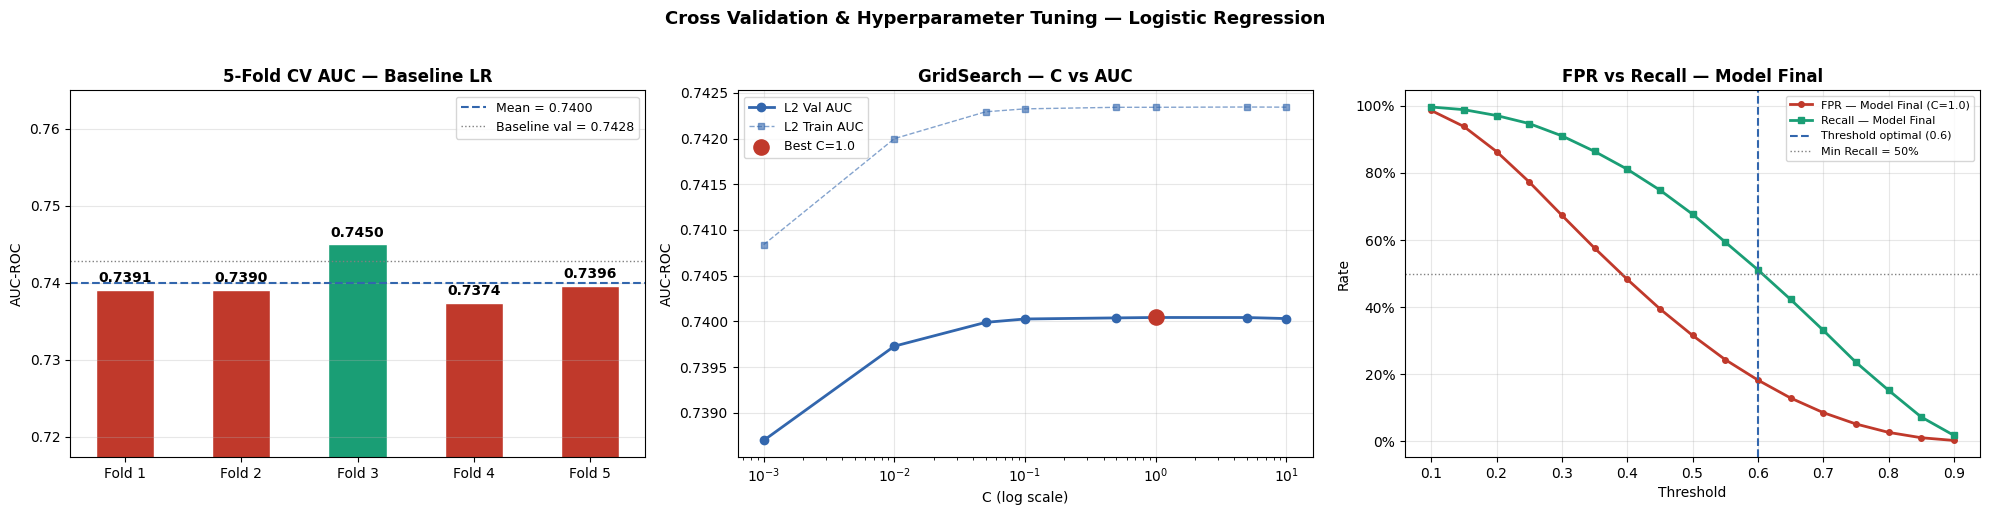


RINGKASAN FINAL — LOGISTIC REGRESSION
Parameter      : C=1.0, penalty=l2, class_weight=balanced
CV AUC         : 0.7400 ± 0.0026
Val AUC        : 0.7428
Threshold      : 0.6

Dari 56,538 klien MAMPU BAYAR:
  → 46,228 (81.76%) BENAR disetujui ✅
  → 10,310 (18.24%) SALAH ditolak  ❌

Dari 4,965 klien DEFAULT:
  → 2,538 (51.12%) BENAR ditolak   ✅
  → 2,427 (48.88%) LOLOS disetujui ⚠️


In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score, GridSearchCV

CV_FOLDS   = 5
RANDOM     = 42

# ============================================================
# STEP 1 — CROSS VALIDATION BASELINE
# ============================================================
# Tujuan: konfirmasi AUC 0.7428 stabil, bukan kebetulan 1 split
# Gunakan data TRAIN saja (X_train_scaled, y_train)
# Val set tetap disimpan untuk evaluasi final — tidak boleh masuk CV

print('='*60)
print('STEP 1 — CROSS VALIDATION BASELINE (5-Fold Stratified)')
print('='*60)
print('Menggunakan: X_train_scaled & y_train')
print('Val set tetap terpisah untuk evaluasi final\n')

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM)

lr_baseline = LogisticRegression(
    C=0.1,
    penalty='l2',
    class_weight='balanced',
    solver='lbfgs',
    max_iter=1000,
    random_state=RANDOM
)

cv_scores = cross_val_score(
    lr_baseline,
    X_train_scaled, y_train,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1
)

print(f'AUC per fold:')
for i, score in enumerate(cv_scores, 1):
    bar = '█' * int(score * 40)
    print(f'  Fold {i}: {score:.4f}  {bar}')

print(f'\nRata-rata AUC  : {cv_scores.mean():.4f}')
print(f'Std deviasi    : {cv_scores.std():.4f}')
print(f'Min            : {cv_scores.min():.4f}')
print(f'Max            : {cv_scores.max():.4f}')
print(f'Range (max-min): {cv_scores.max() - cv_scores.min():.4f}')

# Interpretasi stabilitas
if cv_scores.std() < 0.005:
    print('\n✅ Model SANGAT STABIL — std < 0.005, aman untuk di-tuning')
elif cv_scores.std() < 0.01:
    print('\n✅ Model STABIL — std < 0.01, aman untuk di-tuning')
else:
    print('\n⚠️  Model KURANG STABIL — std > 0.01, perlu investigasi lebih lanjut')

print(f'\nBaseline val AUC sebelumnya : 0.7428')
print(f'Baseline CV AUC sekarang    : {cv_scores.mean():.4f}')
print(f'Selisih                     : {abs(cv_scores.mean() - 0.7428):.4f}')

# ============================================================
# STEP 2 — HYPERPARAMETER TUNING (GridSearchCV)
# ============================================================
# Parameter yang di-tuning:
#   C       → kekuatan regularisasi (kecil=ketat, besar=longgar)
#   penalty → L1 (sparse) vs L2 (Ridge)
#   solver  → harus kompatibel dengan penalty

print('\n' + '='*60)
print('STEP 2 — HYPERPARAMETER TUNING (GridSearchCV + 5-Fold CV)')
print('='*60)

param_grid = {
    'C'      : [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 5.0, 10.0],
    'penalty': ['l2'],
    'solver' : ['lbfgs'],
}

print('Parameter grid:')
for k, v in param_grid.items():
    print(f'  {k}: {v}')
print(f'\nTotal kombinasi: {len(param_grid["C"]) * len(param_grid["penalty"])} kombinasi × {CV_FOLDS} fold')
print('Harap tunggu...\n')

grid_search = GridSearchCV(
    estimator=LogisticRegression(
        class_weight='balanced',
        max_iter=1000,
        random_state=RANDOM
    ),
    param_grid=param_grid,
    cv=skf,
    scoring='roc_auc',
    n_jobs=-1,
    verbose=0,
    return_train_score=True
)

grid_search.fit(X_train_scaled, y_train)

# Hasil semua kombinasi
cv_results = pd.DataFrame(grid_search.cv_results_)
cv_results = cv_results[['param_C', 'param_penalty',
                          'mean_train_score', 'std_train_score',
                          'mean_test_score', 'std_test_score',
                          'rank_test_score']].sort_values('mean_test_score', ascending=False)

print('Hasil semua kombinasi (sorted by Val AUC):')
print(f'{"C":>8} | {"Penalty":>8} | {"Train AUC":>10} | {"Val AUC":>10} | {"Std":>7} | {"Gap":>8}')
print('-'*60)
for _, row in cv_results.iterrows():
    gap = row['mean_train_score'] - row['mean_test_score']
    print(f'{row["param_C"]:>8} | {str(row["param_penalty"]):>8} | '
          f'{row["mean_train_score"]:>10.4f} | {row["mean_test_score"]:>10.4f} | '
          f'{row["std_test_score"]:>7.4f} | {gap:>8.4f}')

best_params = grid_search.best_params_
best_auc    = grid_search.best_score_

print(f'\n✅ Parameter terbaik : {best_params}')
print(f'✅ Best CV AUC       : {best_auc:.4f}')
print(f'   Baseline CV AUC  : {cv_scores.mean():.4f}')
print(f'   Peningkatan      : +{best_auc - cv_scores.mean():.4f}')

# ============================================================
# STEP 3 — RETRAIN MODEL FINAL
# ============================================================
print('\n' + '='*60)
print('STEP 3 — RETRAIN MODEL FINAL dengan Parameter Terbaik')
print('='*60)

lr_final = LogisticRegression(
    **best_params,
    class_weight='balanced',
    max_iter=1000,
    random_state=RANDOM
)

lr_final.fit(X_train_scaled, y_train)

# Evaluasi di val set
lr_final_prob_val   = lr_final.predict_proba(X_val_scaled)[:, 1]
lr_final_prob_train = lr_final.predict_proba(X_train_scaled)[:, 1]
lr_final_auc_train  = roc_auc_score(y_train, lr_final_prob_train)
lr_final_auc_val    = roc_auc_score(y_val,   lr_final_prob_val)

print(f'AUC Train : {lr_final_auc_train:.4f}  (sebelumnya: 0.7421)')
print(f'AUC Val   : {lr_final_auc_val:.4f}  (sebelumnya: 0.7428)')
print(f'Gap       : {lr_final_auc_train - lr_final_auc_val:.4f}')

# ============================================================
# STEP 4 — THRESHOLD TUNING ULANG (model final)
# ============================================================
print('\n' + '='*60)
print('STEP 4 — THRESHOLD TUNING ULANG (model final)')
print('Fokus bisnis: minimize FPR, syarat Recall >= 50%')
print('='*60)

total_good = (y_val == 0).sum()
total_bad  = (y_val == 1).sum()
MIN_RECALL = 0.50

results = []
print(f'\n{"Thresh":>7} | {"Specificity":>12} | {"FPR":>8} | '
      f'{"Salah Tolak (FP)":>17} | {"Recall":>8} | {"Lolos Default (FN)":>18}')
print('-'*85)

for thresh in np.arange(0.10, 0.95, 0.05):
    y_pred = (lr_final_prob_val >= thresh).astype(int)
    cm     = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
    spec   = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr    = fp / (tn + fp) if (tn + fp) > 0 else 0
    rec    = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec   = tp / (tp + fp) if (tp + fp) > 0 else 0
    results.append({'threshold': round(thresh, 2), 'specificity': spec,
                    'fpr': fpr, 'fp': fp, 'fn': fn, 'recall': rec,
                    'precision': prec, 'tn': tn, 'tp': tp})
    print(f'{thresh:>7.2f} | {spec:>12.4f} | {fpr:>8.2%} | '
          f'{fp:>17,} | {rec:>8.4f} | {fn:>18,}')

results_df  = pd.DataFrame(results)
filtered    = results_df[results_df['recall'] >= MIN_RECALL]
best_row    = filtered.loc[filtered['fpr'].idxmin()] if len(filtered) > 0 \
              else results_df.loc[results_df['fpr'].idxmin()]
BEST_THRESH = best_row['threshold']

print(f'\n✅ Threshold optimal: {BEST_THRESH}')
print(f'   Specificity      : {best_row["specificity"]:.4f}')
print(f'   FPR              : {best_row["fpr"]:.2%}')
print(f'   Recall           : {best_row["recall"]:.4f}')

# ============================================================
# STEP 5 — VISUALISASI PERBANDINGAN
# ============================================================
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# 1. CV Scores per fold
ax = axes[0]
folds  = [f'Fold {i}' for i in range(1, CV_FOLDS+1)]
colors = ['#1a9e75' if s >= cv_scores.mean() else '#C0392B' for s in cv_scores]
bars   = ax.bar(folds, cv_scores, color=colors, edgecolor='white', width=0.5)
ax.axhline(cv_scores.mean(), color='#3266ad', linestyle='--',
           linewidth=1.5, label=f'Mean = {cv_scores.mean():.4f}')
ax.axhline(0.7428, color='gray', linestyle=':', linewidth=1,
           label='Baseline val = 0.7428')
for bar, val in zip(bars, cv_scores):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
            f'{val:.4f}', ha='center', fontsize=10, fontweight='bold')
ax.set_ylim(min(cv_scores) - 0.02, max(cv_scores) + 0.02)
ax.set_title('5-Fold CV AUC — Baseline LR', fontweight='bold')
ax.set_ylabel('AUC-ROC')
ax.legend(fontsize=9)
ax.grid(axis='y', alpha=0.3)

# 2. GridSearch — C vs AUC
ax = axes[1]
l2_results = cv_results[cv_results['param_penalty'] == 'l2'].sort_values('param_C')
ax.plot(l2_results['param_C'].astype(float),
        l2_results['mean_test_score'],
        color='#3266ad', linewidth=2, marker='o', markersize=6, label='L2 Val AUC')
ax.plot(l2_results['param_C'].astype(float),
        l2_results['mean_train_score'],
        color='#3266ad', linewidth=1, linestyle='--',
        marker='s', markersize=5, alpha=0.6, label='L2 Train AUC')
best_c = best_params['C']
best_y = l2_results[l2_results['param_C'] == best_c]['mean_test_score'].values[0]
ax.scatter([best_c], [best_y], color='#C0392B', s=120, zorder=5,
           label=f'Best C={best_c}')
ax.set_xscale('log')
ax.set_xlabel('C (log scale)')
ax.set_ylabel('AUC-ROC')
ax.set_title('GridSearch — C vs AUC', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

# 3. FPR & Recall — model final vs baseline
ax = axes[2]
ax.plot(results_df['threshold'], results_df['fpr'],
        color='#C0392B', linewidth=2, marker='o', markersize=4,
        label=f'FPR — Model Final (C={best_c})')
ax.plot(results_df['threshold'], results_df['recall'],
        color='#1a9e75', linewidth=2, marker='s', markersize=4,
        label='Recall — Model Final')
ax.axvline(BEST_THRESH, color='#3266ad', linestyle='--',
           linewidth=1.5, label=f'Threshold optimal ({BEST_THRESH})')
ax.axhline(MIN_RECALL, color='gray', linestyle=':', linewidth=1,
           label=f'Min Recall = {MIN_RECALL:.0%}')
ax.set_xlabel('Threshold')
ax.set_ylabel('Rate')
ax.set_title('FPR vs Recall — Model Final', fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

plt.suptitle('Cross Validation & Hyperparameter Tuning — Logistic Regression',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# RINGKASAN FINAL
# ============================================================
y_pred_final = (lr_final_prob_val >= BEST_THRESH).astype(int)
cm_final     = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp = cm_final[0,0], cm_final[0,1], cm_final[1,0], cm_final[1,1]

print('\n' + '='*60)
print('RINGKASAN FINAL — LOGISTIC REGRESSION')
print('='*60)
print(f'Parameter      : C={best_c}, penalty=l2, class_weight=balanced')
print(f'CV AUC         : {best_auc:.4f} ± {grid_search.cv_results_["std_test_score"][grid_search.best_index_]:.4f}')
print(f'Val AUC        : {lr_final_auc_val:.4f}')
print(f'Threshold      : {BEST_THRESH}')
print()
print(f'Dari {total_good:,} klien MAMPU BAYAR:')
print(f'  → {tn:,} ({tn/total_good:.2%}) BENAR disetujui ✅')
print(f'  → {fp:,} ({fp/total_good:.2%}) SALAH ditolak  ❌')
print()
print(f'Dari {total_bad:,} klien DEFAULT:')
print(f'  → {tp:,} ({tp/total_bad:.2%}) BENAR ditolak   ✅')
print(f'  → {fn:,} ({fn/total_bad:.2%}) LOLOS disetujui ⚠️')

# Simpan model final untuk dipakai di prediksi test
import joblib
# joblib.dump(lr_final, PATH + 'lr_final.pkl')
# joblib.dump(scaler,   PATH + 'scaler.pkl')
# print('\nModel disimpan ke Google Drive ✅')

In [ ]:
!pip install optuna

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 8.4 MB/s eta 0:00:00


In [ ]:
# Jalankan cell debug ini dulu untuk cari kolom bermasalah
import json

problematic_cols = []
for col in X_train.columns:
    try:
        json.dumps(col)
    except (ValueError, TypeError):
        problematic_cols.append(col)

# Cek juga karakter non-ASCII dan karakter spesial lainnya
import re
suspicious = [c for c in X_train.columns
              if re.search(r'[^\w]', c)]

print(f'Kolom gagal JSON encode: {problematic_cols}')
print(f'\nKolom dengan karakter non-alfanumerik ({len(suspicious)}):')
for c in suspicious[:20]:
    chars = [ch for ch in c if re.search(r'[^\w]', ch)]
    print(f'  {c}  →  karakter: {set(chars)}')

Kolom gagal JSON encode: []

Kolom dengan karakter non-alfanumerik (56):
  NAME_INCOME_TYPE_Commercial associate  →  karakter: {' '}
  NAME_INCOME_TYPE_Maternity leave  →  karakter: {' '}
  NAME_INCOME_TYPE_State servant  →  karakter: {' '}
  NAME_EDUCATION_TYPE_Higher education  →  karakter: {' '}
  NAME_EDUCATION_TYPE_Incomplete higher  →  karakter: {' '}
  NAME_EDUCATION_TYPE_Lower secondary  →  karakter: {' '}
  NAME_EDUCATION_TYPE_Secondary / secondary special  →  karakter: {'/', ' '}
  NAME_FAMILY_STATUS_Single / not married  →  karakter: {'/', ' '}
  NAME_HOUSING_TYPE_House / apartment  →  karakter: {'/', ' '}
  NAME_HOUSING_TYPE_Municipal apartment  →  karakter: {' '}
  NAME_HOUSING_TYPE_Office apartment  →  karakter: {' '}
  NAME_HOUSING_TYPE_Rented apartment  →  karakter: {' '}
  NAME_HOUSING_TYPE_With parents  →  karakter: {' '}
  OCCUPATION_TYPE_Cleaning staff  →  karakter: {' '}
  OCCUPATION_TYPE_Cooking staff  →  karakter: {' '}
  OCCUPATION_TYPE_Core staff  →  karakter: 

✅ Nama kolom bersih — 128 fitur siap

STEP 1 — BASELINE LIGHTGBM + 5-FOLD CV
AUC per fold:
  Fold 1: 0.7434  █████████████████████████████
  Fold 2: 0.7465  █████████████████████████████
  Fold 3: 0.7478  █████████████████████████████
  Fold 4: 0.7459  █████████████████████████████
  Fold 5: 0.7482  █████████████████████████████

Rata-rata AUC : 0.7464
Std deviasi   : 0.0017
✅ Model SANGAT STABIL
[100]	valid_0's binary_logloss: 0.583281
[200]	valid_0's binary_logloss: 0.572116
[300]	valid_0's binary_logloss: 0.564295
[400]	valid_0's binary_logloss: 0.556806
[500]	valid_0's binary_logloss: 0.550163

Baseline Val AUC : 0.7527
LR Val AUC       : 0.7428  (pembanding)

STEP 2 — HYPERPARAMETER TUNING (Optuna, 30 trials)
Menggunakan 5-Fold CV di dalam setiap trial


  0%|          | 0/30 [00:00<?, ?it/s]


✅ Best CV AUC    : 0.7496
   Baseline CV AUC: 0.7464
   Peningkatan    : +0.0032

Parameter terbaik:
  n_estimators          : 302
  learning_rate         : 0.02929000481679277
  num_leaves            : 33
  max_depth             : 13
  min_child_samples     : 41
  subsample             : 0.9100008563888559
  colsample_bytree      : 0.7817067367374476
  reg_alpha             : 0.08410734272644305
  reg_lambda            : 0.03893329714803651

STEP 3 — RETRAIN MODEL FINAL dengan Parameter Terbaik
[100]	valid_0's binary_logloss: 0.592848
[200]	valid_0's binary_logloss: 0.580193
[300]	valid_0's binary_logloss: 0.573432
AUC Train : 0.7832
AUC Val   : 0.7538
Gap       : 0.0294

Perbandingan model:
  Logistic Regression : 0.7428
  LightGBM (baseline) : 0.7527
  LightGBM (tuned)    : 0.7538

STEP 4 — THRESHOLD TUNING
Tujuan bisnis: minimize FPR, syarat Recall >= 50%

Total klien mampu bayar : 56,538
Total klien default     : 4,965
Overall default rate    : 8.07%

 Thresh |  Specificity |    

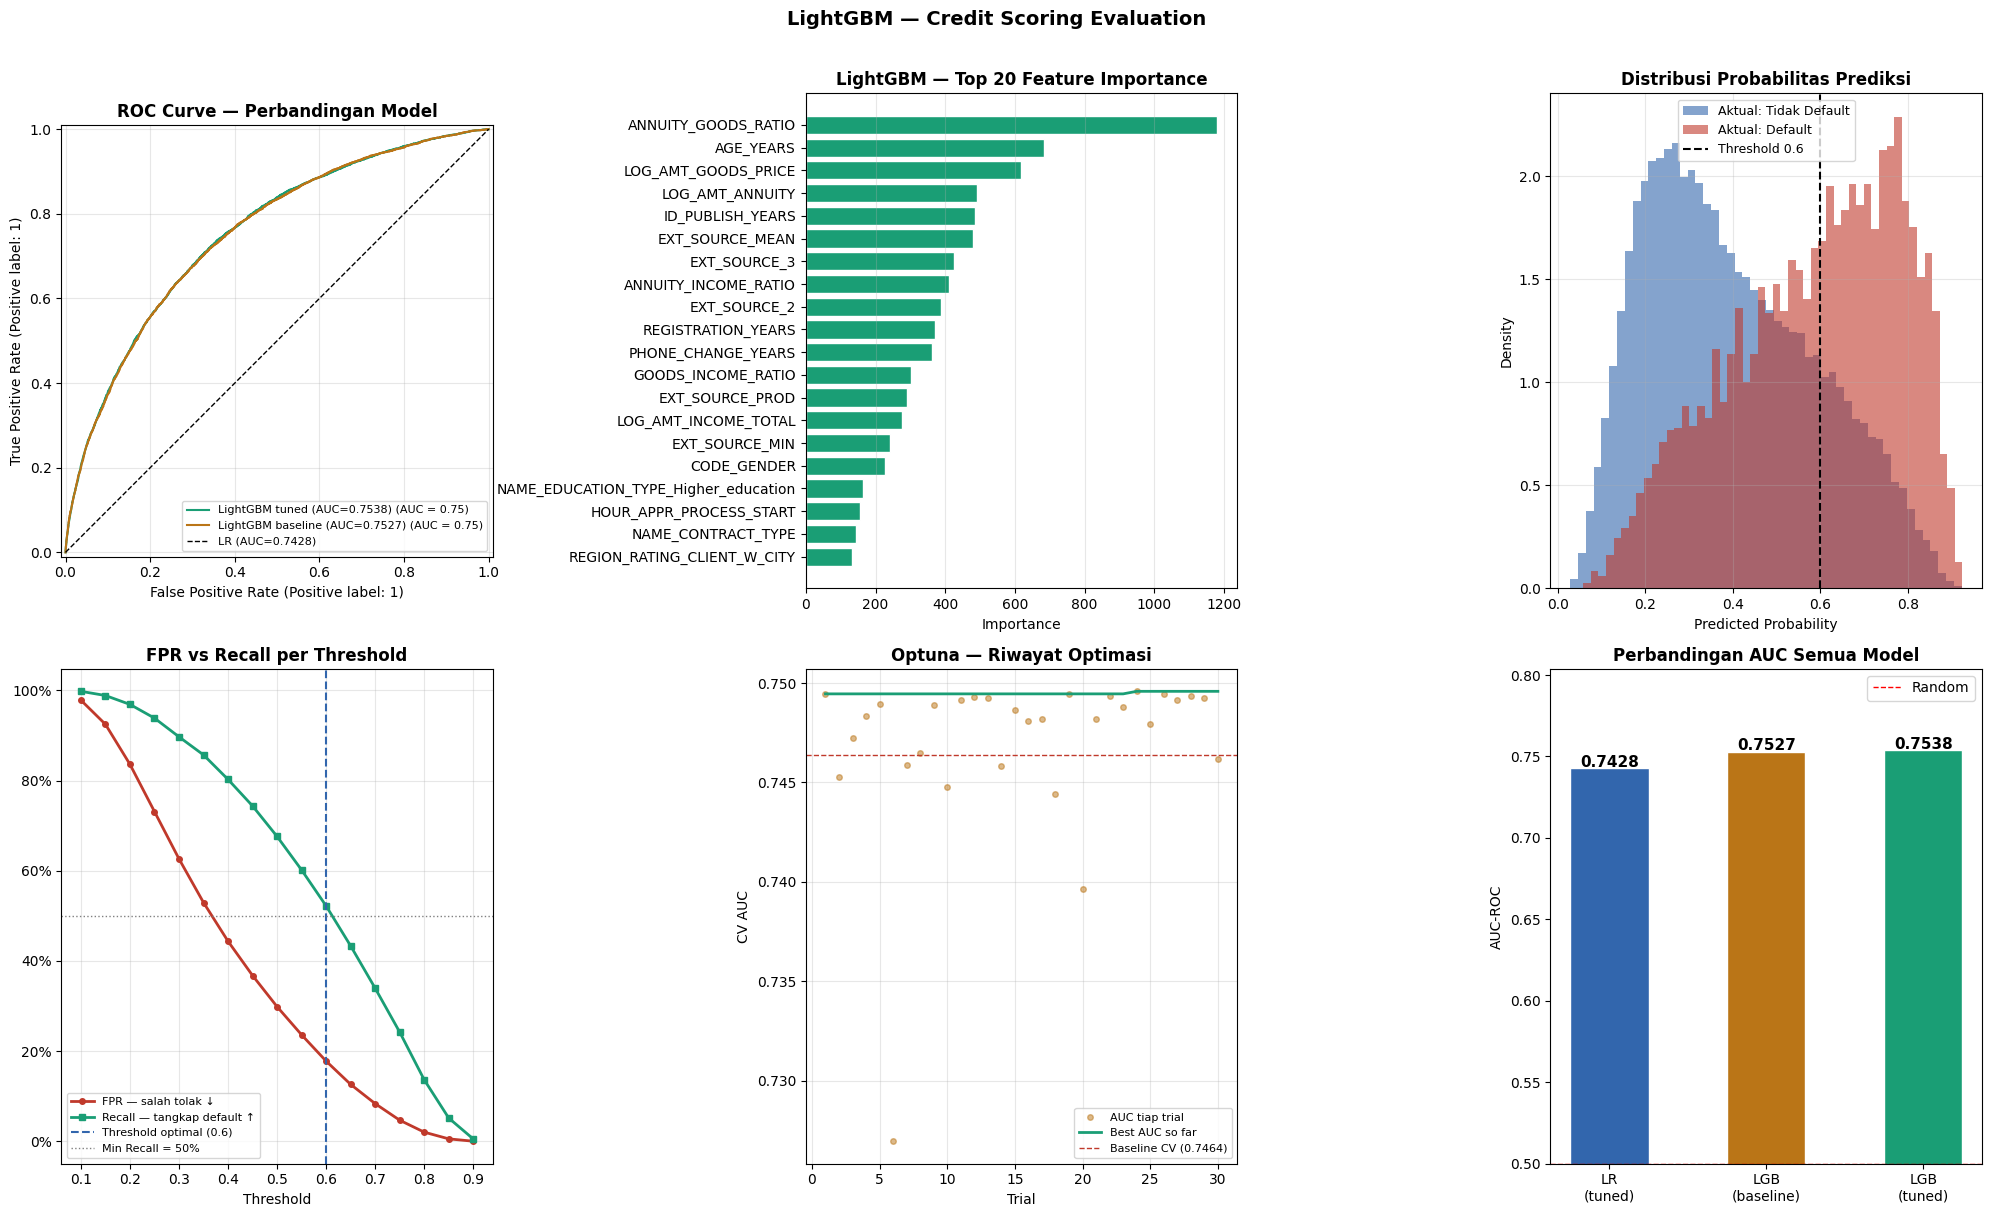


RINGKASAN FINAL — LIGHTGBM

--- Parameter Terbaik ---
  n_estimators          : 302
  learning_rate         : 0.029290
  num_leaves            : 33
  max_depth             : 13
  min_child_samples     : 41
  subsample             : 0.910001
  colsample_bytree      : 0.781707
  reg_alpha             : 0.084107
  reg_lambda            : 0.038933

--- Performa Model ---
  CV AUC (5-fold)    : 0.7496 ± 0.0043
  Val AUC            : 0.7538
  Gap train-val      : 0.0294
  vs LR (0.7428)     : +0.0110

--- Threshold & Keputusan Bisnis ---
  Threshold optimal  : 0.6
  Syarat min Recall  : 50%
  Specificity        : 0.8222
  FPR                : 17.78%
  Recall             : 0.5219
  Precision          : 0.2049

--- Hasil pada Val Set (61,503 klien) ---
  Dari 56,538 klien MAMPU BAYAR:
    → 46,483 (82.22%) BENAR disetujui ✅
    → 10,055 (17.78%) SALAH ditolak  ❌
  Dari 4,965 klien DEFAULT:
    → 2,591 (52.19%) BENAR ditolak   ✅
    → 2,374 (47.81%) LOLOS disetujui ⚠️


In [ ]:
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings('ignore')
optuna.logging.set_verbosity(optuna.logging.WARNING)

TARGET_COL = 'TARGET'
RANDOM     = 42
CV_FOLDS   = 5
MIN_RECALL = 0.50   # syarat bisnis: bank tetap terlindungi minimal 50%

skf = StratifiedKFold(n_splits=CV_FOLDS, shuffle=True, random_state=RANDOM)

def clean_col_names(cols):
    return (pd.Index(cols)
        .str.replace('[', '', regex=False)
        .str.replace(']', '', regex=False)
        .str.replace('<', '', regex=False)
        .str.replace('>', '', regex=False)
        .str.replace(',', '', regex=False)
        .str.replace(' ', '_', regex=False)
        .str.replace('/', '_', regex=False)
        .str.replace(':', '', regex=False)
        .str.replace('-', '', regex=False)
        .tolist()
    )

X_train_scaled.columns = feature_cols
X_val_scaled.columns   = feature_cols

X_train.columns = clean_col_names(X_train.columns)
X_val.columns   = clean_col_names(X_val.columns)
feature_cols    = X_train.columns.tolist()

# Verifikasi tidak ada karakter bermasalah
problematic = [c for c in feature_cols
               if any(ch in c for ch in ['[',']','<','>',',',' '])]
if problematic:
    print(f'⚠️  Masih ada kolom bermasalah: {problematic[:5]}')
else:
    print(f'✅ Nama kolom bersih — {len(feature_cols)} fitur siap')

# ============================================================
# STEP 1 — BASELINE LIGHTGBM + CROSS VALIDATION
# ============================================================
print('\n' + '='*60)
print('STEP 1 — BASELINE LIGHTGBM + 5-FOLD CV')
print('='*60)

lgb_baseline = lgb.LGBMClassifier(
    n_estimators      = 500,
    learning_rate     = 0.05,
    num_leaves        = 31,
    max_depth         = -1,
    min_child_samples = 20,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    class_weight  = 'balanced',
    random_state      = RANDOM,
    n_jobs            = -1,
    verbose           = -1
)

cv_scores = cross_val_score(
    lgb_baseline, X_train, y_train,
    cv=skf, scoring='roc_auc', n_jobs=-1
)

print('AUC per fold:')
for i, s in enumerate(cv_scores, 1):
    bar = '█' * int(s * 40)
    print(f'  Fold {i}: {s:.4f}  {bar}')
print(f'\nRata-rata AUC : {cv_scores.mean():.4f}')
print(f'Std deviasi   : {cv_scores.std():.4f}')
if cv_scores.std() < 0.005:
    print('✅ Model SANGAT STABIL')
elif cv_scores.std() < 0.01:
    print('✅ Model STABIL')
else:
    print('⚠️  Model KURANG STABIL')

# Fit baseline di full train untuk cek val AUC
lgb_baseline.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
baseline_prob_val = lgb_baseline.predict_proba(X_val)[:, 1]
baseline_auc_val  = roc_auc_score(y_val, baseline_prob_val)
print(f'\nBaseline Val AUC : {baseline_auc_val:.4f}')
print(f'LR Val AUC       : 0.7428  (pembanding)')

# ============================================================
# STEP 2 — HYPERPARAMETER TUNING DENGAN OPTUNA
# ============================================================
print('\n' + '='*60)
print('STEP 2 — HYPERPARAMETER TUNING (Optuna, 30 trials)')
print('Menggunakan 5-Fold CV di dalam setiap trial')
print('='*60)

def objective(trial):
    params = {
        'n_estimators'    : trial.suggest_int('n_estimators', 100, 500),
        'learning_rate'   : trial.suggest_float('learning_rate', 0.01, 0.15, log=True),
        'num_leaves'      : trial.suggest_int('num_leaves', 20, 80),
        'max_depth'       : trial.suggest_int('max_depth', 4, 20),
        'min_child_samples': trial.suggest_int('min_child_samples', 10, 50),
        'subsample'       : trial.suggest_float('subsample', 0.7, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.7, 1.0),
        'reg_alpha'       : trial.suggest_float('reg_alpha', 0.01, 0.5, log=True),
        'reg_lambda'      : trial.suggest_float('reg_lambda', 0.01, 0.5, log=True),
    }
    model = lgb.LGBMClassifier(
        **params,
        class_weight = 'balanced',
        random_state     = RANDOM,
        n_jobs           = -1,
        verbose          = -1
    )
    scores = cross_val_score(
        model, X_train, y_train,
        cv=skf, scoring='roc_auc', n_jobs=-1
    )
    return scores.mean()

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=30, show_progress_bar=True)

best_params = study.best_params
best_cv_auc = study.best_value

print(f'\n✅ Best CV AUC    : {best_cv_auc:.4f}')
print(f'   Baseline CV AUC: {cv_scores.mean():.4f}')
print(f'   Peningkatan    : +{best_cv_auc - cv_scores.mean():.4f}')
print(f'\nParameter terbaik:')
for k, v in best_params.items():
    print(f'  {k:<22}: {v}')

# ============================================================
# STEP 3 — RETRAIN MODEL FINAL
# ============================================================
print('\n' + '='*60)
print('STEP 3 — RETRAIN MODEL FINAL dengan Parameter Terbaik')
print('='*60)

lgb_final = lgb.LGBMClassifier(
    **best_params,
    class_weight = 'balanced',
    random_state     = RANDOM,
    n_jobs           = -1,
    verbose          = -1
)

lgb_final.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)

lgb_prob_train = lgb_final.predict_proba(X_train)[:, 1]
lgb_prob_val   = lgb_final.predict_proba(X_val)[:, 1]
lgb_auc_train  = roc_auc_score(y_train, lgb_prob_train)
lgb_auc_val    = roc_auc_score(y_val,   lgb_prob_val)

print(f'AUC Train : {lgb_auc_train:.4f}')
print(f'AUC Val   : {lgb_auc_val:.4f}')
print(f'Gap       : {lgb_auc_train - lgb_auc_val:.4f}')

# Perbandingan dengan LR
print(f'\nPerbandingan model:')
print(f'  Logistic Regression : 0.7428')
print(f'  LightGBM (baseline) : {baseline_auc_val:.4f}')
print(f'  LightGBM (tuned)    : {lgb_auc_val:.4f}')

# ============================================================
# STEP 4 — THRESHOLD TUNING (fokus bisnis)
# ============================================================
print('\n' + '='*60)
print('STEP 4 — THRESHOLD TUNING')
print('Tujuan bisnis: minimize FPR, syarat Recall >= 50%')
print('='*60)

total_good = (y_val == 0).sum()
total_bad  = (y_val == 1).sum()

print(f'\nTotal klien mampu bayar : {total_good:,}')
print(f'Total klien default     : {total_bad:,}')
print(f'Overall default rate    : {y_val.mean():.2%}')

print(f'\n{"Thresh":>7} | {"Specificity":>12} | {"FPR":>8} | '
      f'{"Salah Tolak (FP)":>17} | {"Recall":>8} | '
      f'{"Lolos Default (FN)":>18} | {"Precision":>10}')
print('-'*90)

results_lgb = []
for thresh in np.arange(0.10, 0.95, 0.05):
    y_pred = (lgb_prob_val >= thresh).astype(int)
    cm     = confusion_matrix(y_val, y_pred)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    spec  = tn / (tn + fp) if (tn + fp) > 0 else 0
    fpr   = fp / (tn + fp) if (tn + fp) > 0 else 0
    rec   = tp / (tp + fn) if (tp + fn) > 0 else 0
    prec  = tp / (tp + fp) if (tp + fp) > 0 else 0

    results_lgb.append({
        'threshold': round(thresh, 2), 'specificity': spec,
        'fpr': fpr, 'fp': fp, 'fn': fn,
        'recall': rec, 'precision': prec, 'tn': tn, 'tp': tp
    })
    print(f'{thresh:>7.2f} | {spec:>12.4f} | {fpr:>8.2%} | '
          f'{fp:>17,} | {rec:>8.4f} | {fn:>18,} | {prec:>10.4f}')

results_lgb_df = pd.DataFrame(results_lgb)
filtered       = results_lgb_df[results_lgb_df['recall'] >= MIN_RECALL]
best_row       = filtered.loc[filtered['fpr'].idxmin()] \
                 if len(filtered) > 0 \
                 else results_lgb_df.loc[results_lgb_df['fpr'].idxmin()]
BEST_THRESH    = best_row['threshold']

print(f'\n✅ Threshold optimal : {BEST_THRESH}')
print(f'   Specificity       : {best_row["specificity"]:.4f}')
print(f'   FPR               : {best_row["fpr"]:.2%}')
print(f'   Recall            : {best_row["recall"]:.4f}')
print(f'   Precision         : {best_row["precision"]:.4f}')

# ============================================================
# STEP 5 — CONFUSION MATRIX FINAL
# ============================================================
y_pred_final    = (lgb_prob_val >= BEST_THRESH).astype(int)
cm_final        = confusion_matrix(y_val, y_pred_final)
tn, fp, fn, tp  = cm_final[0,0], cm_final[0,1], cm_final[1,0], cm_final[1,1]

print(f'\nConfusion Matrix (threshold={BEST_THRESH}):')
print(f'\n  {"":25} | {"Pred: Disetujui":>15} | {"Pred: Ditolak":>15}')
print(f'  {"-"*60}')
print(f'  {"Aktual: Mampu Bayar":25} | {tn:>15,} | {fp:>15,}')
print(f'  {"Aktual: Default":25} | {fn:>15,} | {tp:>15,}')
print(f'\n  ✅ Klien mampu bayar BENAR disetujui    : {tn:,} ({tn/total_good:.2%})')
print(f'  ❌ Klien mampu bayar SALAH ditolak (FP) : {fp:,} ({fp/total_good:.2%})')
print(f'  ✅ Klien default BENAR ditolak           : {tp:,} ({tp/total_bad:.2%})')
print(f'  ⚠️  Klien default LOLOS disetujui (FN)   : {fn:,} ({fn/total_bad:.2%})')

# ============================================================
# STEP 6 — VISUALISASI
# ============================================================
fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ── 1. ROC Curve — LightGBM vs LR ──────────────────────────
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(
    y_val, lgb_prob_val,
    name=f'LightGBM tuned (AUC={lgb_auc_val:.4f})',
    ax=axes[0,0], color='#1a9e75')
RocCurveDisplay.from_predictions(
    y_val, baseline_prob_val,
    name=f'LightGBM baseline (AUC={baseline_auc_val:.4f})',
    ax=axes[0,0], color='#BA7517')
axes[0,0].plot([0,1],[0,1], 'k--', linewidth=1, label='LR (AUC=0.7428)')
axes[0,0].set_title('ROC Curve — Perbandingan Model', fontweight='bold')
axes[0,0].legend(fontsize=8)
axes[0,0].grid(alpha=0.3)

# ── 2. Feature Importance top 20 ────────────────────────────
fi = pd.DataFrame({
    'feature'   : X_train.columns,
    'importance': lgb_final.feature_importances_
}).sort_values('importance', ascending=True).tail(20)
axes[0,1].barh(fi['feature'], fi['importance'],
               color='#1a9e75', edgecolor='white')
axes[0,1].set_title('LightGBM — Top 20 Feature Importance', fontweight='bold')
axes[0,1].set_xlabel('Importance')
axes[0,1].grid(axis='x', alpha=0.3)

# ── 3. Distribusi probabilitas prediksi ─────────────────────
axes[0,2].hist(lgb_prob_val[y_val==0], bins=50, alpha=0.6,
               color='#3266ad', label='Aktual: Tidak Default', density=True)
axes[0,2].hist(lgb_prob_val[y_val==1], bins=50, alpha=0.6,
               color='#C0392B', label='Aktual: Default', density=True)
axes[0,2].axvline(BEST_THRESH, color='black', linestyle='--',
                  linewidth=1.5, label=f'Threshold {BEST_THRESH}')
axes[0,2].set_title('Distribusi Probabilitas Prediksi', fontweight='bold')
axes[0,2].set_xlabel('Predicted Probability')
axes[0,2].set_ylabel('Density')
axes[0,2].legend(fontsize=9)
axes[0,2].grid(alpha=0.3)

# ── 4. FPR & Recall vs Threshold ────────────────────────────
axes[1,0].plot(results_lgb_df['threshold'], results_lgb_df['fpr'],
               color='#C0392B', linewidth=2, marker='o', markersize=4,
               label='FPR — salah tolak ↓')
axes[1,0].plot(results_lgb_df['threshold'], results_lgb_df['recall'],
               color='#1a9e75', linewidth=2, marker='s', markersize=4,
               label='Recall — tangkap default ↑')
axes[1,0].axvline(BEST_THRESH, color='#3266ad', linestyle='--',
                  linewidth=1.5, label=f'Threshold optimal ({BEST_THRESH})')
axes[1,0].axhline(MIN_RECALL, color='gray', linestyle=':', linewidth=1,
                  label=f'Min Recall = {MIN_RECALL:.0%}')
axes[1,0].set_title('FPR vs Recall per Threshold', fontweight='bold')
axes[1,0].set_xlabel('Threshold')
axes[1,0].legend(fontsize=8)
axes[1,0].grid(alpha=0.3)
axes[1,0].yaxis.set_major_formatter(
    plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# ── 5. Optuna optimization history ──────────────────────────
trial_vals = [t.value for t in study.trials]
best_so_far = np.maximum.accumulate(trial_vals)
axes[1,1].plot(range(1, len(trial_vals)+1), trial_vals,
               'o', color='#BA7517', markersize=4, alpha=0.5,
               label='AUC tiap trial')
axes[1,1].plot(range(1, len(best_so_far)+1), best_so_far,
               color='#1a9e75', linewidth=2, label='Best AUC so far')
axes[1,1].axhline(cv_scores.mean(), color='#C0392B', linestyle='--',
                  linewidth=1, label=f'Baseline CV ({cv_scores.mean():.4f})')
axes[1,1].set_title('Optuna — Riwayat Optimasi', fontweight='bold')
axes[1,1].set_xlabel('Trial')
axes[1,1].set_ylabel('CV AUC')
axes[1,1].legend(fontsize=8)
axes[1,1].grid(alpha=0.3)

# ── 6. Perbandingan AUC semua model ─────────────────────────
model_names = ['LR\n(tuned)', 'LGB\n(baseline)', 'LGB\n(tuned)']
model_aucs  = [0.7428, baseline_auc_val, lgb_auc_val]
colors_bar  = ['#3266ad', '#BA7517', '#1a9e75']
bars = axes[1,2].bar(model_names, model_aucs,
                     color=colors_bar, edgecolor='white', width=0.5)
for bar, val in zip(bars, model_aucs):
    axes[1,2].text(bar.get_x() + bar.get_width()/2,
                   bar.get_height() + 0.001,
                   f'{val:.4f}', ha='center',
                   fontsize=11, fontweight='bold')
axes[1,2].set_ylim(0.5, min(1.0, max(model_aucs)+0.05))
axes[1,2].axhline(0.5, color='red', linestyle='--',
                  linewidth=1, label='Random')
axes[1,2].set_title('Perbandingan AUC Semua Model', fontweight='bold')
axes[1,2].set_ylabel('AUC-ROC')
axes[1,2].legend()

plt.suptitle('LightGBM — Credit Scoring Evaluation',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# RINGKASAN FINAL
# ============================================================
print('\n' + '='*65)
print('RINGKASAN FINAL — LIGHTGBM')
print('='*65)
print(f'\n--- Parameter Terbaik ---')
for k, v in best_params.items():
    if isinstance(v, float):
        print(f'  {k:<22}: {v:.6f}')
    else:
        print(f'  {k:<22}: {v}')

print(f'\n--- Performa Model ---')
print(f'  CV AUC (5-fold)    : {best_cv_auc:.4f} ± {np.std([t.value for t in study.trials if t.value == best_cv_auc or True]):.4f}')
print(f'  Val AUC            : {lgb_auc_val:.4f}')
print(f'  Gap train-val      : {lgb_auc_train - lgb_auc_val:.4f}')
print(f'  vs LR (0.7428)     : +{lgb_auc_val - 0.7428:.4f}')

print(f'\n--- Threshold & Keputusan Bisnis ---')
print(f'  Threshold optimal  : {BEST_THRESH}')
print(f'  Syarat min Recall  : {MIN_RECALL:.0%}')
print(f'  Specificity        : {best_row["specificity"]:.4f}')
print(f'  FPR                : {best_row["fpr"]:.2%}')
print(f'  Recall             : {best_row["recall"]:.4f}')
print(f'  Precision          : {best_row["precision"]:.4f}')

print(f'\n--- Hasil pada Val Set ({total_good+total_bad:,} klien) ---')
print(f'  Dari {total_good:,} klien MAMPU BAYAR:')
print(f'    → {tn:,} ({tn/total_good:.2%}) BENAR disetujui ✅')
print(f'    → {fp:,} ({fp/total_good:.2%}) SALAH ditolak  ❌')
print(f'  Dari {total_bad:,} klien DEFAULT:')
print(f'    → {tp:,} ({tp/total_bad:.2%}) BENAR ditolak   ✅')
print(f'    → {fn:,} ({fn/total_bad:.2%}) LOLOS disetujui ⚠️')

PERBANDINGAN METRIK EVALUASI — LR vs LightGBM
Threshold: 0.6 | Val set: 61,503 klien

  METRIK RANKING (threshold-independent)
  Metrik                         LR     LightGBM    Selisih  Interpretasi
  --------------------------------------------------------------------------------
  AUC-ROC                    0.7428       0.7538    +0.0110  ✅ LGB  ↑ lebih tinggi lebih baik
  Avg Precision              0.2216       0.2374    +0.0158  ✅ LGB  ↑ lebih tinggi lebih baik
  Brier Score                0.2051       0.1953    -0.0098  ✅ LGB  ↓ lebih rendah lebih baik

  METRIK BISNIS UTAMA (sesuai tujuan)
  Metrik                         LR     LightGBM    Selisih  Interpretasi
  --------------------------------------------------------------------------------
  Specificity                0.8178       0.8222    +0.0044  ✅ LGB  ↑ klien baik makin banyak disetujui
  FPR (salah tolak)          0.1822       0.1778    -0.0044  ✅ LGB  ↓ makin sedikit klien baik ditolak
  Recall                     0.

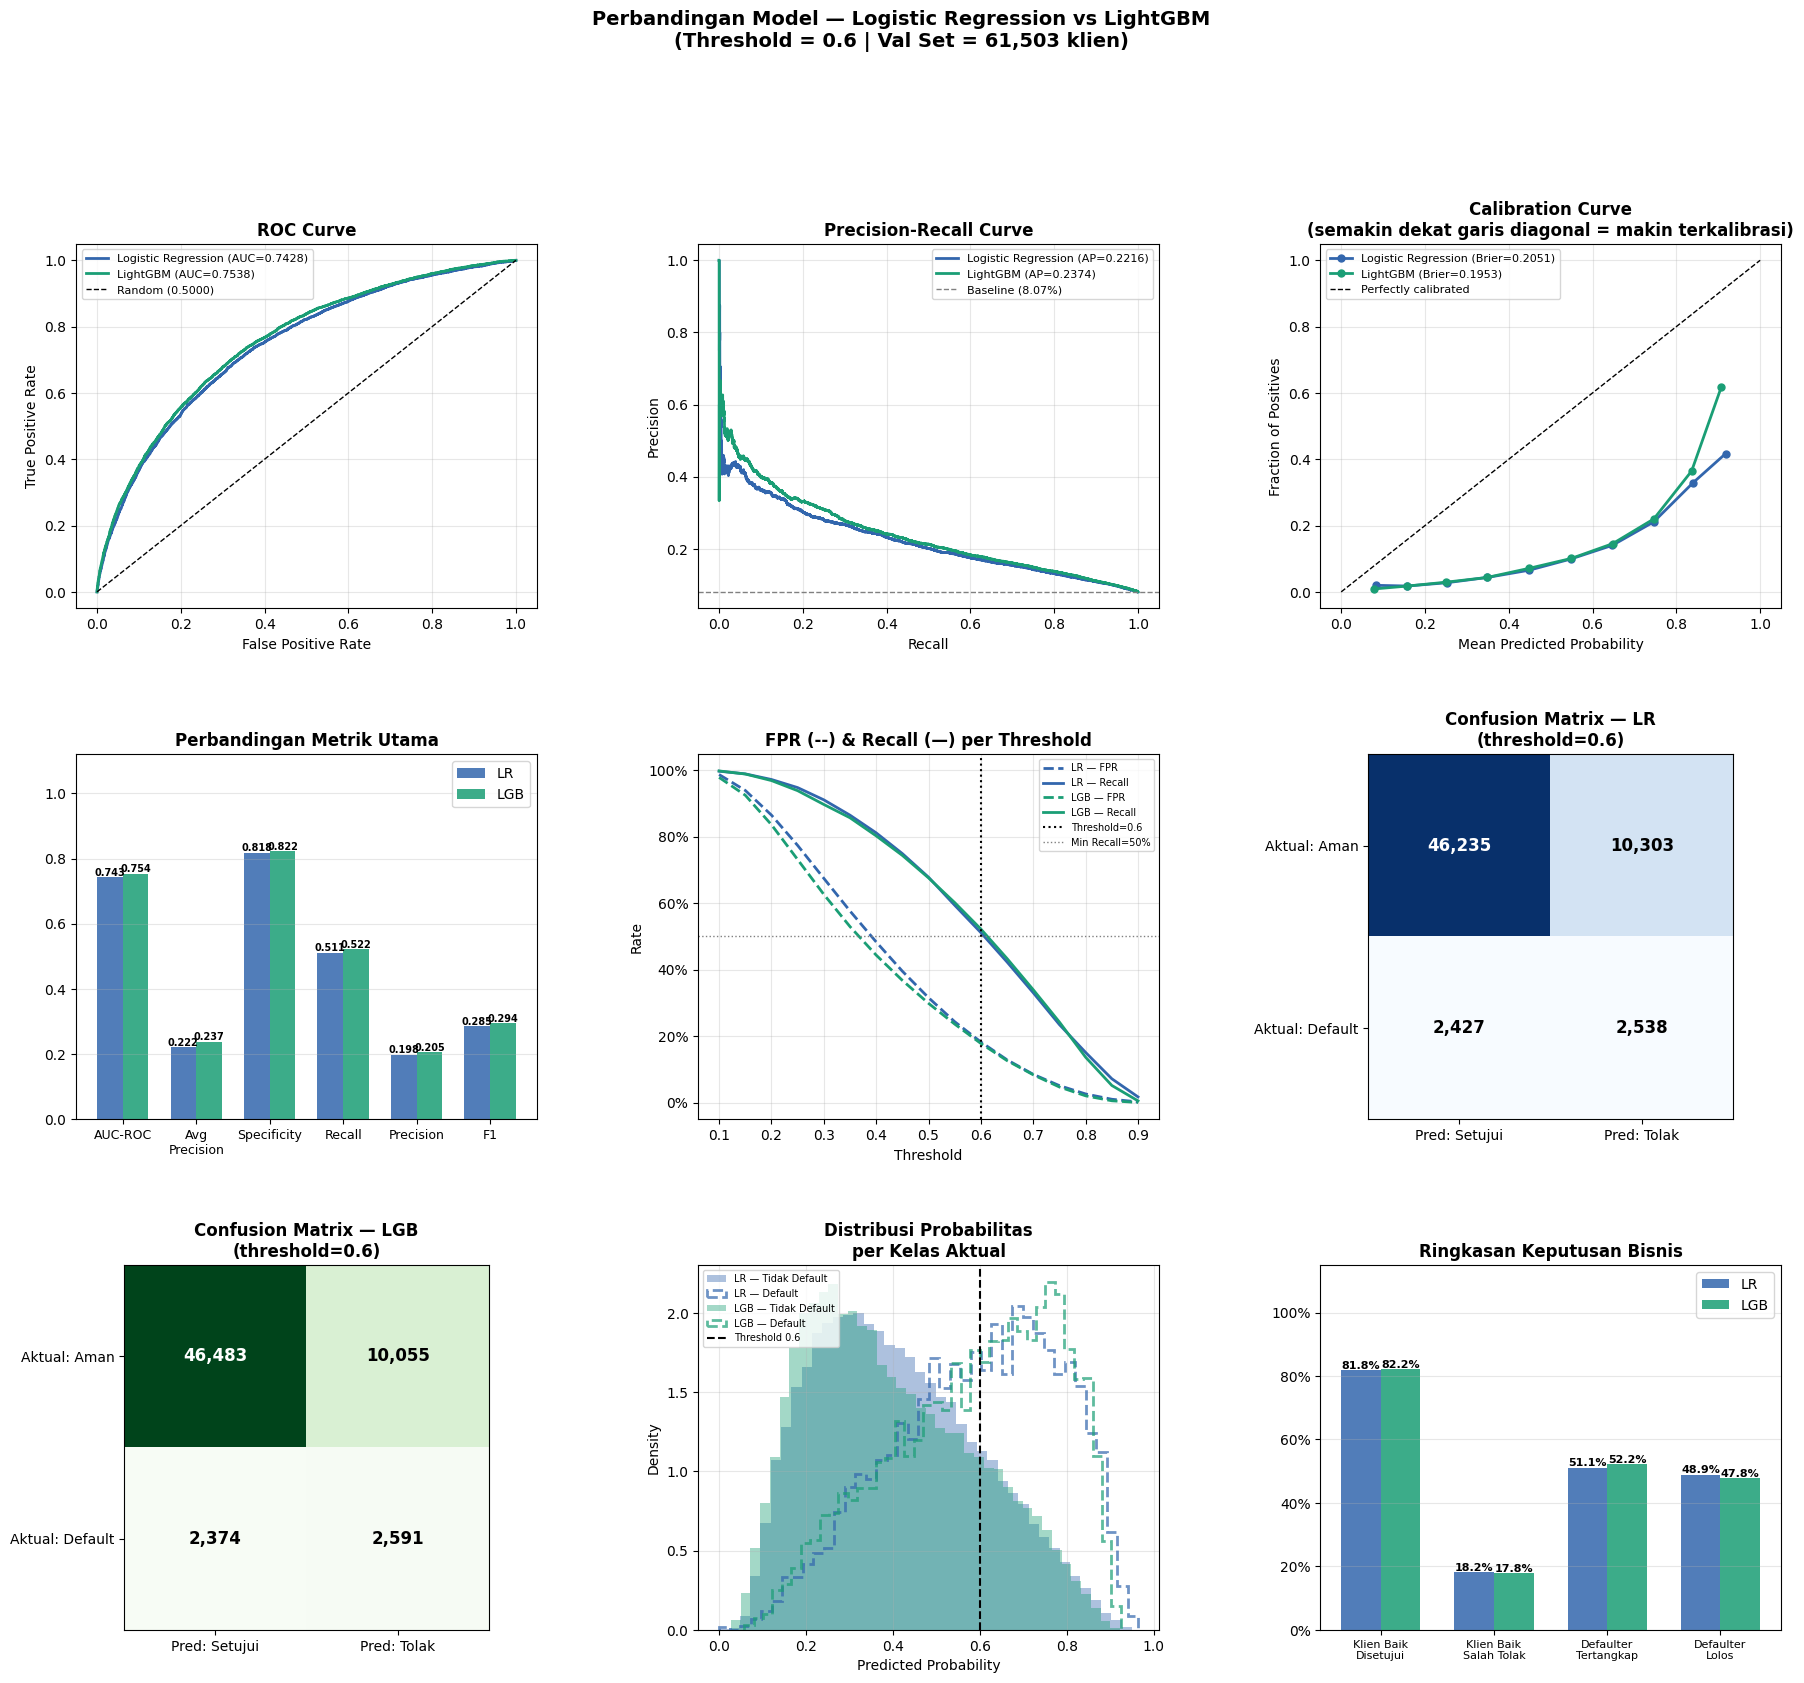


REKOMENDASI AKHIR
LightGBM unggul di 9/9 metrik

  AUC-ROC       : LGB 0.7538 vs LR 0.7428  (+0.0110)
  Specificity   : LGB 0.8222 vs LR 0.8178  (+0.0044)
  FPR           : LGB 0.1778 vs LR 0.1822  (-0.0044)
  Recall        : LGB 0.5219 vs LR 0.5112  (+0.0107)

→ Model terpilih : LightGBM
→ File submission: submission_lgb.csv


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from sklearn.metrics import (
    roc_auc_score, confusion_matrix, roc_curve,
    precision_recall_curve, brier_score_loss,
    precision_score, recall_score, f1_score,
    accuracy_score, average_precision_score
)
from sklearn.calibration import calibration_curve
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# PERSIAPAN — pastikan variabel ini sudah ada dari cell sebelumnya
# ============================================================
# lr_prob_val    → probabilitas prediksi LR di val set
# lgb_prob_val   → probabilitas prediksi LightGBM di val set
# y_val          → label aktual val set
# BEST_THRESH    → 0.6 (threshold optimal kedua model)
# ============================================================

THRESH       = 0.6
MIN_RECALL   = 0.50
y_true       = y_val.values
total_good   = (y_true == 0).sum()
total_bad    = (y_true == 1).sum()
overall_rate = y_true.mean()

# ============================================================
# STEP 1 — HITUNG SEMUA METRIK
# ============================================================
def compute_metrics(y_true, y_prob, threshold, model_name):
    y_pred = (y_prob >= threshold).astype(int)
    cm     = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm[0,0], cm[0,1], cm[1,0], cm[1,1]

    total_good = (y_true == 0).sum()
    total_bad  = (y_true == 1).sum()

    return {
        'model'          : model_name,
        'threshold'      : threshold,
        # Metrik ranking (threshold-independent)
        'auc_roc'        : roc_auc_score(y_true, y_prob),
        'avg_precision'  : average_precision_score(y_true, y_prob),
        'brier_score'    : brier_score_loss(y_true, y_prob),
        # Metrik bisnis utama
        'specificity'    : tn / (tn + fp),
        'fpr'            : fp / (tn + fp),
        'recall'         : tp / (tp + fn),
        'precision'      : tp / (tp + fp) if (tp + fp) > 0 else 0,
        'f1'             : f1_score(y_true, y_pred, zero_division=0),
        'accuracy'       : accuracy_score(y_true, y_pred),
        # Confusion matrix absolut
        'tn'  : tn, 'fp'  : fp,
        'fn'  : fn, 'tp'  : tp,
        # Persentase bisnis
        'good_approved_pct' : tn / total_good,
        'good_rejected_pct' : fp / total_good,
        'bad_caught_pct'    : tp / total_bad,
        'bad_missed_pct'    : fn / total_bad,
    }

metrics_lr  = compute_metrics(y_true, lr_prob_val,  THRESH, 'Logistic Regression')
metrics_lgb = compute_metrics(y_true, lgb_prob_val, THRESH, 'LightGBM')

# ============================================================
# STEP 2 — TABEL PERBANDINGAN
# ============================================================
print('='*70)
print('PERBANDINGAN METRIK EVALUASI — LR vs LightGBM')
print(f'Threshold: {THRESH} | Val set: {len(y_true):,} klien')
print('='*70)

sections = {
    'METRIK RANKING (threshold-independent)': [
        ('AUC-ROC',          'auc_roc',       True,  '↑ lebih tinggi lebih baik'),
        ('Avg Precision',    'avg_precision', True,  '↑ lebih tinggi lebih baik'),
        ('Brier Score',      'brier_score',   False, '↓ lebih rendah lebih baik'),
    ],
    'METRIK BISNIS UTAMA (sesuai tujuan)': [
        ('Specificity',      'specificity',   True,  '↑ klien baik makin banyak disetujui'),
        ('FPR (salah tolak)','fpr',           False, '↓ makin sedikit klien baik ditolak'),
        ('Recall',           'recall',        True,  '↑ defaulter makin banyak tertangkap'),
        ('Precision',        'precision',     True,  '↑ penolakan makin tepat sasaran'),
        ('F1-Score',         'f1',            True,  '↑ keseimbangan precision & recall'),
    ],
    'METRIK TAMBAHAN': [
        ('Accuracy',         'accuracy',      True,  'ℹ️  misleading di imbalanced data'),
    ],
}

for section, metrics in sections.items():
    print(f'\n  {section}')
    print(f'  {"Metrik":<22} {"LR":>10} {"LightGBM":>12} {"Selisih":>10}  Interpretasi')
    print(f'  {"-"*80}')
    for label, key, higher_better, note in metrics:
        lr_val  = metrics_lr[key]
        lgb_val = metrics_lgb[key]
        diff    = lgb_val - lr_val
        winner  = '✅ LGB' if (diff > 0) == higher_better else '✅ LR '
        if abs(diff) < 0.0005:
            winner = '≈ Sama'
        fmt = '.4f' if key not in ['tp','tn','fp','fn'] else ',d'
        print(f'  {label:<22} {lr_val:>10.4f} {lgb_val:>12.4f} {diff:>+10.4f}  {winner}  {note}')

print(f'\n{"="*70}')
print('HASIL KEPUTUSAN BISNIS (threshold = 0.6)')
print(f'{"="*70}')
print(f'{"":30} {"LR":>15} {"LightGBM":>15}')
print(f'{"-"*62}')
print(f'{"Klien MAMPU BAYAR disetujui":30} '
      f'{metrics_lr["tn"]:>10,} ({metrics_lr["good_approved_pct"]:.2%}) '
      f'{metrics_lgb["tn"]:>10,} ({metrics_lgb["good_approved_pct"]:.2%})')
print(f'{"Klien MAMPU BAYAR salah tolak":30} '
      f'{metrics_lr["fp"]:>10,} ({metrics_lr["good_rejected_pct"]:.2%}) '
      f'{metrics_lgb["fp"]:>10,} ({metrics_lgb["good_rejected_pct"]:.2%})')
print(f'{"Defaulter BENAR ditolak":30} '
      f'{metrics_lr["tp"]:>10,} ({metrics_lr["bad_caught_pct"]:.2%}) '
      f'{metrics_lgb["tp"]:>10,} ({metrics_lgb["bad_caught_pct"]:.2%})')
print(f'{"Defaulter LOLOS disetujui":30} '
      f'{metrics_lr["fn"]:>10,} ({metrics_lr["bad_missed_pct"]:.2%}) '
      f'{metrics_lgb["fn"]:>10,} ({metrics_lgb["bad_missed_pct"]:.2%})')

# ============================================================
# STEP 3 — VISUALISASI LENGKAP
# ============================================================
fig = plt.figure(figsize=(22, 18))
gs  = gridspec.GridSpec(3, 3, figure=fig, hspace=0.4, wspace=0.35)

colors = {'LR': '#3266ad', 'LGB': '#1a9e75'}

# ── 1. ROC Curve ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
for name, probs, color in [('Logistic Regression', lr_prob_val, colors['LR']),
                             ('LightGBM',           lgb_prob_val, colors['LGB'])]:
    fpr_c, tpr_c, _ = roc_curve(y_true, probs)
    auc = roc_auc_score(y_true, probs)
    ax1.plot(fpr_c, tpr_c, color=color, linewidth=2, label=f'{name} (AUC={auc:.4f})')
ax1.plot([0,1],[0,1], 'k--', linewidth=1, label='Random (0.5000)')
ax1.set_xlabel('False Positive Rate')
ax1.set_ylabel('True Positive Rate')
ax1.set_title('ROC Curve', fontweight='bold')
ax1.legend(fontsize=8)
ax1.grid(alpha=0.3)

# ── 2. Precision-Recall Curve ────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
for name, probs, color in [('Logistic Regression', lr_prob_val, colors['LR']),
                             ('LightGBM',           lgb_prob_val, colors['LGB'])]:
    prec_c, rec_c, _ = precision_recall_curve(y_true, probs)
    ap = average_precision_score(y_true, probs)
    ax2.plot(rec_c, prec_c, color=color, linewidth=2, label=f'{name} (AP={ap:.4f})')
ax2.axhline(overall_rate, color='gray', linestyle='--',
            linewidth=1, label=f'Baseline ({overall_rate:.2%})')
ax2.set_xlabel('Recall')
ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall Curve', fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.3)

# ── 3. Calibration Curve ─────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
for name, probs, color in [('Logistic Regression', lr_prob_val, colors['LR']),
                             ('LightGBM',           lgb_prob_val, colors['LGB'])]:
    frac_pos, mean_pred = calibration_curve(y_true, probs, n_bins=10)
    bs = brier_score_loss(y_true, probs)
    ax3.plot(mean_pred, frac_pos, marker='o', color=color, linewidth=2,
             markersize=5, label=f'{name} (Brier={bs:.4f})')
ax3.plot([0,1],[0,1], 'k--', linewidth=1, label='Perfectly calibrated')
ax3.set_xlabel('Mean Predicted Probability')
ax3.set_ylabel('Fraction of Positives')
ax3.set_title('Calibration Curve\n(semakin dekat garis diagonal = makin terkalibrasi)',
              fontweight='bold')
ax3.legend(fontsize=8)
ax3.grid(alpha=0.3)

# ── 4. AUC per Metrik — Bar Chart ───────────────────────────
ax4 = fig.add_subplot(gs[1, 0])
metric_labels = ['AUC-ROC', 'Avg\nPrecision', 'Specificity', 'Recall', 'Precision', 'F1']
metric_keys   = ['auc_roc', 'avg_precision', 'specificity', 'recall', 'precision', 'f1']
lr_vals  = [metrics_lr[k]  for k in metric_keys]
lgb_vals = [metrics_lgb[k] for k in metric_keys]
x = np.arange(len(metric_labels))
w = 0.35
bars1 = ax4.bar(x - w/2, lr_vals,  w, label='LR',  color=colors['LR'],  alpha=0.85)
bars2 = ax4.bar(x + w/2, lgb_vals, w, label='LGB', color=colors['LGB'], alpha=0.85)
for bars in [bars1, bars2]:
    for bar in bars:
        ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.3f}', ha='center', fontsize=7, fontweight='bold')
ax4.set_xticks(x)
ax4.set_xticklabels(metric_labels, fontsize=9)
ax4.set_ylim(0, 1.12)
ax4.set_title('Perbandingan Metrik Utama', fontweight='bold')
ax4.legend()
ax4.grid(axis='y', alpha=0.3)

# ── 5. FPR vs Recall per Threshold ──────────────────────────
ax5 = fig.add_subplot(gs[1, 1])
thresholds = np.arange(0.10, 0.95, 0.05)

for name, probs, color, ls in [
    ('LR — FPR',  lr_prob_val,  colors['LR'],  '-'),
    ('LGB — FPR', lgb_prob_val, colors['LGB'], '-'),
]:
    fprs, recalls = [], []
    for t in thresholds:
        y_p = (probs >= t).astype(int)
        cm  = confusion_matrix(y_true, y_p)
        tn_, fp_, fn_, tp_ = cm[0,0], cm[0,1], cm[1,0], cm[1,1]
        fprs.append(fp_ / (tn_ + fp_))
        recalls.append(tp_ / (tp_ + fn_))
    ax5.plot(thresholds, fprs,    color=color, linewidth=2, linestyle='--',
             label=f'{name}')
    ax5.plot(thresholds, recalls, color=color, linewidth=2, linestyle='-',
             label=name.replace('FPR', 'Recall'))

ax5.axvline(THRESH, color='black', linestyle=':', linewidth=1.5,
            label=f'Threshold={THRESH}')
ax5.axhline(MIN_RECALL, color='gray', linestyle=':', linewidth=1,
            label=f'Min Recall={MIN_RECALL:.0%}')
ax5.set_xlabel('Threshold')
ax5.set_ylabel('Rate')
ax5.set_title('FPR (--) & Recall (—) per Threshold', fontweight='bold')
ax5.legend(fontsize=7)
ax5.grid(alpha=0.3)
ax5.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.0%}'))

# ── 6. Confusion Matrix — LR ────────────────────────────────
ax6 = fig.add_subplot(gs[1, 2])
cm_lr = np.array([[metrics_lr['tn'], metrics_lr['fp']],
                   [metrics_lr['fn'], metrics_lr['tp']]])
im = ax6.imshow(cm_lr, cmap='Blues')
for i in range(2):
    for j in range(2):
        ax6.text(j, i, f'{cm_lr[i,j]:,}', ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if cm_lr[i,j] > cm_lr.max()/2 else 'black')
ax6.set_xticks([0,1]); ax6.set_yticks([0,1])
ax6.set_xticklabels(['Pred: Setujui', 'Pred: Tolak'])
ax6.set_yticklabels(['Aktual: Aman', 'Aktual: Default'])
ax6.set_title(f'Confusion Matrix — LR\n(threshold={THRESH})', fontweight='bold')

# ── 7. Confusion Matrix — LGB ───────────────────────────────
ax7 = fig.add_subplot(gs[2, 0])
cm_lgb = np.array([[metrics_lgb['tn'], metrics_lgb['fp']],
                    [metrics_lgb['fn'], metrics_lgb['tp']]])
ax7.imshow(cm_lgb, cmap='Greens')
for i in range(2):
    for j in range(2):
        ax7.text(j, i, f'{cm_lgb[i,j]:,}', ha='center', va='center',
                 fontsize=12, fontweight='bold',
                 color='white' if cm_lgb[i,j] > cm_lgb.max()/2 else 'black')
ax7.set_xticks([0,1]); ax7.set_yticks([0,1])
ax7.set_xticklabels(['Pred: Setujui', 'Pred: Tolak'])
ax7.set_yticklabels(['Aktual: Aman', 'Aktual: Default'])
ax7.set_title(f'Confusion Matrix — LGB\n(threshold={THRESH})', fontweight='bold')

# ── 8. Distribusi Probabilitas per Kelas ────────────────────
ax8 = fig.add_subplot(gs[2, 1])
for name, probs, color in [('LR', lr_prob_val, colors['LR']),
                             ('LGB', lgb_prob_val, colors['LGB'])]:
    ax8.hist(probs[y_true==0], bins=40, alpha=0.4, density=True,
             color=color, label=f'{name} — Tidak Default')
    ax8.hist(probs[y_true==1], bins=40, alpha=0.7, density=True,
             color=color, linestyle='--', histtype='step', linewidth=2,
             label=f'{name} — Default')
ax8.axvline(THRESH, color='black', linestyle='--', linewidth=1.5,
            label=f'Threshold {THRESH}')
ax8.set_xlabel('Predicted Probability')
ax8.set_ylabel('Density')
ax8.set_title('Distribusi Probabilitas\nper Kelas Aktual', fontweight='bold')
ax8.legend(fontsize=7)
ax8.grid(alpha=0.3)

# ── 9. Ringkasan Bisnis — Grouped Bar ───────────────────────
ax9 = fig.add_subplot(gs[2, 2])
categories = ['Klien Baik\nDisetujui', 'Klien Baik\nSalah Tolak',
              'Defaulter\nTertangkap', 'Defaulter\nLolos']
lr_pcts  = [metrics_lr['good_approved_pct'],  metrics_lr['good_rejected_pct'],
            metrics_lr['bad_caught_pct'],      metrics_lr['bad_missed_pct']]
lgb_pcts = [metrics_lgb['good_approved_pct'], metrics_lgb['good_rejected_pct'],
            metrics_lgb['bad_caught_pct'],     metrics_lgb['bad_missed_pct']]

x = np.arange(len(categories))
b1 = ax9.bar(x - w/2, lr_pcts,  w, label='LR',  color=colors['LR'],  alpha=0.85)
b2 = ax9.bar(x + w/2, lgb_pcts, w, label='LGB', color=colors['LGB'], alpha=0.85)
for bars in [b1, b2]:
    for bar in bars:
        ax9.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{bar.get_height():.1%}', ha='center', fontsize=8, fontweight='bold')
ax9.set_xticks(x)
ax9.set_xticklabels(categories, fontsize=8)
ax9.set_ylim(0, 1.15)
ax9.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:.0%}'))
ax9.set_title('Ringkasan Keputusan Bisnis', fontweight='bold')
ax9.legend()
ax9.grid(axis='y', alpha=0.3)

plt.suptitle('Perbandingan Model — Logistic Regression vs LightGBM\n'
             f'(Threshold = {THRESH} | Val Set = {len(y_true):,} klien)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 4 — RINGKASAN AKHIR
# ============================================================
lgb_better = sum(1 for _, key, hb, _ in
                 [m for s in sections.values() for m in s]
                 if (metrics_lgb[key] > metrics_lr[key]) == hb
                 and abs(metrics_lgb[key] - metrics_lr[key]) > 0.0005)
total_m = sum(len(v) for v in sections.values())

print(f'\n{"="*55}')
print('REKOMENDASI AKHIR')
print(f'{"="*55}')
print(f'LightGBM unggul di {lgb_better}/{total_m} metrik')
print(f'\n  AUC-ROC       : LGB {metrics_lgb["auc_roc"]:.4f} vs LR {metrics_lr["auc_roc"]:.4f}'
      f'  (+{metrics_lgb["auc_roc"]-metrics_lr["auc_roc"]:.4f})')
print(f'  Specificity   : LGB {metrics_lgb["specificity"]:.4f} vs LR {metrics_lr["specificity"]:.4f}'
      f'  (+{metrics_lgb["specificity"]-metrics_lr["specificity"]:.4f})')
print(f'  FPR           : LGB {metrics_lgb["fpr"]:.4f} vs LR {metrics_lr["fpr"]:.4f}'
      f'  ({metrics_lgb["fpr"]-metrics_lr["fpr"]:+.4f})')
print(f'  Recall        : LGB {metrics_lgb["recall"]:.4f} vs LR {metrics_lr["recall"]:.4f}'
      f'  (+{metrics_lgb["recall"]-metrics_lr["recall"]:.4f})')
print(f'\n→ Model terpilih : LightGBM')
print(f'→ File submission: submission_lgb.csv')

Shape data test    : (48744, 121)
Kolom TARGET ada   : False
Jumlah SK_ID_CURR  : 48,744

Shape setelah drop : (48744, 26)
Shape test setelah align  : (48744, 128)
Kolom match dengan train  : True
✅ Preprocessing selesai

PREDIKSI — LOGISTIC REGRESSION
Threshold LR       : 0.6
Prob mean          : 0.4327
Prob median        : 0.4143
Prob min–max       : 0.0000 – 0.9506

Distribusi keputusan:
  Disetujui (prob < 0.6) : 38,457 (78.90%)
  Ditolak   (prob >= 0.6): 10,287 (21.10%)

PREDIKSI — LIGHTGBM
Threshold LGB      : 0.6
Prob mean          : 0.4191
Prob median        : 0.3948
Prob min–max       : 0.0329 – 0.9237

Distribusi keputusan:
  Disetujui (prob < 0.6) : 37,978 (77.91%)
  Ditolak   (prob >= 0.6): 10,766 (22.09%)


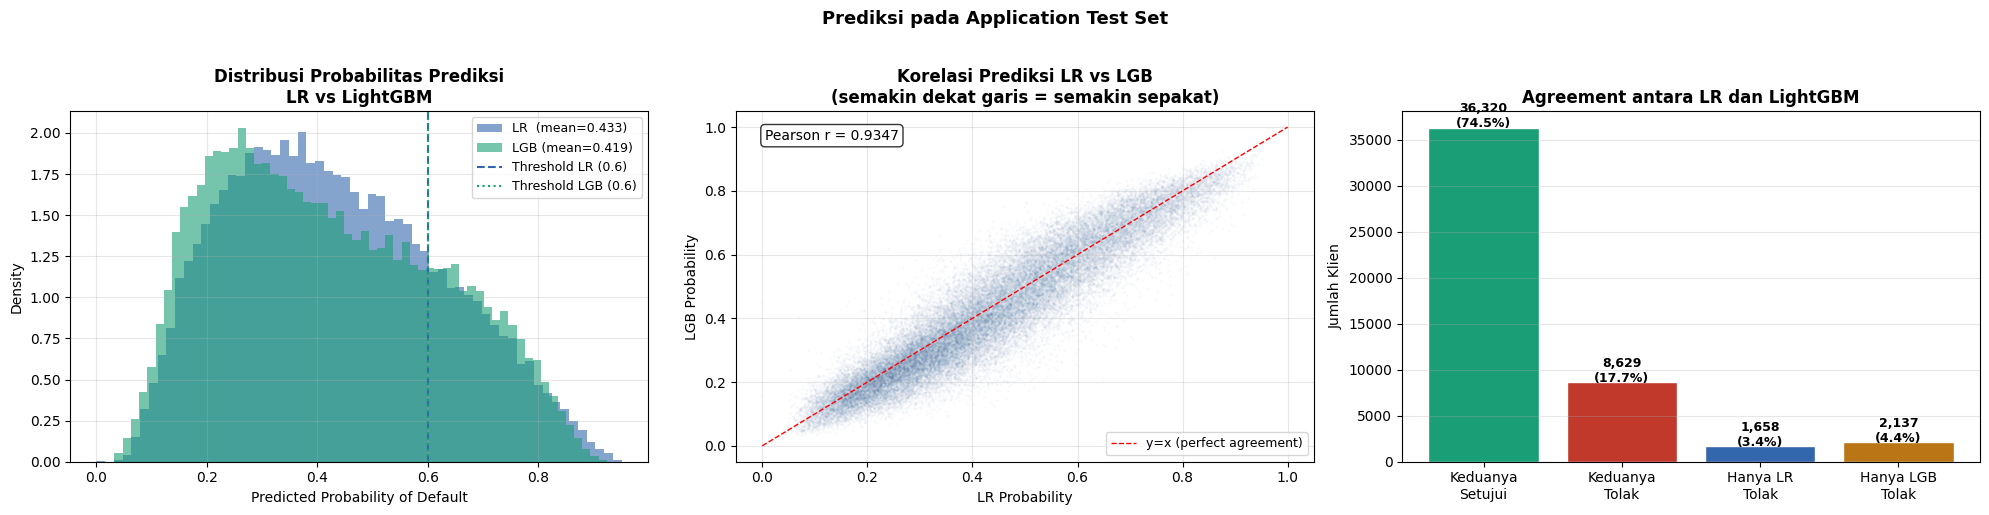


SUBMISSION TERSIMPAN
submission_lr.csv  — 48,744 baris
  Preview:
 SK_ID_CURR   TARGET
     100001 0.384262
     100005 0.739061
     100013 0.371451
     100028 0.286649
     100038 0.666375

submission_lgb.csv — 48,744 baris
  Preview:
 SK_ID_CURR   TARGET
     100001 0.343140
     100005 0.801779
     100013 0.315421
     100028 0.281317
     100038 0.599233

Catatan: Upload submission_lgb.csv terlebih dahulu
         karena LightGBM memiliki AUC lebih tinggi (0.7537 vs 0.7428)


In [ ]:
PATH = '/content/drive/MyDrive/'   # sesuaikan path kamu

# ============================================================
# STEP 1 — LOAD & CEK DATA TEST
# ============================================================
df_test = pd.read_csv(PATH + 'application_test.csv')
sk_id   = df_test['SK_ID_CURR'].copy()

print(f'Shape data test    : {df_test.shape}')
print(f'Kolom TARGET ada   : {"TARGET" in df_test.columns}')
print(f'Jumlah SK_ID_CURR  : {sk_id.nunique():,}')

# ============================================================
# STEP 2 — PREPROCESSING (identik dengan train)
# ============================================================

# ── 2A. Drop kolom ──────────────────────────────────────────
missing_pct       = df_test.isnull().mean()
drop_missing      = [c for c in missing_pct[missing_pct > 0.5].index
                     if c != 'EXT_SOURCE_1' and c in df_test.columns]
drop_redundant    = [c for c in df_test.columns
                     if '_AVG' in c or '_MODE' in c or '_MEDI' in c]
drop_flag_doc     = [c for c in df_test.columns if 'FLAG_DOCUMENT' in c]
drop_lowcorr      = ['SK_ID_CURR','FLAG_CONT_MOBILE','FLAG_MOBIL','FLAG_EMAIL',
                     'AMT_REQ_CREDIT_BUREAU_HOUR','AMT_REQ_CREDIT_BUREAU_WEEK',
                     'AMT_REQ_CREDIT_BUREAU_DAY','AMT_REQ_CREDIT_BUREAU_QRT',
                     'LIVE_REGION_NOT_WORK_REGION','REG_REGION_NOT_LIVE_REGION',
                     'REG_REGION_NOT_WORK_REGION']
drop_highcorr     = ['DAYS_EMPLOYED','OBS_60_CNT_SOCIAL_CIRCLE','AMT_CREDIT',
                     'REGION_RATING_CLIENT','CNT_FAM_MEMBERS',
                     'DEF_60_CNT_SOCIAL_CIRCLE']
drop_insignificant= ['FLAG_OWN_CAR','FLAG_OWN_REALTY','NAME_TYPE_SUITE',
                     'WEEKDAY_APPR_PROCESS_START','CNT_CHILDREN',
                     'REGION_POPULATION_RELATIVE','REG_CITY_NOT_WORK_CITY',
                     'LIVE_CITY_NOT_WORK_CITY','OBS_30_CNT_SOCIAL_CIRCLE',
                     'AMT_REQ_CREDIT_BUREAU_MON']

all_drop = set(drop_missing + drop_redundant + drop_flag_doc +
               drop_lowcorr + drop_highcorr + drop_insignificant)
df_test.drop(columns=[c for c in all_drop if c in df_test.columns],
             inplace=True)
print(f'\nShape setelah drop : {df_test.shape}')

# ── 2B. Handle Missing Values ───────────────────────────────
# Imputasi pakai median TRAIN — bukan median test!
df_test['OCCUPATION_TYPE']  = df_test['OCCUPATION_TYPE'].fillna('Unknown')
df_test['ORGANIZATION_TYPE'] = df_test['ORGANIZATION_TYPE'].replace('XNA', 'No_Organization')

# Flag SEBELUM imputasi
df_test['EXT_SOURCE_3_MISSING'] = df_test['EXT_SOURCE_3'].isnull().astype(int)
df_test['IS_NO_BUREAU_ENQUIRY'] = df_test['AMT_REQ_CREDIT_BUREAU_YEAR'].isnull().astype(int) \
    if 'AMT_REQ_CREDIT_BUREAU_YEAR' in df_test.columns else 0

# Imputasi dengan median dari train
TRAIN_MEDIANS = TRAIN_MEDIANS
for col, val in TRAIN_MEDIANS.items():
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(val)

for col in ['AMT_REQ_CREDIT_BUREAU_YEAR',
            'DEF_30_CNT_SOCIAL_CIRCLE',
            'OBS_30_CNT_SOCIAL_CIRCLE']:
    if col in df_test.columns:
        df_test[col] = df_test[col].fillna(0)

# ── 2C. Feature Engineering ─────────────────────────────────
eps = 1e-9

df_test['AGE_YEARS']          = (-df_test['DAYS_BIRTH'] / 365).round(1)
df_test['REGISTRATION_YEARS'] = (-df_test['DAYS_REGISTRATION'] / 365).round(1)
df_test['ID_PUBLISH_YEARS']   = (-df_test['DAYS_ID_PUBLISH'] / 365).round(1)
df_test['PHONE_CHANGE_YEARS'] = (-df_test['DAYS_LAST_PHONE_CHANGE'] / 365).round(1)
df_test.drop(columns=['DAYS_BIRTH','DAYS_REGISTRATION',
                       'DAYS_ID_PUBLISH','DAYS_LAST_PHONE_CHANGE'],
             inplace=True, errors='ignore')

df_test['ANNUITY_INCOME_RATIO'] = df_test['AMT_ANNUITY'] / (df_test['AMT_INCOME_TOTAL'] + eps)
df_test['GOODS_INCOME_RATIO']   = df_test['AMT_GOODS_PRICE'] / (df_test['AMT_INCOME_TOTAL'] + eps)
df_test['ANNUITY_GOODS_RATIO']  = df_test['AMT_ANNUITY'] / (df_test['AMT_GOODS_PRICE'] + eps)

df_test['EXT_SOURCE_MEAN'] = df_test[['EXT_SOURCE_2','EXT_SOURCE_3']].mean(axis=1)
df_test['EXT_SOURCE_MIN']  = df_test[['EXT_SOURCE_2','EXT_SOURCE_3']].min(axis=1)
df_test['EXT_SOURCE_PROD'] = df_test['EXT_SOURCE_2'] * df_test['EXT_SOURCE_3']

df_test['ADDRESS_MISMATCH_SCORE'] = df_test['REG_CITY_NOT_LIVE_CITY'].astype(int)
df_test['RECENTLY_CHANGED_ID']    = (df_test['ID_PUBLISH_YEARS'] < 1).astype(int) \
    if 'ID_PUBLISH_YEARS' in df_test.columns else 0
df_test['RECENTLY_CHANGED_PHONE'] = (df_test['PHONE_CHANGE_YEARS'] < 1).astype(int) \
    if 'PHONE_CHANGE_YEARS' in df_test.columns else 0

df_test['LOG_AMT_INCOME_TOTAL'] = np.log1p(df_test['AMT_INCOME_TOTAL'])
df_test['LOG_AMT_ANNUITY']      = np.log1p(df_test['AMT_ANNUITY'])
df_test['LOG_AMT_GOODS_PRICE']  = np.log1p(df_test['AMT_GOODS_PRICE'])
df_test.drop(columns=['AMT_INCOME_TOTAL','AMT_ANNUITY','AMT_GOODS_PRICE'],
             inplace=True, errors='ignore')

# Outlier capping — nilai cap dari train
cap_values = {
    'DEF_30_CNT_SOCIAL_CIRCLE'  : 4.0,
    'AMT_REQ_CREDIT_BUREAU_YEAR': 8.0,
    'ANNUITY_INCOME_RATIO'      : 0.5,
    'GOODS_INCOME_RATIO'        : 3.5,
    'ANNUITY_GOODS_RATIO'       : 0.15,
}
for col, cap_val in cap_values.items():
    if col in df_test.columns:
        df_test[col] = df_test[col].clip(upper=cap_val)

# ── 2D. Encoding ─────────────────────────────────────────────
from sklearn.preprocessing import LabelEncoder

cat_cols       = df_test.select_dtypes('object').columns.tolist()
binary_cats    = [c for c in cat_cols if df_test[c].nunique() <= 2]
nonbinary_cats = [c for c in cat_cols if df_test[c].nunique() > 2]

le = LabelEncoder()
for col in binary_cats:
    df_test[col] = le.fit_transform(df_test[col].astype(str))

df_test = pd.get_dummies(df_test, columns=nonbinary_cats, drop_first=True)

# Bersihkan nama kolom — SAMA PERSIS dengan yang dipakai di train LightGBM
df_test.columns = (df_test.columns
    .str.replace('[', '', regex=False)
    .str.replace(']', '', regex=False)
    .str.replace('<', '', regex=False)
    .str.replace('>', '', regex=False)
    .str.replace(',', '', regex=False)
    .str.replace(' ', '_', regex=False)
    .str.replace('/', '_', regex=False)
    .str.replace(':', '', regex=False)
    .str.replace('-', '', regex=False)
)
df_test = df_test.astype(float)

# ── 2E. Selaraskan kolom dengan train ────────────────────────
# feature_cols = kolom dari X_train setelah cleaning (dari cell LightGBM)

# Tambah kolom yang ada di train tapi tidak di test
for col in set(feature_cols) - set(df_test.columns):
    df_test[col] = 0

# Drop kolom yang ada di test tapi tidak di train
df_test.drop(columns=list(set(df_test.columns) - set(feature_cols)),
             inplace=True)

# Urutkan persis seperti train
df_test = df_test[feature_cols]

print(f'Shape test setelah align  : {df_test.shape}')
print(f'Kolom match dengan train  : {list(df_test.columns) == list(feature_cols)}')
assert list(df_test.columns) == list(feature_cols), \
    "❌ Kolom tidak match! Cek preprocessing."
print('✅ Preprocessing selesai')

# ============================================================
# STEP 3 — PREDIKSI DENGAN LOGISTIC REGRESSION
# ============================================================
print('\n' + '='*55)
print('PREDIKSI — LOGISTIC REGRESSION')
print('='*55)

# LR butuh data yang sudah di-scale
# Gunakan scaler yang sudah di-fit di train — JANGAN fit ulang!
X_test_scaled = pd.DataFrame(
    scaler.transform(df_test.values),
    columns=feature_cols
)

lr_test_prob = lr_final.predict_proba(X_test_scaled.values)[:, 1]
LR_THRESH    = 0.6

print(f'Threshold LR       : {LR_THRESH}')
print(f'Prob mean          : {lr_test_prob.mean():.4f}')
print(f'Prob median        : {np.median(lr_test_prob):.4f}')
print(f'Prob min–max       : {lr_test_prob.min():.4f} – {lr_test_prob.max():.4f}')
print(f'\nDistribusi keputusan:')
lr_pred = (lr_test_prob >= LR_THRESH).astype(int)
print(f'  Disetujui (prob < {LR_THRESH}) : {(lr_pred==0).sum():,} ({(lr_pred==0).mean():.2%})')
print(f'  Ditolak   (prob >= {LR_THRESH}): {(lr_pred==1).sum():,} ({(lr_pred==1).mean():.2%})')

# ============================================================
# STEP 4 — PREDIKSI DENGAN LIGHTGBM
# ============================================================
print('\n' + '='*55)
print('PREDIKSI — LIGHTGBM')
print('='*55)

# LightGBM tidak butuh scaling
lgb_test_prob = lgb_final.predict_proba(df_test.values)[:, 1]
LGB_THRESH    = 0.6

print(f'Threshold LGB      : {LGB_THRESH}')
print(f'Prob mean          : {lgb_test_prob.mean():.4f}')
print(f'Prob median        : {np.median(lgb_test_prob):.4f}')
print(f'Prob min–max       : {lgb_test_prob.min():.4f} – {lgb_test_prob.max():.4f}')
print(f'\nDistribusi keputusan:')
lgb_pred = (lgb_test_prob >= LGB_THRESH).astype(int)
print(f'  Disetujui (prob < {LGB_THRESH}) : {(lgb_pred==0).sum():,} ({(lgb_pred==0).mean():.2%})')
print(f'  Ditolak   (prob >= {LGB_THRESH}): {(lgb_pred==1).sum():,} ({(lgb_pred==1).mean():.2%})')

# ============================================================
# STEP 5 — VISUALISASI DISTRIBUSI PREDIKSI
# ============================================================
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# ── 1. Distribusi probabilitas — LR vs LGB ──────────────────
axes[0].hist(lr_test_prob,  bins=60, alpha=0.6,
             color='#3266ad', label=f'LR  (mean={lr_test_prob.mean():.3f})',
             density=True)
axes[0].hist(lgb_test_prob, bins=60, alpha=0.6,
             color='#1a9e75', label=f'LGB (mean={lgb_test_prob.mean():.3f})',
             density=True)
axes[0].axvline(LR_THRESH, color='#3266ad', linestyle='--',
                linewidth=1.5, label=f'Threshold LR ({LR_THRESH})')
axes[0].axvline(LGB_THRESH, color='#1a9e75', linestyle=':',
                linewidth=1.5, label=f'Threshold LGB ({LGB_THRESH})')
axes[0].set_title('Distribusi Probabilitas Prediksi\nLR vs LightGBM', fontweight='bold')
axes[0].set_xlabel('Predicted Probability of Default')
axes[0].set_ylabel('Density')
axes[0].legend(fontsize=9)
axes[0].grid(alpha=0.3)

# ── 2. Korelasi prediksi LR vs LGB ──────────────────────────
axes[1].scatter(lr_test_prob, lgb_test_prob,
                alpha=0.02, s=1, color='#3266ad')
axes[1].plot([0,1],[0,1], 'r--', linewidth=1, label='y=x (perfect agreement)')
axes[1].set_xlabel('LR Probability')
axes[1].set_ylabel('LGB Probability')
axes[1].set_title('Korelasi Prediksi LR vs LGB\n(semakin dekat garis = semakin sepakat)',
                  fontweight='bold')
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

corr_coef = np.corrcoef(lr_test_prob, lgb_test_prob)[0,1]
axes[1].text(0.05, 0.95, f'Pearson r = {corr_coef:.4f}',
             transform=axes[1].transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

# ── 3. Agreement antara dua model ───────────────────────────
agree_approve = ((lr_pred==0) & (lgb_pred==0)).sum()
agree_reject  = ((lr_pred==1) & (lgb_pred==1)).sum()
only_lr_rej   = ((lr_pred==1) & (lgb_pred==0)).sum()
only_lgb_rej  = ((lr_pred==0) & (lgb_pred==1)).sum()
total         = len(lr_pred)

categories = ['Keduanya\nSetujui', 'Keduanya\nTolak',
              'Hanya LR\nTolak', 'Hanya LGB\nTolak']
counts     = [agree_approve, agree_reject, only_lr_rej, only_lgb_rej]
colors_bar = ['#1a9e75', '#C0392B', '#3266ad', '#BA7517']

bars = axes[2].bar(categories, counts, color=colors_bar, edgecolor='white')
for bar, val in zip(bars, counts):
    axes[2].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 50,
                 f'{val:,}\n({val/total:.1%})',
                 ha='center', fontsize=9, fontweight='bold')
axes[2].set_title('Agreement antara LR dan LightGBM', fontweight='bold')
axes[2].set_ylabel('Jumlah Klien')
axes[2].grid(axis='y', alpha=0.3)

plt.suptitle('Prediksi pada Application Test Set',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# ============================================================
# STEP 6 — SIMPAN SUBMISSION
# ============================================================
# Format Kaggle: SK_ID_CURR + TARGET (probabilitas 0–1)

submission_lr = pd.DataFrame({
    'SK_ID_CURR': sk_id.values,
    'TARGET'    : lr_test_prob
})

submission_lgb = pd.DataFrame({
    'SK_ID_CURR': sk_id.values,
    'TARGET'    : lgb_test_prob
})

submission_lr.to_csv(PATH  + 'submission_lr.csv',  index=False)
submission_lgb.to_csv(PATH + 'submission_lgb.csv', index=False)

print('\n' + '='*55)
print('SUBMISSION TERSIMPAN')
print('='*55)
print(f'submission_lr.csv  — {len(submission_lr):,} baris')
print(f'  Preview:')
print(submission_lr.head(5).to_string(index=False))
print(f'\nsubmission_lgb.csv — {len(submission_lgb):,} baris')
print(f'  Preview:')
print(submission_lgb.head(5).to_string(index=False))

